DI725 Term Project

Research Question: Does adding textual information improve remote sensing image classification performance compared to image only inputs?

Google Drive Link:https://drive.google.com/drive/folders/1f-3Tu53bY1zJ2Xg2qfjUn6oSSuXeHmv8?usp=drive_link

The goal of this project is to investigate whether textual information improves classification performance compared to image only inputs.

Ground truth labels are derived from segmentation masks. Pixel wise class distribution is used for that purpose.

A FLAVA model is used to process both image only and image+text inputs, since FLAVA is a unified multimodal transformer that can handle image, text, and combined image text data.

**1-Importing Required Libraries and Data Loading**

In this step, images, segmentation masks, and caption data are loaded from the dataset.

*   Images: RGB remote sensing images
*   Masks: Pixel wise segmentation maps
*   Captions: Textual descriptions generated by different models

Using GitHub was not feasible due to the very large size of the datasets. Therefore, Google Drive storage was used, and the data for the model was retrieved from this storage.


In [ ]:
# Install the required Hugging Face libraries for FLAVA, model utilities, and evaluation
!pip install -q transformers datasets accelerate evaluate

import os
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt


from transformers import FlavaProcessor, FlavaModel




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Base project path
base_path = "/content/drive/MyDrive/DI725_Transformer/TermProject"

# Subfolders
images_path = os.path.join(base_path, "images")
masks_path = os.path.join(base_path, "masks")
captions_path = os.path.join(base_path, "captions.csv")

print("Images path:", images_path)
print("Masks path:", masks_path)
print("Captions file:", captions_path)

Images path: /content/drive/MyDrive/DI725_Transformer/TermProject/images
Masks path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks
Captions file: /content/drive/MyDrive/DI725_Transformer/TermProject/captions.csv


In [ ]:
# Check files in images folder
print("Sample images:", os.listdir(images_path)[:5])

# Check files in masks folder
print("Sample masks:", os.listdir(masks_path)[:5])

# Check if captions file exists
print("Captions exists:", os.path.exists(captions_path))

Sample images: ['269575.png', '269586.png', '269677.png', '269729.png', '269801.png']
Sample masks: ['73229.png', '73233.png', '7329.png', '73304.png', '73309.png']
Captions exists: True


In [ ]:
#Checking the csv files to see which columns we have
df = pd.read_csv(captions_path)

print(df.head())
print("\nColumns:\n", df.columns)

   filename  split  Tree  Shrub  Grass  Crop  Built-up  Barren  Water  \
0  0073.png  synth     0      0     92     2         0       6      0   
1  0077.png  synth     5      0     87     3         1       4      0   
2  0136.png  synth     4      0     93     0         2       1      0   
3  0172.png  synth    72      0     22     4         2       0      0   
4  0198.png  synth    32      0     14     0         0       1     53   

                                    hybrid_gemma3-4b  \
0  The image depicts a landscape dominated by ext...   
1  The image depicts a largely arid landscape dom...   
2  The image depicts a landscape dominated by ext...   
3  The image depicts a valley dominated by dense ...   
4  The image depicts a coastal area dominated by ...   

                                  hybrid_qwen3-vl-8b  \
0  The scene is dominated by grassland covering 9...   
1  The scene is dominated by grasslands (87%), in...   
2  The scene is dominated by grasslands covering ...   


The caption.csv file contains captions generated by multiple models for each image. In this project, the captions generated by "hybrid_gemma3-4b" will be used to feed the FLAVA model.

In [ ]:
sample_idx = 0
sample_row = df.iloc[sample_idx]

print("Sample filename:", sample_row["filename"])
print("\nChosen caption (hybrid_gemma3-4b):\n")
print(sample_row["hybrid_gemma3-4b"])

Sample filename: 0073.png

Chosen caption (hybrid_gemma3-4b):

The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.


In [ ]:
#Checking whether the same filename exists in both image and mask dataset
sample_filename = sample_row["filename"]

sample_image_path = os.path.join(images_path, sample_filename)
sample_mask_path = os.path.join(masks_path, sample_filename)

print("Image path exists:", os.path.exists(sample_image_path))
print("Mask path exists:", os.path.exists(sample_mask_path))

print("Image path:", sample_image_path)
print("Mask path:", sample_mask_path)

Image path exists: True
Mask path exists: True
Image path: /content/drive/MyDrive/DI725_Transformer/TermProject/images/0073.png
Mask path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks/0073.png


In [ ]:
image = Image.open(sample_image_path)
mask = Image.open(sample_mask_path)

print("Image size:", image.size, "| mode:", image.mode)
print("Mask size:", mask.size, "| mode:", mask.mode)

Image size: (256, 256) | mode: RGB
Mask size: (256, 256) | mode: RGB


To ensure the data was retrieved correctly from the storage, images and masks were displayed side by side.

"hybrid_gemma3-4b" generated caption for a spesific image is also displayed.

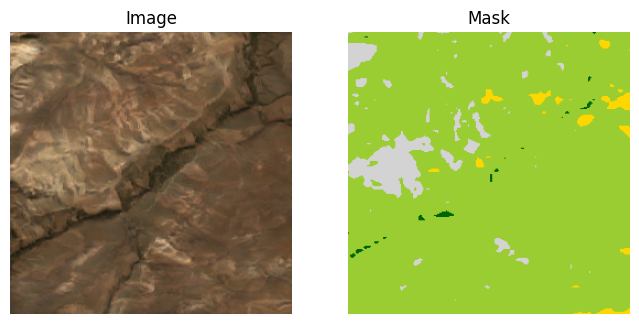

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()

In [ ]:
#The caption for the image
print("Filename:", sample_filename)
print("\nCaption:\n", sample_row["hybrid_gemma3-4b"])

Filename: 0073.png

Caption:
 The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.


**2-Class Mapping and Inspection**

In this step, the mapping between segmentation mask colors and land cover classes is defined, and the mask structure of a sample image is inspected.

The dataset provides segmentation masks in RGB format, where each pixel color corresponds to a specific land cover class. According to the project guideline, each class is associated with a predefined RGB value. Therefore,the dictionary is defined first which maps each class name to its RGB colour.

In [ ]:
# Class to RGB mapping from the project guideline
class_colors = {
    "Tree":      (0, 100, 0),
    "Shrub":     (255, 182, 193),
    "Grass":     (154, 205, 50),
    "Crop":      (255, 215, 0),
    "Built-up":  (139, 69, 19),
    "Barren":    (211, 211, 211),
    "Water":     (0, 0, 255)}

print(class_colors)

{'Tree': (0, 100, 0), 'Shrub': (255, 182, 193), 'Grass': (154, 205, 50), 'Crop': (255, 215, 0), 'Built-up': (139, 69, 19), 'Barren': (211, 211, 211), 'Water': (0, 0, 255)}


The mask image is converted into a NumPy array to enable pixel wise analysis. This allows to examine the structure of the mask and extract unique RGB values from the image.

In [ ]:
# Convert mask to numpy array
mask_np = np.array(mask)

print("Mask shape:", mask_np.shape)
print("First pixel example:", mask_np[0, 0])

Mask shape: (256, 256, 3)
First pixel example: [211 211 211]


Land cover classes from the spesific image can be determşne by identifying the unique colours in the corresponding mask. This step is essential for verifying that the mask encoding is consistent with the provided class color mapping.

In [ ]:
# Find unique RGB colors in the mask
unique_colors = np.unique(mask_np.reshape(-1, 3), axis=0)

print("Number of unique colors in this mask:", len(unique_colors))
print("Unique colors in this mask:")
print(unique_colors)

Number of unique colors in this mask: 4
Unique colors in this mask:
[[  0 100   0]
 [154 205  50]
 [211 211 211]
 [255 215   0]]


Finally,  detected RGB values mapped to its corresponding class name. This ensures that the mask can be correctly interpreted and prepares the foundation for generating ground truth labels in the next step.

In [ ]:
# Reverse mapping: RGB -> class name
color_to_class = {v: k for k, v in class_colors.items()}

# Print color-class matches found in this mask
for color in unique_colors:
    color_tuple = tuple(color)
    class_name = color_to_class.get(color_tuple, "Unknown")
    print(f"Color {color_tuple} -> {class_name}")

Color (np.uint8(0), np.uint8(100), np.uint8(0)) -> Tree
Color (np.uint8(154), np.uint8(205), np.uint8(50)) -> Grass
Color (np.uint8(211), np.uint8(211), np.uint8(211)) -> Barren
Color (np.uint8(255), np.uint8(215), np.uint8(0)) -> Crop


**3-Mask to Label**

In this step, the function which transforms a segmentation mask into a class label. The mask is represented as an RGB image, where each color corresponds to a predefined land cover class. To generate ground truth, the function first counts the number of pixels belonging to each class in the mask. Then, it computes the proportion of each class relative to the total number of pixels.

For the proof of concept, single label setting is used. In this setting the class with the highest pixel count is selected as the ground truth label. This keeps the initial pipeline simple and suitable for demonstrating feasibility. In addition to the dominant label, the function also returns class counts and ratios, which are useful for interpretation and verification.

In [ ]:
def mask_to_label(mask_image, class_colors):

    # Convert mask image to NumPy array
    mask_np = np.array(mask_image)

    # Total number of pixels in the mask
    total_pixels = mask_np.shape[0] * mask_np.shape[1]

    # Dictionaries to store counts and ratios
    counts_dict = {}
    ratios_dict = {}

    # Count pixels for each class color
    for class_name, rgb_color in class_colors.items():
        # Create a boolean mask where all RGB channels match the class color
        matches = np.all(mask_np == rgb_color, axis=-1)

        # Count matching pixels
        pixel_count = np.sum(matches)

        # Store count
        counts_dict[class_name] = int(pixel_count)

        # Store ratio
        ratios_dict[class_name] = pixel_count / total_pixels

    # Find the class with the maximum pixel count
    dominant_class = max(counts_dict, key=counts_dict.get)

    return counts_dict, ratios_dict, dominant_class

After defining the function, the sample mask is tested. This helps to verify that the function is working correctly before applying it to the full dataset. The output should show the pixel counts, class ratios, and the dominant class for the selected sample.

In [ ]:
counts_dict, ratios_dict, dominant_class = mask_to_label(mask, class_colors)

print("Pixel counts by class:")
for k, v in counts_dict.items():
    print(f"{k}: {v}")

print("\nClass ratios:")
for k, v in ratios_dict.items():
    print(f"{k}: {v:.4f}")

print("\nDominant class (ground truth label):", dominant_class)

Pixel counts by class:
Tree: 223
Shrub: 0
Grass: 60100
Crop: 1078
Built-up: 0
Barren: 4135
Water: 0

Class ratios:
Tree: 0.0034
Shrub: 0.0000
Grass: 0.9171
Crop: 0.0164
Built-up: 0.0000
Barren: 0.0631
Water: 0.0000

Dominant class (ground truth label): Grass


**4-Building Dataframe with Labels**

In this step, the new dataframe which stores the essential information for the PoC. For each sample, the code checks whether the corresponding image and mask files exist, loads the mask, generates the dominant class label using the previously defined function, and then stores the caption and label together.

This confirms that the pipeline is compatible with the model and suitable for PoC inference, with training and full evaluation to be conducted in later phases.

Since the dataset is large, a smaller subset during the PoC is used.

In [ ]:
# small subset of the CSV for proof of concept
poc_size = 200
df_poc = df.iloc[:poc_size].copy()

print("PoC subset size:", len(df_poc))
df_poc.head()

PoC subset size: 200


,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."
3,0172.png,synth,72,0,22,4,2,0,0,The image depicts a valley dominated by dense ...,The scene depicts a rural landscape dominated ...,"The scene is predominantly forested, with tree...",The image depicts a small town nestled within ...,This satellite image shows a small rural settl...
4,0198.png,synth,32,0,14,0,0,1,53,The image depicts a coastal area dominated by ...,The scene shows a coastal region dominated by ...,"The scene is predominantly water, covering 53%...",This image shows a coastal landscape with a na...,This satellite image shows a coastal peninsula...


In [ ]:
# The caption columns that is going to be used
caption_column = "hybrid_gemma3-4b"

# List to store processed dataset rows
data_rows = []

for _, row in df_poc.iterrows():
    filename = row["filename"]

    # Build full file paths
    image_path = os.path.join(images_path, filename)
    mask_path = os.path.join(masks_path, filename)

    # Skip samples if image or mask file is missing
    if not os.path.exists(image_path) or not os.path.exists(mask_path):
        continue

    # Load the mask image
    mask_image = Image.open(mask_path).convert("RGB")

    # Generate counts, ratios, and dominant label from the mask
    counts_dict, ratios_dict, dominant_class = mask_to_label(mask_image, class_colors)

    # Store sample information
    data_rows.append({
        "filename": filename,
        "image_path": image_path,
        "mask_path": mask_path,
        "caption": row[caption_column],
        "label_name": dominant_class
    })

Samples were processed and stored in a Python list. Now, this list is converted into a pandas dataframe.

In [ ]:
# convert the collected rows into a dataframe
data_df = pd.DataFrame(data_rows)

# Check how many valid samples were created
print("Number of valid samples in PoC dataframe:", len(data_df))

# Show first 5 rows
data_df.head()

Number of valid samples in PoC dataframe: 200


,filename,image_path,mask_path,caption,label_name
0,0073.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a landscape dominated by ext...,Grass
1,0077.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a largely arid landscape dom...,Grass
2,0136.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a landscape dominated by ext...,Grass
3,0172.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a valley dominated by dense ...,Tree
4,0198.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a coastal area dominated by ...,Water


The ground truth labels are currently stored as text values such as "Grass" or "Barren". However, the model requires numeric targets. Therefore, the fixed class order defined and each class name converted into a corresponding integer label.

In [ ]:
# Define the class order used in the project
class_names = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

# Create mapping dictionaries
class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_class = {idx: class_name for class_name, idx in class_to_id.items()}

# Encode label names into integers
data_df["label_id"] = data_df["label_name"].map(class_to_id)

# Inspect encoded labels
data_df[["filename", "label_name", "label_id"]].head()

,filename,label_name,label_id
0,0073.png,Grass,2
1,0077.png,Grass,2
2,0136.png,Grass,2
3,0172.png,Tree,0
4,0198.png,Water,6


In [ ]:
# Check the distribution of dominant classes
print(data_df["label_name"].value_counts())

label_name
Grass       101
Tree         66
Crop         26
Water         4
Barren        2
Built-up      1
Name: count, dtype: int64


In [ ]:
# Inspect one processed sample
sample_processed = data_df.iloc[0]

print("Filename:", sample_processed["filename"])
print("Image path:", sample_processed["image_path"])
print("Mask path:", sample_processed["mask_path"])
print("Caption:", sample_processed["caption"])
print("Label name:", sample_processed["label_name"])
print("Label id:", sample_processed["label_id"])

Filename: 0073.png
Image path: /content/drive/MyDrive/DI725_Transformer/TermProject/images/0073.png
Mask path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks/0073.png
Caption: The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.
Label name: Grass
Label id: 2


**5-Train / Validation / Test Split**

In this step, the processed PoC dataframe is divided into training, validation, and test sets.

Normally, stratified splitting should be used to preserve class distributions in the train validation and test set. But it is seen from previous outputs that there is only 1 "Built-up" image in this subset, which means it is not suitable for stratified sampling.

Since the goal of the proof of concept is to demonstrate feasibility rather than perfect class balancing, a standard random split is used at this stage.

In [ ]:
print("Processed PoC dataset size:", len(data_df))

Processed PoC dataset size: 200


In [ ]:
# Non-stratified split for PoC
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.4,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 120
Validation size: 40
Test size: 40


In [ ]:
print("Train class distribution:\n", train_df["label_name"].value_counts(), "\n")
print("Validation class distribution:\n", val_df["label_name"].value_counts(), "\n")
print("Test class distribution:\n", test_df["label_name"].value_counts())

Train class distribution:
 label_name
Grass     65
Tree      32
Crop      19
Water      3
Barren     1
Name: count, dtype: int64 

Validation class distribution:
 label_name
Tree        18
Grass       18
Crop         2
Water        1
Built-up     1
Name: count, dtype: int64 

Test class distribution:
 label_name
Grass     18
Tree      16
Crop       5
Barren     1
Name: count, dtype: int64


**6-FLAVA Inputs Preparing**

FLAVA requires inputs to be formatted in a specific way. The processor handles this preparation step. It converts raw images and text into tensors that are compatible with the FLAVA model. The same processor used for both image only and image+text settings so that the input pipeline remains consistent.

In [ ]:
from transformers import FlavaProcessor

# Load the FLAVA processor
processor = FlavaProcessor.from_pretrained("facebook/flava-full")

print("FLAVA processor loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


FLAVA processor loaded successfully.


In this step, a custom PyTorch dataset class is designed. This class reads one sample at a time from the dataframe, loads the image, takes the caption, and prepares the input using the FLAVA processor.

To keep the project aligned with design, the dataset class supports both image only mode and image + text mode.

This allows to use the same dataset structure for both experiments later.

In [ ]:
class FlavaClassificationDataset(Dataset):
    def __init__(self, dataframe, processor, use_text=True):

        self.dataframe = dataframe
        self.processor = processor
        self.use_text = use_text  #use_Text=True means image + caption mode, use_text=False means image mode

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # load image and convert to RGB to ensure consistent format
        image = Image.open(row["image_path"]).convert("RGB")

        # Get caption only if text is enabled
        text = row["caption"] if self.use_text else ""

        # Process image and text together
        encoding = self.processor(
            images=image,
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=64
        )

        # Remove the extra batch dimension added by the processor
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        # Add label
        encoding["labels"] = torch.tensor(row["label_id"], dtype=torch.long)

        return encoding

In [ ]:
# Image-only datasets
train_dataset_img = FlavaClassificationDataset(train_df, processor, use_text=False)
val_dataset_img = FlavaClassificationDataset(val_df, processor, use_text=False)
test_dataset_img = FlavaClassificationDataset(test_df, processor, use_text=False)

# image + text datasets
train_dataset_multimodal = FlavaClassificationDataset(train_df, processor, use_text=True)
val_dataset_multimodal = FlavaClassificationDataset(val_df, processor, use_text=True)
test_dataset_multimodal = FlavaClassificationDataset(test_df, processor, use_text=True)

print("Datasets created successfully.")

Datasets created successfully.


Before creating dataloaders or training the model, one processed sample is inspected. This helps to verify that the dataset is returning the expected FLAVA inputs and the correct label.

In [ ]:
# Inspect one image only sample
sample_img = train_dataset_img[0]

print("Image-only sample keys:", sample_img.keys())
for k, v in sample_img.items():
    print(k, v.shape if hasattr(v, "shape") else v)

Image-only sample keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([64])
token_type_ids torch.Size([64])
attention_mask torch.Size([64])
labels torch.Size([])


The multimodal version of the dataset checked and to confirm that both image and caption are being prepared correctly.

In [ ]:
# inspect one image + text sample
sample_multi = train_dataset_multimodal[0]

print("Image + text sample keys:", sample_multi.keys())
for k, v in sample_multi.items():
    print(k, v.shape if hasattr(v, "shape") else v)

Image + text sample keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([64])
token_type_ids torch.Size([64])
attention_mask torch.Size([64])
labels torch.Size([])


This step verifies that both image only and image+text inputs can be successfully processed using the FLAVA processor. The dataset returns correctly formatted tensors, including image features and tokenized text inputs, along with corresponding ground truth labels. This confirms that the data pipeline is compatible with the FLAVA model and suitable for subsequent training and evaluation.

The outputs for both image only and image+text samples appear structurally identical. This is expected behavior due to the design of the FLAVA model. This model is a unified multimodal transformer which processes both image and text inputs inthe same architecture. Therefore even in the image only setting, the model still needs a text related inputs like "input_ids", "attention_mask" and "token_type_ids"

In the image only case, these text inputs are typically empty or default placeholders. On the other hand,  in the image+text case, it contains meaningful tokenized captions.

**7-Dataloaders for Image Only Setting**

In this step, dataloaders are created for the image only version of the experiment.

A dataloader groups dataset samples into batches, which makes model training and evaluation more efficient.

The training dataloader uses shuffling so that samples are presented in random order during training, while validation and test dataloaders keep the original order.

In [ ]:
# batch size for PoC
batch_size = 8

# Image only dataloaders
train_loader_img = DataLoader(train_dataset_img, batch_size=batch_size, shuffle=True)
val_loader_img = DataLoader(val_dataset_img, batch_size=batch_size, shuffle=False)
test_loader_img = DataLoader(test_dataset_img, batch_size=batch_size, shuffle=False)

print("Image-only dataloaders created successfully.")

Image-only dataloaders created successfully.


**8-Dataloaders for Image+Text**

This step creates dataloaders for the multimodal version of the experiment, where both images and captions are used as input. The same batching logic is applied so that the two settings remain comparabl

In [ ]:
# Image + text dataloaders
train_loader_multi = DataLoader(train_dataset_multimodal, batch_size=batch_size, shuffle=True)
val_loader_multi = DataLoader(val_dataset_multimodal, batch_size=batch_size, shuffle=False)
test_loader_multi = DataLoader(test_dataset_multimodal, batch_size=batch_size, shuffle=False)

print("Image + text dataloaders created successfully.")

Image + text dataloaders created successfully.


In [ ]:
# Inspect one batch from image-only dataloader
batch_img = next(iter(train_loader_img))

print("Image-only batch keys:", batch_img.keys())
for k, v in batch_img.items():
    print(k, v.shape)

Image-only batch keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 64])
token_type_ids torch.Size([8, 64])
attention_mask torch.Size([8, 64])
labels torch.Size([8])


In [ ]:
# Inspect one batch from image + text dataloader
batch_multi = next(iter(train_loader_multi))

print("Image + text batch keys:", batch_multi.keys())
for k, v in batch_multi.items():
    print(k, v.shape)

Image + text batch keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 64])
token_type_ids torch.Size([8, 64])
attention_mask torch.Size([8, 64])
labels torch.Size([8])


This step verifies that both image only and image+text datasets can be successfully batched using PyTorch DataLoaders.

Like mentioned before, the image only setting uses empty text inputs. On the other hand, the image+text setting incorporates meaningful captionsç

This confirms that the data pipeline is fully compatible with the FLAVA model and ready for training.

**9-FLAVA Model**

In this step, the custom classification model built on top of FLAVA is defined.

The FLAVA backbone is used as a feature extractor, and a linear classification head is added to map the learned representation to the project’s 7 land cover classes.

The same model structure will be used for both image only and image+text. This keeps the architecture fixed and ensures that the comparison focuses on the effect of adding captions rather than changing the model design.

For the PoC, the multimodal representation is used when text is available and the image representation when text is not used.

In [ ]:
class FlavaForClassification(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Load pretrained FLAVA backbone
        self.flava = FlavaModel.from_pretrained("facebook/flava-full")

        # FLAVA hidden size is 768 for the base model
        hidden_size = self.flava.config.hidden_size

        # Simple classification head
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values, input_ids, attention_mask, token_type_ids, use_text=True):
        # Get FLAVA outputs
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        # If text is used, take multimodal pooled output
        if use_text:
            pooled_output = outputs.multimodal_output.pooler_output
        else:
            # If text is not used, take image pooled output
            pooled_output = outputs.image_output.pooler_output

        # Classification logits
        logits = self.classifier(pooled_output)

        return logits

After defining the model class, it is  instantiated and moved to the selected device. This prepares the model for forward passes and later training.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Number of project classes
num_classes = len(class_names)

# Create model
model = FlavaForClassification(num_classes=num_classes).to(device)

print("Model created successfully.")
print("Using device:", device)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_image_head.decoder.weight                                           | UNEXPECTED |  | 
mlm_head.transform.LayerNorm.bias                                       | UNEXPECTED |  | 
flava.text_model.embeddings.position_ids                                | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
mlm_head.transform.dense.weight                                         | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block

Model created successfully.
Using device: cuda


Since this is a single label classification problem in the PoC stage, the  CrossEntropyLoss is used. This is the standard loss for multiclass classification when each sample belongs to exactly one class.

The AdamW optimizer is used during training for model weight updates.

In [ ]:
# Loss function for single label classification
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("Loss and optimizer are ready.")

Loss and optimizer are ready.


Before training, the model tested with one batch from the image only dataloader. It confirms that the forward pass works correctly and that the output has the expected shape.

In [ ]:
# Get one image only batch
batch_img = next(iter(train_loader_img))
batch_img = {k: v.to(device) for k, v in batch_img.items()}

# Forward pass in image only mode
with torch.no_grad():
    logits_img = model(
        pixel_values=batch_img["pixel_values"],
        input_ids=batch_img["input_ids"],
        attention_mask=batch_img["attention_mask"],
        token_type_ids=batch_img["token_type_ids"],
        use_text=False
    )

print("Image-only logits shape:", logits_img.shape)

Image-only logits shape: torch.Size([8, 7])


The multimodal also tested with one batch from the image+text dataloader.

In [ ]:
# Get one image + text batch
batch_multi = next(iter(train_loader_multi))
batch_multi = {k: v.to(device) for k, v in batch_multi.items()}

# Forward pass in image + text mode
with torch.no_grad():
    logits_multi = model(
        pixel_values=batch_multi["pixel_values"],
        input_ids=batch_multi["input_ids"],
        attention_mask=batch_multi["attention_mask"],
        token_type_ids=batch_multi["token_type_ids"],
        use_text=True
    )

print("Image + text logits shape:", logits_multi.shape)

Image + text logits shape: torch.Size([8, 7])


In [ ]:
# Convert logits to predicted class ids
preds_img = torch.argmax(logits_img, dim=1)
preds_multi = torch.argmax(logits_multi, dim=1)

print("Image-only predicted class ids:", preds_img.cpu().numpy())
print("Image + text predicted class ids:", preds_multi.cpu().numpy())
print("True labels:", batch_img["labels"].cpu().numpy())

Image-only predicted class ids: [0 0 0 0 0 0 0 0]
Image + text predicted class ids: [0 0 0 0 0 0 0 0]
True labels: [3 2 3 2 2 3 2 2]


In this final step, the model outputs were converted into predicted class labels and compared with the corresponding ground truth labels derived from segmentation masks. The results show that both image only and image+text configurations currently produce similar predictions, which do not yet align with the true labels.

This behavior is expected at the PoC stage, as the classification head has not been trained and the model weights have not been fine tuned for the specific task. The predictions therefore reflect the initial state of the model rather than meaningful learning.

Despite this, the experiment successfully demonstrates that the complete pipeline from data loading and mask based ground truth generation to FLAVA based multimodal input processing and prediction. The model produces valid logits and class predictions that can be directly compared with ground truth labels.

It confirms the feasibility of the proposed approach. In subsequent phases, training and optimization will be applied to evaluate whether incorporating textual information improves classification performance compared to the image only setting.

**PHASE 2**

**1-Phase 2 Reproducibility, Leakage Safe Text Setup, and Benchmark Split**

Phase 1 PoC cells are kept unchanged. All Phase 2 improvements are implemented from this section onward.

In Phase 2, the goal is to obtain reliable preliminary benchmarking results for the research question.

Phase 2 uses a leakage safe text column, removes the earlier random 1000 sample subset, uses the full available dataset pool, and creates a controlled top 3 benchmark using the dominant classes which are "Grass", "Tree", and "Crop".

GitHub is used for code version control and reproducibility. W&B is configured as optional experiment tracking.

In [ ]:
!pip install -q wandb

import os
import re
import time
import copy
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import FlavaProcessor, FlavaModel

import matplotlib.pyplot as plt
import wandb

In [ ]:
# Reproducibility and device setup

GITHUB_REPO_URL = "https://github.com/aardaa-1/DI725-Term-Project"

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("GitHub repo:", GITHUB_REPO_URL)

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
GitHub repo: https://github.com/aardaa-1/DI725-Term-Project


The random seed fixed for reproducibility. The GitHub repository link is included to document code version control for the project. The dataset itself is not stored in GitHub, only the codebase and reproducibility files are versioned.

In [ ]:

# Phase 2 configuration

MODEL_NAME = "facebook/flava-full"

PHASE2_TEXT_COLUMN = "vision_qwen3-vl-8b"  # Selected column from caption.csv

# Column name that will be created for Phase 2 textual input
PHASE2_CAPTION_COL = "phase2_caption"

# Class setup
CLASS_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

CLASS_MODE = "top3"
TOP_CLASSES = ["Grass", "Tree", "Crop"]

# Split setup
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

# Training setup
NUM_EPOCHS = 5
BATCH_SIZE = 8
LEARNING_RATE_IMG = 2e-5
LEARNING_RATE_MM = 1e-5
WEIGHT_DECAY = 0.01
MAX_TEXT_LENGTH = 64

# DataLoader setup
NUM_WORKERS = 4
PIN_MEMORY = True if torch.cuda.is_available() else False
PERSISTENT_WORKERS = True if NUM_WORKERS > 0 else False

# Wandb setup
USE_WANDB = True
WANDB_PROJECT = "DI725_Term Project"
WANDB_ENTITY = "aardaatar-"

print("Phase 2 Experiment Configuration")
print("Model:", MODEL_NAME)
print("Selected Phase 2 text column:", PHASE2_TEXT_COLUMN)
print("Class mode:", CLASS_MODE)
print("Top classes:", TOP_CLASSES)
print("Epochs:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Image Only learning rate:", LEARNING_RATE_IMG)
print("Image + Text learning rate:", LEARNING_RATE_MM)
print("Num workers:", NUM_WORKERS)
print("Use W&B:", USE_WANDB)

Phase 2 Experiment Configuration
Model: facebook/flava-full
Selected Phase 2 text column: vision_qwen3-vl-8b
Class mode: top3
Top classes: ['Grass', 'Tree', 'Crop']
Epochs: 5
Batch size: 8
Image Only learning rate: 2e-05
Image + Text learning rate: 1e-05
Num workers: 4
Use W&B: True


The texts are selected from "vision_qwen3-vl-8b" column. It will be checked for leakage indicators before being used in the image+text model.

The benchmark is configured as a controlled top 3 classification task using "Grass", "Tree", and "Crop". The full 7 class setup is planned for Phase 3.

In [ ]:

# Wandb configuration

if USE_WANDB:
    if wandb.run is not None:
        wandb.finish()

    wandb.login()

    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{CLASS_MODE}_{PHASE2_TEXT_COLUMN}_phase2_lr_img_2e-5_mm_1e-5",
        config={
            "seed": SEED,
            "github_repo": GITHUB_REPO_URL,
            "model_name": MODEL_NAME,
            "phase2_text_column": PHASE2_TEXT_COLUMN,
            "class_mode": CLASS_MODE,
            "top_classes": TOP_CLASSES,
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate_image_only": LEARNING_RATE_IMG,
            "learning_rate_image_text": LEARNING_RATE_MM,
            "weight_decay": WEIGHT_DECAY,
            "max_text_length": MAX_TEXT_LENGTH,
            "train_ratio": TRAIN_RATIO,
            "val_ratio": VAL_RATIO,
            "test_ratio": TEST_RATIO,
            "num_workers": NUM_WORKERS,
            "pin_memory": PIN_MEMORY,
            "persistent_workers": PERSISTENT_WORKERS,
        }
    )

    print("W&B tracking is enabled.")
else:
    print("W&B tracking is disabled.")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: aardaatar (aardaatar-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B tracking is enabled.


Wandb Link:https://wandb.ai/aardaatar-/DI725_Term%20Project?nw=nwuseraardaatar

W&B is initialized for experiment tracking. The run stores the main Phase 2 configuration, including the selected FLAVA checkpoint, text column, class setup, training parameters, DataLoader settings, and GitHub repository link. This makes the image only and image+text experiments easier to compare.

**2-Data Leakage Check for Text Columns**

Captions which contain explicit class percentages may leak target related information into the text input. Therefore, the caption columns are checked for percentage symbols, percentage related words, class percentage patterns, and composition related terms.

In [ ]:
# Leakage check setup for caption columns

candidate_caption_columns = [
    "hybrid_gemma3-4b",
    "hybrid_qwen3-vl-8b",
    "text_qwen3-4b",
    "vision_gemma3-4b",
    "vision_qwen3-vl-8b"
]

candidate_caption_columns = [col for col in candidate_caption_columns if col in df.columns]

percentage_symbol_pattern = r"\b\d{1,3}(?:\.\d+)?\s*%"
percentage_word_pattern = r"\b\d{1,3}(?:\.\d+)?\s*(percent|percentage|per cent)\b"
class_terms_pattern = r"(?:tree|shrub|grass|crop|built[- ]?up|barren|water)"

class_percentage_pattern = (
    rf"{class_terms_pattern}.{{0,40}}\b\d{{1,3}}(?:\.\d+)?\s*%"
    rf"|"
    rf"\b\d{{1,3}}(?:\.\d+)?\s*%.{{0,40}}{class_terms_pattern}"
)

composition_words_pattern = r"\b(class composition|composition percentage|dominant class|percentage of each class)\b"

def count_pattern_matches(series, pattern):
    text_series = series.fillna("").astype(str).str.lower()
    return text_series.str.contains(pattern, regex=True, na=False).sum()

print("Candidate caption columns:")
print(candidate_caption_columns)

Candidate caption columns:
['hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']


In [ ]:
#summary
leakage_summary_rows = []

for col in candidate_caption_columns:
    col_series = df[col]

    leakage_summary_rows.append({
        "caption_column": col,
        "percentage_symbol_count": count_pattern_matches(col_series, percentage_symbol_pattern),
        "percentage_word_count": count_pattern_matches(col_series, percentage_word_pattern),
        "class_percentage_pattern_count": count_pattern_matches(col_series, class_percentage_pattern),
        "composition_words_count": count_pattern_matches(col_series, composition_words_pattern)
    })

leakage_summary_df = pd.DataFrame(leakage_summary_rows)

print("Leakage indicator summary for caption columns:")
display(leakage_summary_df)

/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_23689/1218801

Leakage indicator summary for caption columns:


/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


,caption_column,percentage_symbol_count,percentage_word_count,class_percentage_pattern_count,composition_words_count
0,hybrid_gemma3-4b,9586,0,9505,0
1,hybrid_qwen3-vl-8b,8399,0,8390,0
2,text_qwen3-4b,7276,0,7179,0
3,vision_gemma3-4b,1,0,0,0
4,vision_qwen3-vl-8b,0,0,0,0


In [ ]:
# Detailed leakage check

selected_series = df[PHASE2_TEXT_COLUMN].fillna("").astype(str)

selected_percentage_symbol_count = count_pattern_matches(selected_series, percentage_symbol_pattern)
selected_percentage_word_count = count_pattern_matches(selected_series, percentage_word_pattern)
selected_class_percentage_count = count_pattern_matches(selected_series, class_percentage_pattern)
selected_composition_words_count = count_pattern_matches(selected_series, composition_words_pattern)

print("Selected Phase 2 text column:", PHASE2_TEXT_COLUMN)
print("Percentage symbol count:", selected_percentage_symbol_count)
print("Percentage word count:", selected_percentage_word_count)
print("Class-percentage pattern count:", selected_class_percentage_count)
print("Composition-related word count:", selected_composition_words_count)

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "leakage_check/selected_percentage_symbol_count": selected_percentage_symbol_count,
        "leakage_check/selected_percentage_word_count": selected_percentage_word_count,
        "leakage_check/selected_class_percentage_pattern_count": selected_class_percentage_count,
        "leakage_check/selected_composition_words_count": selected_composition_words_count,
    })

/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


Selected Phase 2 text column: vision_qwen3-vl-8b
Percentage symbol count: 0
Percentage word count: 0
Class-percentage pattern count: 0
Composition-related word count: 0


/tmp/ipykernel_23689/1218801470.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


Previously used "hybrid_gemma3-4b" caption column contains explicit percentage indicators in most samples, which would leak target related class composition information into the text input.

In contrast, the selected Phase 2 text column, "vision_qwen3-vl-8b", contains no explicit percentage symbols, percentage words, class percentage patterns, or composition related leakage indicators. Therefore, this column is used as the textual input for the image+text FLAVA experiment.

**3-Full Dataset Preparation for Phase 2**

The random 1000 sample subset used in earlier Phase 2 trials is removed. Instead, the full available dataset is processed. Image and mask paths are created, missing files are removed, and the selected leakage safe text column is copied into a dedicated Phase 2 caption column.

In [ ]:
# Preparing the Phase 2 dataframe

data_df_2 = df.copy()

data_df_2["image_path"] = data_df_2["filename"].apply(lambda x: os.path.join(images_path, x))
data_df_2["mask_path"] = data_df_2["filename"].apply(lambda x: os.path.join(masks_path, x))

# Keeping only rows whose image and mask files exist
data_df_2 = data_df_2[
    data_df_2["image_path"].apply(os.path.exists) &
    data_df_2["mask_path"].apply(os.path.exists)
].reset_index(drop=True)

# Using the leakage safe Phase 2 text column
data_df_2[PHASE2_CAPTION_COL] = data_df_2[PHASE2_TEXT_COLUMN].fillna("").astype(str)

# Derive dominant class label from class composition columns
data_df_2["label_name"] = data_df_2[CLASS_COLS].idxmax(axis=1)
data_df_2["dominant_ratio"] = data_df_2[CLASS_COLS].max(axis=1)

print("Full available dataset size after file existence check:", len(data_df_2))

print("\nSample rows:")
display(data_df_2[["filename", PHASE2_CAPTION_COL, "label_name", "dominant_ratio"]].head())

Full available dataset size after file existence check: 10000

Sample rows:


,filename,phase2_caption,label_name,dominant_ratio
0,0073.png,"This remote sensing image shows a rugged, arid...",Grass,92
1,0077.png,"This remote sensing image depicts a rugged, ar...",Grass,87
2,0136.png,"This satellite image shows a rugged, arid moun...",Grass,93
3,0172.png,This satellite image shows a small rural settl...,Tree,72
4,0198.png,This satellite image shows a coastal peninsula...,Water,53


According to results, full dataframe for Phase 2 successfully prepared using all 10.000 available samples.

Each row now includes the image path, mask path, leakage safe Phase 2 caption, dominant class label, and dominant class ratio.

The sample rows show that the selected "vision_qwen3-vl-8b" captions describe the image content without explicit class percentage labels.

In [ ]:
# dataset class distribution

full_class_distribution = (
    data_df_2["label_name"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

print("Full dataset dominant class distribution:")
display(full_class_distribution)

print("\nFull dataset dominant ratio summary:")
display(data_df_2.groupby("label_name")["dominant_ratio"].describe())

Full dataset dominant class distribution:


,class,count
0,Grass,4703
1,Tree,3037
2,Crop,1803
3,Barren,193
4,Water,178
5,Built-up,59
6,Shrub,27



Full dataset dominant ratio summary:


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Barren,193.0,71.134715,15.591547,38.0,58.00,73.0,85.00,100.0
Built-up,59.0,56.101695,14.734074,27.0,44.00,54.0,67.00,88.0
Crop,1803.0,78.222407,17.278643,32.0,64.00,81.0,94.00,100.0
Grass,4703.0,77.672124,16.177848,32.0,64.00,81.0,92.00,100.0
Shrub,27.0,46.592593,6.829006,35.0,42.00,47.0,50.50,66.0
Tree,3037.0,77.720448,16.760300,26.0,64.00,80.0,93.00,100.0
Water,178.0,63.938202,15.957982,33.0,51.25,62.5,75.75,99.0


The dataset distribution shows a class imbalance. The dominant classes are "Grass", "Tree", and "Crop", which together cover 9.543 out of 10.000 samples.

Based on this distribution, in Phase 2 controlled top 3 benchmark is used with "Grass", "Tree", and "Crop".

In [ ]:
# top 3 benchmark filtering

if CLASS_MODE == "top3":
    selected_classes = TOP_CLASSES
elif CLASS_MODE == "all7":
    selected_classes = CLASS_COLS
else:
    raise ValueError("CLASS_MODE must be either 'top3' or 'all7'.")

phase2_df = data_df_2[data_df_2["label_name"].isin(selected_classes)].copy()
phase2_df = phase2_df.reset_index(drop=True)

print("Selected class mode:", CLASS_MODE)
print("Selected classes:", selected_classes)
print("Phase 2 benchmark dataset size:", len(phase2_df))

print("\nPhase 2 class distribution before split:")
display(phase2_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

Selected class mode: top3
Selected classes: ['Grass', 'Tree', 'Crop']
Phase 2 benchmark dataset size: 9543

Phase 2 class distribution before split:


,class,count
0,Grass,4703
1,Tree,3037
2,Crop,1803


In [ ]:
# Label mapping
label2id = {label: idx for idx, label in enumerate(selected_classes)}
id2label = {idx: label for label, idx in label2id.items()}

phase2_df["label_id"] = phase2_df["label_name"].map(label2id)

print("Label mapping:")
print(label2id)

print("\nSample rows with label IDs:")
display(phase2_df[["filename", "label_name", "label_id"]].head())

Label mapping:
{'Grass': 0, 'Tree': 1, 'Crop': 2}

Sample rows with label IDs:


,filename,label_name,label_id
0,0073.png,Grass,0
1,0077.png,Grass,0
2,0136.png,Grass,0
3,0172.png,Tree,1
4,0212.png,Crop,2


Selected classes are converted into numeric label IDs so that they can be used by the PyTorch classification model.

In [ ]:
# Stratified train / validation / test split

train_df, temp_df = train_test_split(
    phase2_df,
    test_size=(1 - TRAIN_RATIO),
    stratify=phase2_df["label_id"],
    random_state=SEED
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Split sizes:
Train: 5725
Validation: 1909
Test: 1909


Dataset is split into training, validation, and test sets using a 60/20/20 ratio.

Stratified splitting was applied so that the class distribution is preserved across all three sets.

The validation set will be used for checkpoint selection, while the test set will be used only for the final comparison between the image only and image+text models.

In [ ]:
# Class distribution after splitting

print("Train class distribution:")
display(train_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

print("\nValidation class distribution:")
display(val_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

print("\nTest class distribution:")
display(test_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "dataset/full_available_size": len(data_df_2),
        "dataset/phase2_benchmark_size": len(phase2_df),
        "dataset/train_size": len(train_df),
        "dataset/val_size": len(val_df),
        "dataset/test_size": len(test_df),
        "dataset/num_classes": len(label2id),
    })

Train class distribution:


,class,count
0,Grass,2821
1,Tree,1822
2,Crop,1082



Validation class distribution:


,class,count
0,Grass,941
1,Tree,607
2,Crop,361



Test class distribution:


,class,count
0,Grass,941
1,Tree,608
2,Crop,360


The stratified split preserves the class distribution across training, validation, and test sets.

**11-Rebuilding The Datasets and DataLoader for Phase 2**

In this step, the Phase 2 training, validation, and test splits are converted into PyTorch Dataset and DataLoader objects.

Two input settings are prepared:

1. Image Only: This is the baseline model input.
2. Image + Text: This is the multimodal model input.

Both settings use the same train, validation, and test splits. This keeps the comparison fair.

In [ ]:
# Loading FLAVA processor

phase2_processor = FlavaProcessor.from_pretrained(MODEL_NAME)

print("Phase 2 processor loaded from:", MODEL_NAME)

Phase 2 processor loaded from: facebook/flava-full


In [ ]:
# Dataset class

class Phase2RemoteSensingDataset(Dataset):
    def __init__(self, dataframe, processor, use_text=False):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor
        self.use_text = use_text

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label_id"])

        if self.use_text:
            text = str(row[PHASE2_CAPTION_COL])

            encoding = self.processor(
                images=image,
                text=text,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=MAX_TEXT_LENGTH
            )
        else:
            encoding = self.processor(
                images=image,
                return_tensors="pt"
            )

        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["labels"] = torch.tensor(label, dtype=torch.long)

        return encoding

print("Phase 2 Dataset class is ready.")

Phase 2 Dataset class is ready.


The custom Dataset class prepares each sample for FLAVA. For the "Image Only" setting, only the image is processed.

For the "Image + Text" setting, the image and caption are processed together.

The target label is taken from the numeric "label_id" column.

In [ ]:
# Creating Phase 2 Dataset objects

# Image Only Datasets
train_dataset_img = Phase2RemoteSensingDataset(train_df, phase2_processor, use_text=False)
val_dataset_img = Phase2RemoteSensingDataset(val_df, phase2_processor, use_text=False)
test_dataset_img = Phase2RemoteSensingDataset(test_df, phase2_processor, use_text=False)

# Image + Text Datasets
train_dataset_mm = Phase2RemoteSensingDataset(train_df, phase2_processor, use_text=True)
val_dataset_mm = Phase2RemoteSensingDataset(val_df, phase2_processor, use_text=True)
test_dataset_mm = Phase2RemoteSensingDataset(test_df, phase2_processor, use_text=True)

print("Image Only Dataset Sizes:")
print("Train:", len(train_dataset_img), "Validation:", len(val_dataset_img), "Test:", len(test_dataset_img))

print("\nImage + Text Dataset Sizes:")
print("Train:", len(train_dataset_mm), "Validation:", len(val_dataset_mm), "Test:", len(test_dataset_mm))

Image Only Dataset Sizes:
Train: 5725 Validation: 1909 Test: 1909

Image + Text Dataset Sizes:
Train: 5725 Validation: 1909 Test: 1909


The output confirms a fair benchmark, which shows that both model is going to used same dataset.

In [ ]:
# Dataset sanity check

sample_img = train_dataset_img[0]
sample_mm = train_dataset_mm[0]

print("Image Only sample keys:")
print(sample_img.keys())

print("\nImage + Text sample keys:")
print(sample_mm.keys())

print("\nImage Only pixel_values shape:", sample_img["pixel_values"].shape)
print("Image Only label:", sample_img["labels"])

print("\nImage + Text pixel_values shape:", sample_mm["pixel_values"].shape)
print("Image + Text input_ids shape:", sample_mm["input_ids"].shape)
print("Image + Text attention_mask shape:", sample_mm["attention_mask"].shape)
print("Image + Text label:", sample_mm["labels"])

Image Only sample keys:
dict_keys(['pixel_values', 'labels'])

Image + Text sample keys:
dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

Image Only pixel_values shape: torch.Size([3, 224, 224])
Image Only label: tensor(2)

Image + Text pixel_values shape: torch.Size([3, 224, 224])
Image + Text input_ids shape: torch.Size([64])
Image + Text attention_mask shape: torch.Size([64])
Image + Text label: tensor(2)


The sanity check confirms that the Dataset objects return the expected inputs for both settings.

*   The "Image Only" sample contains image tensors and a label
*   the "Image + Text" sample additionally contains text-related tensors such as "input_ids", "token_type_ids", and "attention_mask".

In [ ]:
# Creating DataLoaders

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "pin_memory": PIN_MEMORY,
    "num_workers": NUM_WORKERS
}

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS

train_loader_img = DataLoader(train_dataset_img, shuffle=True, **loader_kwargs)
val_loader_img = DataLoader(val_dataset_img, shuffle=False, **loader_kwargs)
test_loader_img = DataLoader(test_dataset_img, shuffle=False, **loader_kwargs)

train_loader_mm = DataLoader(train_dataset_mm, shuffle=True, **loader_kwargs)
val_loader_mm = DataLoader(val_dataset_mm, shuffle=False, **loader_kwargs)
test_loader_mm = DataLoader(test_dataset_mm, shuffle=False, **loader_kwargs)

print("Number of Image Only train batches:", len(train_loader_img))
print("Number of Image + Text train batches:", len(train_loader_mm))

print("\nDataLoader settings:")
print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)
print("Persistent workers:", PERSISTENT_WORKERS)

Number of Image Only train batches: 716
Number of Image + Text train batches: 716

DataLoader settings:
Batch size: 8
Num workers: 4
Pin memory: True
Persistent workers: True


In [ ]:
# DataLoader batch sanity check

batch_img = next(iter(train_loader_img))
batch_mm = next(iter(train_loader_mm))

print("Image Only batch keys:")
print(batch_img.keys())

print("\nImage + Text batch keys:")
print(batch_mm.keys())

print("\nImage Only batch pixel_values shape:", batch_img["pixel_values"].shape)
print("Image Only batch labels shape:", batch_img["labels"].shape)

print("\nImage + Text batch pixel_values shape:", batch_mm["pixel_values"].shape)
print("Image + Text batch input_ids shape:", batch_mm["input_ids"].shape)
print("Image + Text batch attention_mask shape:", batch_mm["attention_mask"].shape)
print("Image + Text batch labels shape:", batch_mm["labels"].shape)

Image Only batch keys:
dict_keys(['pixel_values', 'labels'])

Image + Text batch keys:
dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

Image Only batch pixel_values shape: torch.Size([8, 3, 224, 224])
Image Only batch labels shape: torch.Size([8])

Image + Text batch pixel_values shape: torch.Size([8, 3, 224, 224])
Image + Text batch input_ids shape: torch.Size([8, 64])
Image + Text batch attention_mask shape: torch.Size([8, 64])
Image + Text batch labels shape: torch.Size([8])


Images are processed as 224x224 RGB tensors and text inputs are padded or truncated to a maximum length of 64 tokens.

These DataLoaders are now ready for FLAVA model training and evaluation.

**12- Model for Training**

In this step, the trainable models for Phase 2 are defined. The goal is to compare two settings under the same classification task:

1. Image only model, which serves as the baseline.
2. Image + Text model, which serves as the multimodal version.

Both models are built on top of the same FLAVA backbone. Unlike the Phase 1 PoC, where the model was mainly used for a forward pass feasibility check, Phase 2 adds a classification head and prepares the models for supervised training on the three class benchmark dataset: "Grass", "Tree", and "Crop".

To keep the comparison fair, both models use the same FLAVA checkpoint and the same classification setup. The main difference between the two models is whether the text is included during training and evaluation.

In [ ]:
# FLAVA classifier models

import torch
import torch.nn as nn
from transformers import FlavaModel

# Number of classes after filtering
num_labels = len(label2id)
print("Number of labels:", num_labels)
print("Label mapping:", label2id)


class FlavaClassifier(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME):
        super().__init__()
        self.flava = FlavaModel.from_pretrained(model_name)
        hidden_size = self.flava.config.hidden_size           # since the hidden size needed for classification layer and the FLAVA outputs hidden representations
        self.dropout = nn.Dropout(0.1)   #  dropout is used as a regularization layer. It is going to help to reduce overfitting
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(
        self,
        pixel_values,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None
    ):
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        # Use image + text if there is an text, otherwise use only input
        if input_ids is not None and attention_mask is not None:
            pooled = outputs.multimodal_output.pooler_output
        else:
            pooled = outputs.image_output.pooler_output

        logits = self.classifier(self.dropout(pooled))

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


print("Using device:", device)

# Creating models
model_img = FlavaClassifier(num_labels=num_labels, model_name=MODEL_NAME).to(device)
model_mm = FlavaClassifier(num_labels=num_labels, model_name=MODEL_NAME).to(device)

#Check if models are ready or not
print("\nImage Only model ready.")
print("Image+Text model ready.")

Number of labels: 3
Label mapping: {'Grass': 0, 'Tree': 1, 'Crop': 2}
Using device: cuda


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_image_head.decoder.weight                                           | UNEXPECTED |  | 
mlm_head.transform.LayerNorm.bias                                       | UNEXPECTED |  | 
flava.text_model.embeddings.position_ids                                | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
mlm_head.transform.dense.weight                                         | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_image_head.decoder.weight                                           | UNEXPECTED |  | 
mlm_head.transform.LayerNorm.bias                                       | UNEXPECTED |  | 
flava.text_model.embeddings.position_ids                                | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
mlm_head.transform.dense.weight                                         | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block


Image Only model ready.
Image+Text model ready.


Before starting training, a forward pass sanity check is performed for both Phase 2 models. This step verifies that the "Image Only" and "Image + Text" models can process one mini batch successfully and produce a valid loss value and logits.

In [ ]:
# Model forward sanity check

model_img.eval()
model_mm.eval()

with torch.no_grad():
    batch_img_device = {k: v.to(device) for k, v in batch_img.items()}
    batch_mm_device = {k: v.to(device) for k, v in batch_mm.items()}

    output_img = model_img(
        pixel_values=batch_img_device["pixel_values"],
        labels=batch_img_device["labels"]
    )

    output_mm = model_mm(
        pixel_values=batch_mm_device["pixel_values"],
        input_ids=batch_mm_device["input_ids"],
        attention_mask=batch_mm_device["attention_mask"],
        token_type_ids=batch_mm_device.get("token_type_ids", None),
        labels=batch_mm_device["labels"]
    )

print("Image Only loss:", output_img["loss"].item())
print("Image Only logits shape:", output_img["logits"].shape)

print("\nImage + Text loss:", output_mm["loss"].item())
print("Image + Text logits shape:", output_mm["logits"].shape)

Image Only loss: 1.0968705415725708
Image Only logits shape: torch.Size([8, 3])

Image + Text loss: 1.0954192876815796
Image + Text logits shape: torch.Size([8, 3])


Results show that "Image Only" and "Image + Text" models produced valid loss values and logits with the expected shape "[8, 3]".

Since the models are not trained yet, the initial loss values are close to the expected random baseline for a three class classification problem. This confirms that the model architecture, batch format, and label setup are compatible before starting supervised training.

**13-Training and Validation**

In this step, each model is going to be trained for one epoch at a time.

Training loss, validation loss and validation accuracy are going to be computed.

The same loop is going to be used for both image only and image+text model.

In [ ]:
# Training helper functions

def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def move_batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}


print("Training helper functions are ready.")

Training helper functions are ready.


In [ ]:
# Single epoch training function

from tqdm import tqdm

# The function which trains the model for 1 epoch
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    sync_cuda()
    start_time = time.time()

    progress_bar = tqdm(dataloader, desc="Training", leave=False)  # "tqdm" helps to monitor training without changing model behaviour

    for batch in progress_bar:
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch.get("input_ids", None),
            attention_mask=batch.get("attention_mask", None),
            token_type_ids=batch.get("token_type_ids", None),
            labels=batch["labels"]
        )

        loss = outputs["loss"]
        logits = outputs["logits"]

        # Backward pass to compute gradients
        loss.backward()

        # optimizer.step() updates the model parameters by using gradients
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

        #compute predictions for training metrics
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(batch["labels"].detach().cpu().numpy())

    sync_cuda()
    epoch_time_sec = time.time() - start_time

    # Average training loss for the epoch
    avg_loss = total_loss / len(dataloader)

    # Training accuracy
    train_accuracy = accuracy_score(all_labels, all_preds)

    # Macro F1 calculated since the dataset is imbalanced
    train_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": train_accuracy,
        "macro_f1": train_macro_f1,
        "epoch_time_sec": epoch_time_sec
    }


print("Single epoch training function is ready.")

Single epoch training function is ready.


In [ ]:
# Evaluation function

def evaluate_model(model, dataloader, device, id2label):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    sync_cuda()
    start_time = time.time()

    with torch.no_grad():       # torch.no_grad() saves memory and speeds up evaluation
        progress_bar = tqdm(dataloader, desc="Evaluating", leave=False)

        for batch in progress_bar:
            batch = move_batch_to_device(batch, device)

            outputs = model(
                pixel_values=batch["pixel_values"],
                input_ids=batch.get("input_ids", None),
                attention_mask=batch.get("attention_mask", None),
                token_type_ids=batch.get("token_type_ids", None),
                labels=batch["labels"]
            )

            loss = outputs["loss"]
            logits = outputs["logits"]

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1) # "torch.argmax" helps to select class with highest score

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(batch["labels"].detach().cpu().numpy())

    sync_cuda()
    inference_time_sec = time.time() - start_time

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    labels_order = sorted(id2label.keys())
    target_names = [id2label[i] for i in labels_order]

    class_report = classification_report(
        all_labels,
        all_preds,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    samples_per_second = len(dataloader.dataset) / inference_time_sec
    ms_per_sample = (inference_time_sec / len(dataloader.dataset)) * 1000

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": class_report,
        "inference_time_sec": inference_time_sec,
        "samples_per_second": samples_per_second,
        "ms_per_sample": ms_per_sample,
        "labels": all_labels,
        "preds": all_preds
    }


print("Evaluation function is ready.")

Evaluation function is ready.


In [ ]:
# Full model training function

def train_model(model, train_loader, val_loader, optimizer, model_name):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "train_epoch_time_sec": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "val_weighted_f1": []
    }

    best_val_macro_f1 = -1
    best_epoch = -1
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS} - {model_name}")

        train_metrics = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device
        )

        val_metrics = evaluate_model(
            model=model,
            dataloader=val_loader,
            device=device,
            id2label=id2label
        )

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["train_epoch_time_sec"].append(train_metrics["epoch_time_sec"])

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_weighted_f1"].append(val_metrics["weighted_f1"])

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())

        print(f"Train Loss: {train_metrics['loss']:.4f}")
        print(f"Train Accuracy: {train_metrics['accuracy']:.4f}")
        print(f"Train Macro F1: {train_metrics['macro_f1']:.4f}")
        print(f"Train Epoch Time: {train_metrics['epoch_time_sec']:.2f} sec")

        print(f"Val Loss: {val_metrics['loss']:.4f}")
        print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"Val Macro F1: {val_metrics['macro_f1']:.4f}")
        print(f"Val Weighted F1: {val_metrics['weighted_f1']:.4f}")

        print("\nValidation Class-Level Metrics:")
        for class_name in [id2label[i] for i in sorted(id2label.keys())]:
            print(
                f"{class_name}: "
                f"Precision={val_metrics['classification_report'][class_name]['precision']:.4f}, "
                f"Recall={val_metrics['classification_report'][class_name]['recall']:.4f}, "
                f"F1={val_metrics['classification_report'][class_name]['f1-score']:.4f}"
            )

        if USE_WANDB and wandb.run is not None:
            wandb.log({
                f"{model_name}/epoch": epoch + 1,
                f"{model_name}/train_loss": train_metrics["loss"],
                f"{model_name}/train_accuracy": train_metrics["accuracy"],
                f"{model_name}/train_macro_f1": train_metrics["macro_f1"],
                f"{model_name}/train_epoch_time_sec": train_metrics["epoch_time_sec"],
                f"{model_name}/val_loss": val_metrics["loss"],
                f"{model_name}/val_accuracy": val_metrics["accuracy"],
                f"{model_name}/val_macro_f1": val_metrics["macro_f1"],
                f"{model_name}/val_weighted_f1": val_metrics["weighted_f1"],
            })

    history["best_epoch"] = best_epoch
    history["best_val_macro_f1"] = best_val_macro_f1
    history["best_model_state"] = best_model_state

    print(f"\nBest checkpoint for {model_name}")
    print("Best Epoch:", best_epoch)
    print("Best Validation Macro F1:", round(best_val_macro_f1, 4))

    return history


print("Full model training function is ready.")

Full model training function is ready.


In [ ]:
# Optimizers
optimizer_img = torch.optim.AdamW(
    model_img.parameters(),
    lr=LEARNING_RATE_IMG,
    weight_decay=WEIGHT_DECAY
)

optimizer_mm = torch.optim.AdamW(
    model_mm.parameters(),
    lr=LEARNING_RATE_MM,
    weight_decay=WEIGHT_DECAY
)

print("Optimizers are ready.")
print("Image Only optimizer learning rate:", LEARNING_RATE_IMG)
print("Image + Text optimizer learning rate:", LEARNING_RATE_MM)
print("Weight decay:", WEIGHT_DECAY)

Optimizers are ready.
Image Only optimizer learning rate: 2e-05
Image + Text optimizer learning rate: 1e-05
Weight decay: 0.01


The optimizers were created successfully for both Phase 2 models. Both models use the AdamW optimizer and the same weight decay value. The "Image Only" baseline uses a learning rate of 2e-5, while the "Image + Text" fusion model uses a lower learning rate of 1e-5 to make multimodal fine tuning more stable.

The comparison still uses the same data split, batch size, number of epochs, checkpoint selection criterion, and test set.

**13.1-Training and Evaluating Image Only**

In [ ]:
# Training and validating the Image Only baseline

img_history = train_model(
    model=model_img,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    optimizer=optimizer_img,
    model_name="image_only"
)

train_losses_img = img_history["train_loss"]
train_accuracies_img = img_history["train_accuracy"]
train_macro_f1s_img = img_history["train_macro_f1"]

val_losses_img = img_history["val_loss"]
val_accuracies_img = img_history["val_accuracy"]
val_macro_f1s_img = img_history["val_macro_f1"]

best_epoch_img = img_history["best_epoch"]
best_val_macro_f1_img = img_history["best_val_macro_f1"]
best_model_state_img = img_history["best_model_state"]


Epoch 1/5 - image_only


Train Loss: 0.4277
Train Accuracy: 0.8629
Train Macro F1: 0.8506
Train Epoch Time: 50.69 sec
Val Loss: 0.2294
Val Accuracy: 0.9115
Val Macro F1: 0.9060
Val Weighted F1: 0.9111

Validation Class-Level Metrics:
Grass: Precision=0.9330, Recall=0.8884, F1=0.9102
Tree: Precision=0.8983, Recall=0.9753, F1=0.9352
Crop: Precision=0.8814, Recall=0.8643, F1=0.8727

Epoch 2/5 - image_only


Train Loss: 0.2004
Train Accuracy: 0.9251
Train Macro F1: 0.9189
Train Epoch Time: 50.33 sec
Val Loss: 0.2200
Val Accuracy: 0.9167
Val Macro F1: 0.9123
Val Weighted F1: 0.9162

Validation Class-Level Metrics:
Grass: Precision=0.9407, Recall=0.8937, F1=0.9166
Tree: Precision=0.8824, Recall=0.9885, F1=0.9324
Crop: Precision=0.9224, Recall=0.8560, F1=0.8879

Epoch 3/5 - image_only


Train Loss: 0.1279
Train Accuracy: 0.9530
Train Macro F1: 0.9494
Train Epoch Time: 50.43 sec
Val Loss: 0.1957
Val Accuracy: 0.9267
Val Macro F1: 0.9194
Val Weighted F1: 0.9261

Validation Class-Level Metrics:
Grass: Precision=0.9287, Recall=0.9277, F1=0.9282
Tree: Precision=0.9292, Recall=0.9736, F1=0.9509
Crop: Precision=0.9159, Recall=0.8449, F1=0.8790

Epoch 4/5 - image_only


Train Loss: 0.0738
Train Accuracy: 0.9743
Train Macro F1: 0.9723
Train Epoch Time: 50.35 sec
Val Loss: 0.3152
Val Accuracy: 0.8942
Val Macro F1: 0.8874
Val Weighted F1: 0.8966

Validation Class-Level Metrics:
Grass: Precision=0.9689, Recall=0.8289, F1=0.8935
Tree: Precision=0.9441, Recall=0.9456, F1=0.9449
Crop: Precision=0.7117, Recall=0.9778, F1=0.8238

Epoch 5/5 - image_only


Train Loss: 0.0468
Train Accuracy: 0.9859
Train Macro F1: 0.9856
Train Epoch Time: 50.39 sec
Val Loss: 0.3601
Val Accuracy: 0.9057
Val Macro F1: 0.8933
Val Weighted F1: 0.9046

Validation Class-Level Metrics:
Grass: Precision=0.8592, Recall=0.9724, F1=0.9123
Tree: Precision=0.9819, Recall=0.8946, F1=0.9362
Crop: Precision=0.9313, Recall=0.7507, F1=0.8313

Best checkpoint for image_only
Best Epoch: 3
Best Validation Macro F1: 0.9194


The "Image Only" baseline was trained successfully for five epochs. The best validation macro F1 score was obtained at epoch 3 with a value of 0.9194. After this point, training performance continued to improve, but validation performance decreased, indicating the beginning of overfitting.

Therefore, the epoch 3 checkpoint was selected for the final test evaluation.

**13.2-Training and Evaluating Image +Text**

In [ ]:
# Training and validating the Image+Text

class FlavaFusionClassifier(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME):
        super().__init__()

        self.flava = FlavaModel.from_pretrained(model_name)
        hidden_size = self.flava.config.hidden_size

        # The fusion classifier uses image, text, and multimodal representations together.
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size * 3, num_labels)

    def forward(
        self,
        pixel_values,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None
    ):
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        image_pooled = outputs.image_output.pooler_output
        text_pooled = outputs.text_output.pooler_output
        multimodal_pooled = outputs.multimodal_output.pooler_output

        fused_features = torch.cat(
            [image_pooled, text_pooled, multimodal_pooled],
            dim=1
        )

        logits = self.classifier(self.dropout(fused_features))

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }


model_mm = FlavaFusionClassifier(num_labels=num_labels, model_name=MODEL_NAME).to(device)

optimizer_mm = torch.optim.AdamW(
    model_mm.parameters(),
    lr=LEARNING_RATE_MM,
    weight_decay=WEIGHT_DECAY
)

print("Image + Text fusion model is ready.")
print("Image + Text optimizer learning rate:", LEARNING_RATE_MM)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_image_head.decoder.weight                                           | UNEXPECTED |  | 
mlm_head.transform.LayerNorm.bias                                       | UNEXPECTED |  | 
flava.text_model.embeddings.position_ids                                | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
mlm_head.transform.dense.weight                                         | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block

Image + Text fusion model is ready.
Image + Text optimizer learning rate: 1e-05


In [ ]:
mm_history = train_model(
    model=model_mm,
    train_loader=train_loader_mm,
    val_loader=val_loader_mm,
    optimizer=optimizer_mm,
    model_name="image_text"
)

train_losses_mm = mm_history["train_loss"]
train_accuracies_mm = mm_history["train_accuracy"]
train_macro_f1s_mm = mm_history["train_macro_f1"]

val_losses_mm = mm_history["val_loss"]
val_accuracies_mm = mm_history["val_accuracy"]
val_macro_f1s_mm = mm_history["val_macro_f1"]

best_epoch_mm = mm_history["best_epoch"]
best_val_macro_f1_mm = mm_history["best_val_macro_f1"]
best_model_state_mm = mm_history["best_model_state"]


Epoch 1/5 - image_text


Train Loss: 0.4377
Train Accuracy: 0.8576
Train Macro F1: 0.8478
Train Epoch Time: 103.81 sec
Val Loss: 0.2569
Val Accuracy: 0.8989
Val Macro F1: 0.8928
Val Weighted F1: 0.9006

Validation Class-Level Metrics:
Grass: Precision=0.9288, Recall=0.8735, F1=0.9003
Tree: Precision=0.9634, Recall=0.9094, F1=0.9356
Crop: Precision=0.7583, Recall=0.9474, F1=0.8424

Epoch 2/5 - image_text


Train Loss: 0.2031
Train Accuracy: 0.9240
Train Macro F1: 0.9187
Train Epoch Time: 104.27 sec
Val Loss: 0.2112
Val Accuracy: 0.9188
Val Macro F1: 0.9129
Val Weighted F1: 0.9199

Validation Class-Level Metrics:
Grass: Precision=0.9382, Recall=0.9033, F1=0.9204
Tree: Precision=0.9724, Recall=0.9275, F1=0.9494
Crop: Precision=0.8042, Recall=0.9446, F1=0.8688

Epoch 3/5 - image_text


Train Loss: 0.1394
Train Accuracy: 0.9471
Train Macro F1: 0.9431
Train Epoch Time: 103.84 sec
Val Loss: 0.1866
Val Accuracy: 0.9293
Val Macro F1: 0.9218
Val Weighted F1: 0.9287

Validation Class-Level Metrics:
Grass: Precision=0.9108, Recall=0.9554, F1=0.9326
Tree: Precision=0.9536, Recall=0.9473, F1=0.9504
Crop: Precision=0.9404, Recall=0.8310, F1=0.8824

Epoch 4/5 - image_text


Train Loss: 0.0878
Train Accuracy: 0.9680
Train Macro F1: 0.9654
Train Epoch Time: 103.79 sec
Val Loss: 0.2492
Val Accuracy: 0.9083
Val Macro F1: 0.9021
Val Weighted F1: 0.9097

Validation Class-Level Metrics:
Grass: Precision=0.9410, Recall=0.8810, F1=0.9100
Tree: Precision=0.9590, Recall=0.9259, F1=0.9422
Crop: Precision=0.7760, Recall=0.9501, F1=0.8543

Epoch 5/5 - image_text


Train Loss: 0.0507
Train Accuracy: 0.9832
Train Macro F1: 0.9816
Train Epoch Time: 104.11 sec
Val Loss: 0.2320
Val Accuracy: 0.9288
Val Macro F1: 0.9213
Val Weighted F1: 0.9286

Validation Class-Level Metrics:
Grass: Precision=0.9126, Recall=0.9543, F1=0.9330
Tree: Precision=0.9692, Recall=0.9325, F1=0.9505
Crop: Precision=0.9062, Recall=0.8560, F1=0.8803

Best checkpoint for image_text
Best Epoch: 3
Best Validation Macro F1: 0.9218


The "Image + Text" model was trained for five epochs. This model combines image, text, and multimodal FLAVA representations before classification.

The best validation checkpoint for the fusion based "Image + Text" model was obtained at epoch 3 with a validation macro F1 score of 0.9218. This is slightly higher than the best validation macro F1 score of the "Image Only" baseline, which was 0.9194. Therefore, the final test evaluation uses the epoch 3 checkpoint for both models.

**14-Test Evaluation for Image Only and Image+Text Models**

In this step, the best saved checkpoints are reloaded for test evaluation.

In [ ]:
# Test evaluation

# loading best validation checkpoints
model_img.load_state_dict(best_model_state_img)
model_mm.load_state_dict(best_model_state_mm)

# evaluating "Image Only" model on test set
test_result_img = evaluate_model(
    model=model_img,
    dataloader=test_loader_img,
    device=device,
    id2label=id2label
)

# evaluating "Image + Text" model on test set
test_result_mm = evaluate_model(
    model=model_mm,
    dataloader=test_loader_mm,
    device=device,
    id2label=id2label
)

print("Best Image Only Test Results")
print(f"Test Loss: {test_result_img['loss']:.4f}")
print(f"Test Accuracy: {test_result_img['accuracy']:.4f}")
print(f"Test Macro Precision: {test_result_img['macro_precision']:.4f}")
print(f"Test Macro Recall: {test_result_img['macro_recall']:.4f}")
print(f"Test Macro F1: {test_result_img['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_img['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_img['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_img['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_img['ms_per_sample']:.2f}")

print("\nImage Only Class-Level Metrics:")
for class_name in [id2label[i] for i in sorted(id2label.keys())]:
    print(
        f"{class_name}: "
        f"Precision={test_result_img['classification_report'][class_name]['precision']:.4f}, "
        f"Recall={test_result_img['classification_report'][class_name]['recall']:.4f}, "
        f"F1={test_result_img['classification_report'][class_name]['f1-score']:.4f}"
    )

print("\n" + "=" * 70 + "\n")

print("Best Image + Text Test Results")
print(f"Test Loss: {test_result_mm['loss']:.4f}")
print(f"Test Accuracy: {test_result_mm['accuracy']:.4f}")
print(f"Test Macro Precision: {test_result_mm['macro_precision']:.4f}")
print(f"Test Macro Recall: {test_result_mm['macro_recall']:.4f}")
print(f"Test Macro F1: {test_result_mm['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_mm['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_mm['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_mm['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_mm['ms_per_sample']:.2f}")

print("\nImage + Text Class-Level Metrics:")
for class_name in [id2label[i] for i in sorted(id2label.keys())]:
    print(
        f"{class_name}: "
        f"Precision={test_result_mm['classification_report'][class_name]['precision']:.4f}, "
        f"Recall={test_result_mm['classification_report'][class_name]['recall']:.4f}, "
        f"F1={test_result_mm['classification_report'][class_name]['f1-score']:.4f}"
    )

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "test/image_only_accuracy": test_result_img["accuracy"],
        "test/image_only_macro_f1": test_result_img["macro_f1"],
        "test/image_only_weighted_f1": test_result_img["weighted_f1"],
        "test/image_only_inference_time_sec": test_result_img["inference_time_sec"],
        "test/image_only_samples_per_second": test_result_img["samples_per_second"],
        "test/image_only_ms_per_sample": test_result_img["ms_per_sample"],

        "test/image_text_accuracy": test_result_mm["accuracy"],
        "test/image_text_macro_f1": test_result_mm["macro_f1"],
        "test/image_text_weighted_f1": test_result_mm["weighted_f1"],
        "test/image_text_inference_time_sec": test_result_mm["inference_time_sec"],
        "test/image_text_samples_per_second": test_result_mm["samples_per_second"],
        "test/image_text_ms_per_sample": test_result_mm["ms_per_sample"],
    })

Best Image Only Test Results
Test Loss: 0.2226
Test Accuracy: 0.9125
Test Macro Precision: 0.9114
Test Macro Recall: 0.8979
Test Macro F1: 0.9038
Test Weighted F1: 0.9118
Inference Time: 389.34 sec
Samples/sec: 4.90
ms/sample: 203.95

Image Only Class-Level Metrics:
Grass: Precision=0.9086, Recall=0.9192, F1=0.9139
Tree: Precision=0.9241, Recall=0.9605, F1=0.9419
Crop: Precision=0.9015, Recall=0.8139, F1=0.8555


Best Image + Text Test Results
Test Loss: 0.2260
Test Accuracy: 0.9188
Test Macro Precision: 0.9268
Test Macro Recall: 0.8971
Test Macro F1: 0.9101
Test Weighted F1: 0.9182
Inference Time: 11.65 sec
Samples/sec: 163.89
ms/sample: 6.10

Image + Text Class-Level Metrics:
Grass: Precision=0.8912, Recall=0.9575, F1=0.9232
Tree: Precision=0.9623, Recall=0.9227, F1=0.9421
Crop: Precision=0.9270, Recall=0.8111, F1=0.8652


The first evaluation pass may include DataLoader worker initialization, disk/cache warm up, or CUDA warm up overhead.

Therefore, inference speed is measured again after one warm-up pass.

In [ ]:
print("Running warm-up evaluation...")

_ = evaluate_model(
    model=model_img,
    dataloader=test_loader_img,
    device=device,
    id2label=id2label
)

_ = evaluate_model(
    model=model_mm,
    dataloader=test_loader_mm,
    device=device,
    id2label=id2label
)

print("Warm-up completed.\n")


print("Re-running Image Only test evaluation...")
test_result_img_final = evaluate_model(
    model=model_img,
    dataloader=test_loader_img,
    device=device,
    id2label=id2label
)

print("Re-running Image + Text test evaluation...")
test_result_mm_final = evaluate_model(
    model=model_mm,
    dataloader=test_loader_mm,
    device=device,
    id2label=id2label
)


print("Final Speed-Checked Image Only Test Results")
print(f"Test Accuracy: {test_result_img_final['accuracy']:.4f}")
print(f"Test Macro F1: {test_result_img_final['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_img_final['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_img_final['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_img_final['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_img_final['ms_per_sample']:.2f}")

print("\n" + "=" * 70 + "\n")

print("Final Speed-Checked Image + Text Test Results")
print(f"Test Accuracy: {test_result_mm_final['accuracy']:.4f}")
print(f"Test Macro F1: {test_result_mm_final['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_mm_final['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_mm_final['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_mm_final['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_mm_final['ms_per_sample']:.2f}")

Running warm-up evaluation...


Warm-up completed.

Re-running Image Only test evaluation...


Re-running Image + Text test evaluation...


Final Speed-Checked Image Only Test Results
Test Accuracy: 0.9125
Test Macro F1: 0.9038
Test Weighted F1: 0.9118
Inference Time: 7.54 sec
Samples/sec: 253.22
ms/sample: 3.95


Final Speed-Checked Image + Text Test Results
Test Accuracy: 0.9188
Test Macro F1: 0.9101
Test Weighted F1: 0.9182
Inference Time: 11.64 sec
Samples/sec: 164.03
ms/sample: 6.10


In [ ]:
# Comparison table

comparison_df = pd.DataFrame({
    "Model": ["Image Only", "Image + Text"],
    "Best Epoch": [best_epoch_img, best_epoch_mm],
    "Test Accuracy": [
        test_result_img_final["accuracy"],
        test_result_mm_final["accuracy"]
    ],
    "Test Macro F1": [
        test_result_img_final["macro_f1"],
        test_result_mm_final["macro_f1"]
    ],
    "Test Weighted F1": [
        test_result_img_final["weighted_f1"],
        test_result_mm_final["weighted_f1"]
    ],
    "Inference Time Sec": [
        test_result_img_final["inference_time_sec"],
        test_result_mm_final["inference_time_sec"]
    ],
    "Samples per Second": [
        test_result_img_final["samples_per_second"],
        test_result_mm_final["samples_per_second"]
    ],
    "Milliseconds per Sample": [
        test_result_img_final["ms_per_sample"],
        test_result_mm_final["ms_per_sample"]
    ]
})

display(comparison_df.round(4))

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "final_comparison/image_only_accuracy": test_result_img_final["accuracy"],
        "final_comparison/image_only_macro_f1": test_result_img_final["macro_f1"],
        "final_comparison/image_only_weighted_f1": test_result_img_final["weighted_f1"],
        "final_comparison/image_only_ms_per_sample": test_result_img_final["ms_per_sample"],

        "final_comparison/image_text_accuracy": test_result_mm_final["accuracy"],
        "final_comparison/image_text_macro_f1": test_result_mm_final["macro_f1"],
        "final_comparison/image_text_weighted_f1": test_result_mm_final["weighted_f1"],
        "final_comparison/image_text_ms_per_sample": test_result_mm_final["ms_per_sample"],
    })

,Model,Best Epoch,Test Accuracy,Test Macro F1,Test Weighted F1,Inference Time Sec,Samples per Second,Milliseconds per Sample
0,Image Only,3,0.9125,0.9038,0.9118,7.5390,253.2170,3.9492
1,Image + Text,3,0.9188,0.9101,0.9182,11.6384,164.0262,6.0966


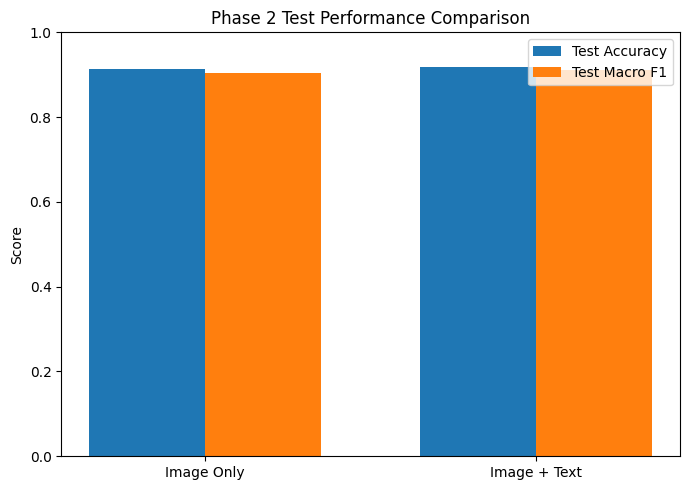

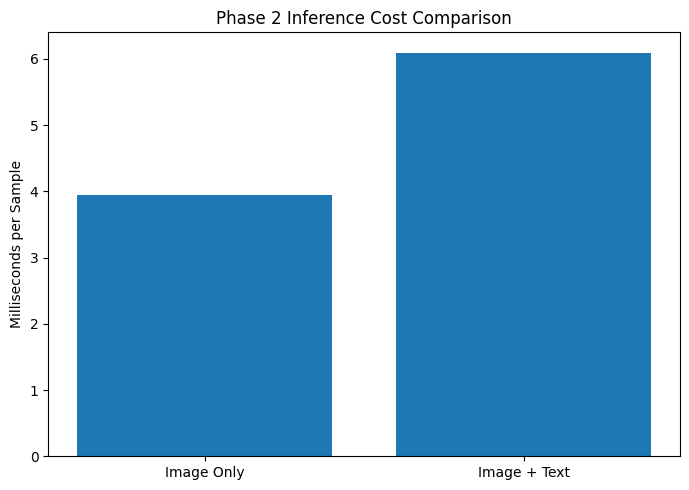

Saved figures:
phase2_test_performance_comparison.png
phase2_inference_cost_comparison.png


In [ ]:

# performance and speed visualization

# Preparing values from the final comparison table
models = comparison_df["Model"].tolist()
macro_f1_values = comparison_df["Test Macro F1"].tolist()
accuracy_values = comparison_df["Test Accuracy"].tolist()
ms_per_sample_values = comparison_df["Milliseconds per Sample"].tolist()

# Performance comparison figure
plt.figure(figsize=(7, 5))
x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, accuracy_values, width, label="Test Accuracy")
plt.bar(x + width/2, macro_f1_values, width, label="Test Macro F1")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Phase 2 Test Performance Comparison")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

plt.savefig("phase2_test_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Inference speed comparison figure
plt.figure(figsize=(7, 5))

plt.bar(models, ms_per_sample_values)

plt.ylabel("Milliseconds per Sample")
plt.title("Phase 2 Inference Cost Comparison")
plt.tight_layout()

plt.savefig("phase2_inference_cost_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("phase2_test_performance_comparison.png")
print("phase2_inference_cost_comparison.png")

According to the results, both the "Image Only" baseline and the "Image + Text" fusion model use the checkpoint from epoch 3, since this epoch produced the best validation macro F1 score for both models.

The two models achieved close classification performance on the test set, but the "Image + Text" model achieved higher test accuracy, macro F1-score, and weighted F1 score than the "Image Only" baseline. The improvement is modest, so it should be interpreted as a small preliminary gain rather than a large performance difference.

According to the speed checked inference results, the "Image Only" model achieved 3.95 ms/sample, while the "Image + Text" model required 6.10 ms/sample. This shows that textual descriptions can improve predictive performance slightly, but this gain comes with additional inference cost.

15-Confusion Matrix

In this step, confusion matrices are generated for the best image only and image+text models on the test set.

A confusion matrix shows how predicted classes are distributed against the true classes. It is going to make it easier to identify which classes are classified correctly and which classes are confused with each other.

These figures provide a more interpretable comparison between the baseline and multimodal settings and help reveal where textual information contributes to improved classification performance.

In [ ]:
labels_order_ids = sorted(id2label.keys())
labels_order_names = [id2label[i] for i in labels_order_ids]

cm_img = confusion_matrix(
    test_result_img_final["labels"],
    test_result_img_final["preds"],
    labels=labels_order_ids
)

cm_mm = confusion_matrix(
    test_result_mm_final["labels"],
    test_result_mm_final["preds"],
    labels=labels_order_ids
)

print("Image Only confusion matrix:")
print(cm_img)

print("\nImage + Text confusion matrix:")
print(cm_mm)

print("\nClass order:")
print(labels_order_names)

Image Only confusion matrix:
[[865  47  29]
 [ 21 584   3]
 [ 66   1 293]]

Image + Text confusion matrix:
[[901  20  20]
 [ 44 561   3]
 [ 66   2 292]]

Class order:
['Grass', 'Tree', 'Crop']


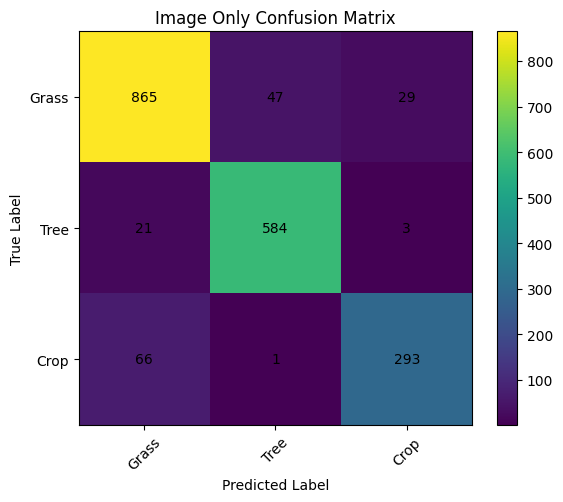

In [ ]:
# Image Only confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm_img, interpolation="nearest")
plt.title("Image Only Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_order_names))
plt.xticks(tick_marks, labels_order_names, rotation=45)
plt.yticks(tick_marks, labels_order_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_img.shape[0]):
    for j in range(cm_img.shape[1]):
        plt.text(j, i, cm_img[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("phase2_image_only_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

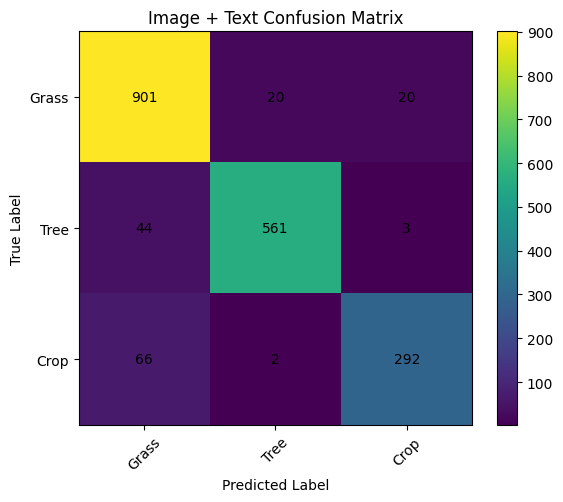

In [ ]:
# Image + Text confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm_mm, interpolation="nearest")
plt.title("Image + Text Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_order_names))
plt.xticks(tick_marks, labels_order_names, rotation=45)
plt.yticks(tick_marks, labels_order_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_mm.shape[0]):
    for j in range(cm_mm.shape[1]):
        plt.text(j, i, cm_mm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("phase2_image_text_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

The confusion matrices show that both models classify the three dominant classes with similar performance. The "Image + Text" model improves the overall balance of predictions compared with the "Image Only" baseline.

The class level F1 scores provide the clearer comparison. The "Image + Text" model achieves slightly higher F1 scores for "Grass", "Tree", and "Crop". This explains why the final test accuracy, macro F1 score, and weighted F1 score are slightly higher for the multimodal model.

In [ ]:
# Class level comparison table

class_level_rows = []

for class_name in labels_order_names:
    img_report = test_result_img_final["classification_report"][class_name]
    mm_report = test_result_mm_final["classification_report"][class_name]

    class_level_rows.append({
        "Class": class_name,
        "Image Only Precision": img_report["precision"],
        "Image Only Recall": img_report["recall"],
        "Image Only F1": img_report["f1-score"],
        "Image + Text Precision": mm_report["precision"],
        "Image + Text Recall": mm_report["recall"],
        "Image + Text F1": mm_report["f1-score"],
    })

class_level_comparison_df = pd.DataFrame(class_level_rows)

display(class_level_comparison_df.round(4))

,Class,Image Only Precision,Image Only Recall,Image Only F1,Image + Text Precision,Image + Text Recall,Image + Text F1
0,Grass,0.9086,0.9192,0.9139,0.8912,0.9575,0.9232
1,Tree,0.9241,0.9605,0.9419,0.9623,0.9227,0.9421
2,Crop,0.9015,0.8139,0.8555,0.9270,0.8111,0.8652


The class level comparison shows that the "Image + Text" model achieves slightly higher F1 scores for "Grass", "Tree", and "Crop". The largest visible improvement is observed for "Grass", while the differences for "Tree" and "Crop" remain small.

This class level behavior supports the final benchmark result. The "Image + Text" fusion model provides a modest improvement over the "Image Only" baseline, although this improvement comes with higher inference cost.

**Phase 2 Summary**

Phase 2 addressed the main feedback from Phase 1 by using a leakage safe text column, removing the earlier random subset, processing the full available dataset pool, and creating a controlled benchmark with the three dominant classes: "Grass", "Tree", and "Crop".

The experiments compared an "Image Only" FLAVA baseline with an "Image + Text" fusion model under the same train, validation, and test splits. The "Image Only" baseline used a learning rate of 2e-5, while the "Image + Text" fusion model used a lower learning rate of 1e-5 to stabilize multimodal fine tuning.

In the final test results, the "Image + Text" model achieved higher test accuracy, macro F1 score, and weighted F1 score than the "Image Only" baseline. The improvement is modest, but it shows that textual descriptions can provide additional benefit in the controlled Phase 2 benchmark.

The inference speed comparison showed that adding text increased computational cost. The "Image Only" model required 3.95 ms/sample, while the "Image + Text" model required 6.10 ms/sample. Therefore, the Phase 2 results suggest that textual information can slightly improve predictive performance, but this gain should be evaluated together with the additional inference cost.

In Phase 2, only one caption source, "vision_qwen3-vl-8b", was used for the main benchmark. In Phase 3, the study should be extended by evaluating additional caption sources, testing the full 7 class setup more systematically, applying class imbalance handling, and conducting fusion strategy ablation.

**PHASE 3**

**1-Reproducibility, Experiment Tracking, and Full Class Setup**

In Phase 3, the goal is to finalize the experiments. The task is extended from the controlled top 3 benchmark to the full 7 class remote sensing classification problem.

The Phase 3 experiments focus on three main points.  

1.   All seven land cover classes are included.
2.   The contribution of textual information is tested more carefully by using correct captions and shuffled captions.
3.   The results are analyzed at the per-class level to understand whether textual information is more helpful for rare classes.

Weights & Biases is used again in Phase 3 to track experiment configurations and results.

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Phase 3 path setup
from pathlib import Path

# Base project path used in Phase 2
BASE_PATH = Path("/content/drive/MyDrive/DI725_Transformer/TermProject")

# Dataset paths
IMAGES_PATH = BASE_PATH / "images"
MASKS_PATH = BASE_PATH / "masks"
CAPTIONS_PATH = BASE_PATH / "captions.csv"

# Phase 3 output folders
PHASE3_OUTPUT_PATH = BASE_PATH / "phase3_outputs"
PHASE3_CHECKPOINT_PATH = PHASE3_OUTPUT_PATH / "checkpoints"
PHASE3_RESULTS_PATH = PHASE3_OUTPUT_PATH / "results"
PHASE3_FIGURES_PATH = PHASE3_OUTPUT_PATH / "figures"
PHASE3_LOGS_PATH = PHASE3_OUTPUT_PATH / "logs"

# Creating Phase 3 output folders
for folder in [
    PHASE3_OUTPUT_PATH,
    PHASE3_CHECKPOINT_PATH,
    PHASE3_RESULTS_PATH,
    PHASE3_FIGURES_PATH,
    PHASE3_LOGS_PATH
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Base path:", BASE_PATH)
print("Images path exists:", IMAGES_PATH.exists())
print("Masks path exists:", MASKS_PATH.exists())
print("Captions file exists:", CAPTIONS_PATH.exists())

print("\nPhase 3 output path:", PHASE3_OUTPUT_PATH)
print("Checkpoint folder exists:", PHASE3_CHECKPOINT_PATH.exists())
print("Results folder exists:", PHASE3_RESULTS_PATH.exists())
print("Figures folder exists:", PHASE3_FIGURES_PATH.exists())
print("Logs folder exists:", PHASE3_LOGS_PATH.exists())

Base path: /content/drive/MyDrive/DI725_Transformer/TermProject
Images path exists: True
Masks path exists: True
Captions file exists: True

Phase 3 output path: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs
Checkpoint folder exists: True
Results folder exists: True
Figures folder exists: True
Logs folder exists: True


The path check confirms that the Phase 2 dataset directory is still available and that a separate Phase 3 output directory has been created successfully.

The following cells prepare the required libraries, imports, and experiment tracking setup for the final full class experiments.

In [3]:
# Installing required libraries
!pip install -q transformers accelerate evaluate wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [4]:
# Importing required libraries
import os
import random
import time
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

from transformers import FlavaProcessor, FlavaModel

import wandb

In [5]:
# Wandb configuration
WANDB_ENTITY = "aardaatar-"
WANDB_PROJECT = "DI725_Term Project"
WANDB_GROUP = "phase3-full-7class-ablation"
WANDB_MODE = "online"

# Logging into Wandb
try:
    wandb.login()
    WANDB_AVAILABLE = True
except Exception as e:
    WANDB_AVAILABLE = False
    print("Wandb login could not be completed.")
    print("Reason:", e)

print("Wandb available:", WANDB_AVAILABLE)
print("Wandb entity:", WANDB_ENTITY)
print("Wandb project:", WANDB_PROJECT)
print("Wandb group:", WANDB_GROUP)
print("Wandb mode:", WANDB_MODE)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aardaatar (aardaatar-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Wandb available: True
Wandb entity: aardaatar-
Wandb project: DI725_Term Project
Wandb group: phase3-full-7class-ablation
Wandb mode: online


**2-Configuration**

This section defines the configuration for Phase 3 experiments.

In [9]:
# Model and class configuration
MODEL_NAME = "facebook/flava-full"
PHASE_NAME = "phase3"

CLASS_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]
RARE_CLASSES = ["Shrub", "Built-up", "Barren", "Water"]

class_to_id = {class_name: idx for idx, class_name in enumerate(CLASS_COLS)}
id_to_class = {idx: class_name for class_name, idx in class_to_id.items()}

# Caption column configuration
PRIMARY_TEXT_COLUMN = "vision_qwen3-vl-8b"
ALTERNATIVE_TEXT_COLUMN = "vision_gemma3-4b"

SHUFFLED_TEXT_COLUMN = "phase3_shuffled_qwen_caption"

print("Model:", MODEL_NAME)
print("Number of classes:", len(CLASS_COLS))
print("Class mapping:", class_to_id)
print("Rare classes:", RARE_CLASSES)
print("Primary caption column:", PRIMARY_TEXT_COLUMN)
print("Alternative caption column:", ALTERNATIVE_TEXT_COLUMN)
print("Shuffled caption column:", SHUFFLED_TEXT_COLUMN)

Model: facebook/flava-full
Number of classes: 7
Class mapping: {'Tree': 0, 'Shrub': 1, 'Grass': 2, 'Crop': 3, 'Built-up': 4, 'Barren': 5, 'Water': 6}
Rare classes: ['Shrub', 'Built-up', 'Barren', 'Water']
Primary caption column: vision_qwen3-vl-8b
Alternative caption column: vision_gemma3-4b
Shuffled caption column: phase3_shuffled_qwen_caption


In [58]:
# Split and training configuration
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

NUM_EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE_IMG = 2e-5
LEARNING_RATE_MM = 1e-5
WEIGHT_DECAY = 0.01
MAX_TEXT_LENGTH = 64

USE_CLASS_WEIGHTS = True

NUM_WORKERS = 8
PIN_MEMORY = True if torch.cuda.is_available() else False
PERSISTENT_WORKERS = True if NUM_WORKERS > 0 else False

print("Train ratio:", TRAIN_RATIO)
print("Validation ratio:", VAL_RATIO)
print("Test ratio:", TEST_RATIO)
print("Number of epochs:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Image-only learning rate:", LEARNING_RATE_IMG)
print("Multimodal learning rate:", LEARNING_RATE_MM)
print("Use class weights:", USE_CLASS_WEIGHTS)

Train ratio: 0.6
Validation ratio: 0.2
Test ratio: 0.2
Number of epochs: 5
Batch size: 16
Image-only learning rate: 2e-05
Multimodal learning rate: 1e-05
Use class weights: True


In [59]:
# Reproducibility and device setup
SEED = 42

def set_seed(seed):
    # Setting random seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Setting CUDA backend behavior
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [60]:
# Phase 3 setup sanity check

# Checking core paths
print("BASE_PATH:", BASE_PATH)
print("IMAGES_PATH exists:", IMAGES_PATH.exists())
print("MASKS_PATH exists:", MASKS_PATH.exists())
print("CAPTIONS_PATH exists:", CAPTIONS_PATH.exists())

# Checking Phase 3 output folders
print("\nPHASE3_OUTPUT_PATH exists:", PHASE3_OUTPUT_PATH.exists())
print("PHASE3_CHECKPOINT_PATH exists:", PHASE3_CHECKPOINT_PATH.exists())
print("PHASE3_RESULTS_PATH exists:", PHASE3_RESULTS_PATH.exists())
print("PHASE3_FIGURES_PATH exists:", PHASE3_FIGURES_PATH.exists())
print("PHASE3_LOGS_PATH exists:", PHASE3_LOGS_PATH.exists())

# Checking model and class configuration
print("\nMODEL_NAME:", MODEL_NAME)
print("Number of classes:", len(CLASS_COLS))
print("CLASS_COLS:", CLASS_COLS)
print("RARE_CLASSES:", RARE_CLASSES)

# Checking caption configuration
print("\nPRIMARY_TEXT_COLUMN:", PRIMARY_TEXT_COLUMN)
print("ALTERNATIVE_TEXT_COLUMN:", ALTERNATIVE_TEXT_COLUMN)
print("SHUFFLED_TEXT_COLUMN:", SHUFFLED_TEXT_COLUMN)

# Checking Wandb configuration
print("\nWANDB_AVAILABLE:", WANDB_AVAILABLE)
print("WANDB_ENTITY:", WANDB_ENTITY)
print("WANDB_PROJECT:", WANDB_PROJECT)
print("WANDB_GROUP:", WANDB_GROUP)
print("WANDB_MODE:", WANDB_MODE)

# Checking device
print("\nDevice:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

BASE_PATH: /content/drive/MyDrive/DI725_Transformer/TermProject
IMAGES_PATH exists: True
MASKS_PATH exists: True
CAPTIONS_PATH exists: True

PHASE3_OUTPUT_PATH exists: True
PHASE3_CHECKPOINT_PATH exists: True
PHASE3_RESULTS_PATH exists: True
PHASE3_FIGURES_PATH exists: True
PHASE3_LOGS_PATH exists: True

MODEL_NAME: facebook/flava-full
Number of classes: 7
CLASS_COLS: ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
RARE_CLASSES: ['Shrub', 'Built-up', 'Barren', 'Water']

PRIMARY_TEXT_COLUMN: vision_qwen3-vl-8b
ALTERNATIVE_TEXT_COLUMN: vision_gemma3-4b
SHUFFLED_TEXT_COLUMN: phase3_shuffled_qwen_caption

WANDB_AVAILABLE: True
WANDB_ENTITY: aardaatar-
WANDB_PROJECT: DI725_Term Project
WANDB_GROUP: phase3-full-7class-ablation
WANDB_MODE: online

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


**3-Caption Column Loading and Leakage Inspection**

The captions file is loaded and all available caption columns are checked in this step.

All five caption columns are first inspected for completeness and possible leakage indicators. This is important because text based or hybrid captions may contain explicit class composition or percentage information derived from the masks.

The leakage check is used to decide which caption sources are suitable for the main leakage safe multimodal benchmark.

In [61]:
# Loading captions.csv and checking all caption columns

captions_df = pd.read_csv(CAPTIONS_PATH)

# Caption columns available in the dataset
ALL_CAPTION_COLUMNS = [
    "hybrid_gemma3-4b",
    "hybrid_qwen3-vl-8b",
    "text_qwen3-4b",
    "vision_gemma3-4b",
    "vision_qwen3-vl-8b"
]

# Required columns for Phase 3 experiments
required_columns = ["filename"] + CLASS_COLS + ALL_CAPTION_COLUMNS

# Checking whether all required columns exist
missing_columns = [col for col in required_columns if col not in captions_df.columns]

print("Captions dataframe shape:", captions_df.shape)
print("Number of columns:", len(captions_df.columns))
print("Missing required columns:", missing_columns)

print("\nCaption columns:")
print(ALL_CAPTION_COLUMNS)

print("\nRequired columns:")
print(required_columns)

print("\nFirst 3 rows with required columns:")
display(captions_df[required_columns].head(3))

# Stopping execution if any required column is missing
if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_columns}")

Captions dataframe shape: (10000, 14)
Number of columns: 14
Missing required columns: []

Caption columns:
['hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

Required columns:
['filename', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

First 3 rows with required columns:


,filename,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."


In [62]:
# Checking caption completeness and basic caption statistics

import re

caption_summary_rows = []

for col in ALL_CAPTION_COLUMNS:
    # Preparing caption text
    texts = captions_df[col].fillna("").astype(str)

    # Calculating basic statistics
    missing_count = captions_df[col].isna().sum()
    empty_count = (texts.str.strip() == "").sum()
    avg_char_length = texts.str.len().mean()
    avg_word_length = texts.str.split().apply(len).mean()

    caption_summary_rows.append({
        "caption_column": col,
        "missing_count": missing_count,
        "empty_count": empty_count,
        "avg_char_length": round(avg_char_length, 2),
        "avg_word_count": round(avg_word_length, 2)
    })

caption_summary_df = pd.DataFrame(caption_summary_rows)

print("Caption completeness and length summary:")
display(caption_summary_df)

Caption completeness and length summary:


,caption_column,missing_count,empty_count,avg_char_length,avg_word_count
0,hybrid_gemma3-4b,0,0,274.42,42.04
1,hybrid_qwen3-vl-8b,0,0,254.23,37.68
2,text_qwen3-4b,0,0,192.19,29.58
3,vision_gemma3-4b,0,0,296.10,43.19
4,vision_qwen3-vl-8b,0,0,284.97,41.62


In [63]:
# Leakage check setup for all caption columns

percentage_symbol_pattern = r"\b\d{1,3}(?:\.\d+)?\s*%"
percentage_word_pattern = r"\b\d{1,3}(?:\.\d+)?\s*(percent|percentage|per cent)\b"
class_terms_pattern = r"(?:tree|shrub|grass|crop|built[- ]?up|barren|water)"

class_percentage_pattern = (
    rf"{class_terms_pattern}.{{0,40}}\b\d{{1,3}}(?:\.\d+)?\s*%"
    rf"|"
    rf"\b\d{{1,3}}(?:\.\d+)?\s*%.{{0,40}}{class_terms_pattern}"
)

composition_words_pattern = r"\b(class composition|composition percentage|dominant class|percentage of each class)\b"

def count_pattern_matches(series, pattern):
    # Counting regex matches in a caption column
    text_series = series.fillna("").astype(str).str.lower()
    return text_series.str.contains(pattern, regex=True, na=False).sum()

print("Candidate caption columns:")
print(ALL_CAPTION_COLUMNS)

Candidate caption columns:
['hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']


In [64]:
# Summarizing leakage indicators for all caption columns

leakage_summary_rows = []

for col in ALL_CAPTION_COLUMNS:
    col_series = captions_df[col]

    leakage_summary_rows.append({
        "caption_column": col,
        "percentage_symbol_count": count_pattern_matches(col_series, percentage_symbol_pattern),
        "percentage_word_count": count_pattern_matches(col_series, percentage_word_pattern),
        "class_percentage_pattern_count": count_pattern_matches(col_series, class_percentage_pattern),
        "composition_words_count": count_pattern_matches(col_series, composition_words_pattern)
    })

leakage_summary_df = pd.DataFrame(leakage_summary_rows)

print("Leakage indicator summary for caption columns:")
display(leakage_summary_df)

# Saving leakage summary
leakage_summary_df.to_csv(
    PHASE3_RESULTS_PATH / "phase3_caption_leakage_summary.csv",
    index=False
)

/tmp/ipykernel_3904/3567271128.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_3904/3567271128.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_3904/3567271128.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_3904/3567271128.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_3904/3567271128.p

Leakage indicator summary for caption columns:


/tmp/ipykernel_3904/3567271128.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


,caption_column,percentage_symbol_count,percentage_word_count,class_percentage_pattern_count,composition_words_count
0,hybrid_gemma3-4b,9586,0,9505,0
1,hybrid_qwen3-vl-8b,8399,0,8390,0
2,text_qwen3-4b,7276,0,7179,0
3,vision_gemma3-4b,1,0,0,0
4,vision_qwen3-vl-8b,0,0,0,0


The leakage check shows that the text and hybrid caption columns contain many explicit percentage or class composition indicators. Therefore, these caption sources are not used in the main leakage safe benchmark.

The main Phase 3 experiments use the vision based caption columns which are "vision_qwen3-vl-8b" and "vision_gemma3-4b", because they contain much fewer direct class-composition indicators. This decision keeps the multimodal comparison more consistent with the research question.

**4-Full 7 Class Dominant Label Preparation**

This section converts the segmentation based class composition percentages into a single classification label for each image.

For each sample, the class with the highest percentage among Tree, Shrub, Grass, Crop, Built-up, Barren, and Water is selected as the dominant class. This dominant class is used as the target label for the full 7 class classification task.

Only leakage safe vision caption columns are kept for the main multimodal experiments. The "vision_qwen3-vl-8b" column is used as the primary caption source, while "vision_gemma3-4b" is kept as an alternative caption source for caption source ablation.

In [65]:
# Creating dominant labels for the full 7 class setup

phase3_df = captions_df.copy()

# Selecting the class with the highest composition percentage as the target label
phase3_df["dominant_class"] = phase3_df[CLASS_COLS].idxmax(axis=1)

# Mapping dominant class names to numeric labels
phase3_df["label"] = phase3_df["dominant_class"].map(class_to_id)

# Keeping leakage safe vision caption columns for main experiments
phase3_df["qwen_caption"] = phase3_df["vision_qwen3-vl-8b"].fillna("").astype(str)
phase3_df["gemma_caption"] = phase3_df["vision_gemma3-4b"].fillna("").astype(str)

# class distribution summary
class_distribution = (
    phase3_df["dominant_class"]
    .value_counts()
    .reindex(CLASS_COLS)
    .reset_index()
)

class_distribution.columns = ["class_name", "count"]

# class percentages
class_distribution["percentage"] = (
    class_distribution["count"] / len(phase3_df) * 100
).round(2)

# Saving class distribution
class_distribution_path = PHASE3_RESULTS_PATH / "phase3_full_7class_distribution.csv"

class_distribution.to_csv(
    class_distribution_path,
    index=False
)

print("Phase 3 dataframe shape:", phase3_df.shape)
print("Number of unique dominant classes:", phase3_df["dominant_class"].nunique())
print("Class distribution saved to:", class_distribution_path)

print("\nFull 7-class dominant label distribution:")
display(class_distribution)

print("\nSample rows after dominant label preparation:")
display(
    phase3_df[
        ["filename"] + CLASS_COLS + [
            "dominant_class",
            "label",
            "qwen_caption",
            "gemma_caption"
        ]
    ].head(3)
)

Phase 3 dataframe shape: (10000, 18)
Number of unique dominant classes: 7
Class distribution saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_full_7class_distribution.csv

Full 7-class dominant label distribution:


,class_name,count,percentage
0,Tree,3037,30.37
1,Shrub,27,0.27
2,Grass,4703,47.03
3,Crop,1803,18.03
4,Built-up,59,0.59
5,Barren,193,1.93
6,Water,178,1.78



Sample rows after dominant label preparation:


,filename,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,dominant_class,label,qwen_caption,gemma_caption
0,0073.png,0,0,92,2,0,6,0,Grass,2,"This remote sensing image shows a rugged, arid...","This image depicts a rugged, arid landscape ch..."
1,0077.png,5,0,87,3,1,4,0,Grass,2,"This remote sensing image depicts a rugged, ar...","The image depicts a rugged, arid landscape wit..."
2,0136.png,4,0,93,0,2,1,0,Grass,2,"This satellite image shows a rugged, arid moun...",The image depicts a semi-arid landscape domina...


The full 7 class dominant label distribution shows that the dataset is highly imbalanced. Grass, Tree, and Crop are the dominant classes, while Shrub, Built-up, Barren, and Water have much fewer samples.

This confirms that Phase 3 should not rely only on overall accuracy. Macro F1, per class F1, and rare class performance should be evaluated carefully. Therefore, the later experiments will use class weighted loss and report rare class macro F1 in addition to the general performance metrics.

The prepared dataframe also keeps the leakage safe Qwen and Gemma vision captions, which will be used in the main multimodal experiments and caption source ablation.

**5-Image and Mask Path Matching**

This section matches each sample with its corresponding image and mask file.

The image files will be used as FLAVA inputs. The mask files are not used as model inputs, but they are kept for qualitative examples and visual interpretation in the final analysis. Before training, all image and mask paths are checked to prevent missing file errors in later steps.

In [66]:
# Matching image and mask paths with dataframe rows

# Creating image and mask path columns
phase3_df["image_path"] = phase3_df["filename"].apply(lambda x: IMAGES_PATH / x)
phase3_df["mask_path"] = phase3_df["filename"].apply(lambda x: MASKS_PATH / x)

# Checking whether image and mask files exist
phase3_df["image_exists"] = phase3_df["image_path"].apply(lambda x: x.exists())
phase3_df["mask_exists"] = phase3_df["mask_path"].apply(lambda x: x.exists())

# Counting missing files
missing_images = (~phase3_df["image_exists"]).sum()
missing_masks = (~phase3_df["mask_exists"]).sum()

print("Total samples before file check:", len(phase3_df))
print("Missing image files:", missing_images)
print("Missing mask files:", missing_masks)

# Keeping only rows where both image and mask files exist
phase3_df = phase3_df[
    phase3_df["image_exists"] & phase3_df["mask_exists"]
].reset_index(drop=True)

print("Total samples after file check:", len(phase3_df))

print("\nSample rows with paths:")
display(
    phase3_df[
        [
            "filename",
            "dominant_class",
            "label",
            "image_path",
            "mask_path",
            "image_exists",
            "mask_exists"
        ]
    ].head(5)
)

Total samples before file check: 10000
Missing image files: 0
Missing mask files: 0
Total samples after file check: 10000

Sample rows with paths:


,filename,dominant_class,label,image_path,mask_path,image_exists,mask_exists
0,0073.png,Grass,2,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,True,True
1,0077.png,Grass,2,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,True,True
2,0136.png,Grass,2,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,True,True
3,0172.png,Tree,0,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,True,True
4,0198.png,Water,6,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,True,True


All 10,000 samples have matching image and mask files. Therefore, no sample is removed at this stage.

The image paths will be used for model training and evaluation. The mask paths are kept for later qualitative examples, where the input image, mask, caption, true label, and model predictions will be shown together.

**6-Shuffled Caption Preparation for Text Sanity Check Ablation**

This section creates a shuffled version of the Qwen vision captions.

The shuffled captions are used as a sanity check ablation. In this setting, each image receives a caption from another image. If the correct caption model performs better than the shuffled caption model, this suggests that the text input provides image specific useful information.

This comparison helps evaluate whether the multimodal improvement is related to meaningful captions or only random training variation.

In [67]:
# Creating shuffled Qwen captions for sanity check ablation

# Creating a reproducible random generator
rng = np.random.default_rng(SEED)

# Preparing original and shuffled indices
num_samples = len(phase3_df)
original_indices = np.arange(num_samples)
shuffled_indices = rng.permutation(num_samples)

# Avoiding assigning a samples own caption to itself
while np.any(shuffled_indices == original_indices):
    shuffled_indices = rng.permutation(num_samples)

# Creating shuffled caption and source filename columns
phase3_df[SHUFFLED_TEXT_COLUMN] = phase3_df["qwen_caption"].iloc[shuffled_indices].values
phase3_df["shuffled_caption_source_filename"] = phase3_df["filename"].iloc[shuffled_indices].values

# Checking whether any sample received its own caption
same_filename_count = (
    phase3_df["filename"] == phase3_df["shuffled_caption_source_filename"]
).sum()

print("Shuffled caption column:", SHUFFLED_TEXT_COLUMN)
print("Number of samples:", num_samples)
print("Same filename after shuffling:", same_filename_count)

print("\nSample rows with original and shuffled captions:")
display(
    phase3_df[
        [
            "filename",
            "dominant_class",
            "qwen_caption",
            SHUFFLED_TEXT_COLUMN,
            "shuffled_caption_source_filename"
        ]
    ].head(5)
)

Shuffled caption column: phase3_shuffled_qwen_caption
Number of samples: 10000
Same filename after shuffling: 0

Sample rows with original and shuffled captions:


,filename,dominant_class,qwen_caption,phase3_shuffled_qwen_caption,shuffled_caption_source_filename
0,0073.png,Grass,"This remote sensing image shows a rugged, arid...","This satellite image shows a rugged, mountaino...",88121.png
1,0077.png,Grass,"This remote sensing image depicts a rugged, ar...","This satellite image shows a rugged, arid land...",251949.png
2,0136.png,Grass,"This satellite image shows a rugged, arid moun...",This satellite image shows a semi-arid landsca...,73199.png
3,0172.png,Tree,This satellite image shows a small rural settl...,"This satellite image shows a rugged, mountaino...",106310.png
4,0198.png,Water,This satellite image shows a coastal peninsula...,"This satellite image shows a rugged, arid land...",88007.png


The shuffled caption column was created successfully. The value of "Same filename after shuffling" is 0, which confirms that no sample received its own original caption.

This shuffled caption setup will be used as a sanity check ablation. It allows the correct Qwen caption model to be compared against a model that receives non-matching captions.

**7-Stratified Train/Validation/Test Split**

This section creates the train, validation, and test splits for the full 7 class setup.

The split is stratified by the dominant class label. This keeps the class distribution as consistent as possible across train, validation, and test sets, which is especially important because the dataset is highly imbalanced.

The same split will be used for all Phase 3 experiments to ensure a fair comparison between image only, correct caption, alternative caption, and shuffled caption models.

In [68]:
# Creating stratified train/validation/test splits

# First split: train and temporary set
train_df, temp_df = train_test_split(
    phase3_df,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=phase3_df["label"]
)

# Second split: validation and test from the temporary set
relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    random_state=SEED,
    stratify=temp_df["label"]
)

# Resetting indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Creating split distribution table
split_distribution_rows = []

for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    class_counts = split_df["dominant_class"].value_counts().reindex(CLASS_COLS, fill_value=0)

    row = {"split": split_name, "total": len(split_df)}
    for class_name in CLASS_COLS:
        row[class_name] = int(class_counts[class_name])

    split_distribution_rows.append(row)

split_distribution_df = pd.DataFrame(split_distribution_rows)

# Saving split distribution
split_distribution_path = PHASE3_RESULTS_PATH / "phase3_split_distribution.csv"
split_distribution_df.to_csv(split_distribution_path, index=False)

print("\nSplit distribution saved to:", split_distribution_path)
display(split_distribution_df)

Train size: 6000
Validation size: 2000
Test size: 2000

Split distribution saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_split_distribution.csv


,split,total,Tree,Shrub,Grass,Crop,Built-up,Barren,Water
0,train,6000,1822,16,2822,1082,35,116,107
1,validation,2000,608,6,940,360,12,38,36
2,test,2000,607,5,941,361,12,39,35


The 10,000 samples are split into 6,000 training, 2,000 validation, and 2,000 test samples.

The split is stratified by the dominant class label. Therefore, the class distribution is preserved across train, validation, and test sets as much as possible. This is especially important for rare classes such as Shrub, Built-up, Barren, and Water, which have very limited sample counts.

The same train/validation/test split will be used in all Phase 3 experiments to ensure a fair comparison between image only, correct caption, alternative caption, and shuffled caption models.

**8-Class Weight Calculation for Imbalanced 7 Class Training**

This section calculates class weights from the training set.

The full 7 class dataset is highly imbalanced. Majority classes such as Grass, Tree, and Crop have many samples, while Shrub, Built-up, Barren, and Water have much fewer samples. Therefore, class weighted loss is used during training to reduce the dominance of majority classes.

The class weights are calculated only from the training split to avoid using validation or test information during training setup.

In [69]:
# Calculating class weights from the training split

from sklearn.utils.class_weight import compute_class_weight

# Extracting training labels
train_labels = train_df["label"].values

# Calculating balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASS_COLS)),
    y=train_labels
)

# Converting class weights to tensor for PyTorch loss function
class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float
).to(device)

# Creating class weight summary table
class_weight_df = pd.DataFrame({
    "class_name": CLASS_COLS,
    "label": list(range(len(CLASS_COLS))),
    "train_count": train_df["dominant_class"].value_counts().reindex(CLASS_COLS).values,
    "class_weight": class_weights_array
})

class_weight_df["class_weight"] = class_weight_df["class_weight"].round(4)

# Saving class weight summary
class_weight_path = PHASE3_RESULTS_PATH / "phase3_class_weights.csv"
class_weight_df.to_csv(class_weight_path, index=False)

print("Class weights saved to:", class_weight_path)
print("Class weights tensor shape:", class_weights_tensor.shape)

display(class_weight_df)

Class weights saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_class_weights.csv
Class weights tensor shape: torch.Size([7])


,class_name,label,train_count,class_weight
0,Tree,0,1822,0.4704
1,Shrub,1,16,53.5714
2,Grass,2,2822,0.3037
3,Crop,3,1082,0.7922
4,Built-up,4,35,24.4898
5,Barren,5,116,7.3892
6,Water,6,107,8.0107


The class weights confirm the severe class imbalance in the full 7 class setup. Majority classes such as Grass, Tree, and Crop receive lower weights, while rare classes such as Shrub and Built-up receive much higher weights.

These weights will be used in the cross entropy loss function during Phase 3 training. This encourages the model to pay more attention to rare classes instead of optimizing mainly for the majority classes.

**9-FLAVA Processor Loading and Preprocessing Check**

This section loads the FLAVA processor used for image and text preprocessing.

Before creating the dataset and dataloaders, a single sample is processed to verify that image and text inputs are converted into the expected tensor format. This helps catch preprocessing issues before training the models.

In [70]:
# Loading FLAVA processor and checking preprocessing on one sample

# Loading processor
processor = FlavaProcessor.from_pretrained(MODEL_NAME)

# Selecting one sample for preprocessing check
sample_row = train_df.iloc[0]
sample_image = Image.open(sample_row["image_path"]).convert("RGB")
sample_text = sample_row["qwen_caption"]

# Processing one image-text pair
sample_encoded = processor(
    images=sample_image,
    text=sample_text,
    padding="max_length",
    truncation=True,
    max_length=MAX_TEXT_LENGTH,
    return_tensors="pt"
)

print("Processor loaded:", MODEL_NAME)
print("Sample filename:", sample_row["filename"])
print("Sample dominant class:", sample_row["dominant_class"])
print("Sample label:", sample_row["label"])

print("\nEncoded keys:")
print(list(sample_encoded.keys()))

print("\nEncoded tensor shapes:")
for key, value in sample_encoded.items():
    print(key, value.shape)

Processor loaded: facebook/flava-full
Sample filename: 268538.png
Sample dominant class: Shrub
Sample label: 1

Encoded keys:
['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask']

Encoded tensor shapes:
pixel_values torch.Size([1, 3, 224, 224])
input_ids torch.Size([1, 64])
token_type_ids torch.Size([1, 64])
attention_mask torch.Size([1, 64])


The FLAVA processor was loaded successfully. The preprocessing check confirms that the image is converted into a 224x224 tensor and the caption is tokenized into a fixed length sequence of 64 tokens.

This confirms that the same processor can be used for both image only and image+text experiments.

**10-Phase 3 Dataset Class**

This section defines a reusable PyTorch dataset class for Phase 3 experiments.

The same dataset class supports both image only and image+text settings. For image only experiments, only the image tensor and label are returned. For image+text experiments, the selected caption column is also processed and returned together with the image tensor.

This structure allows the same train, validation, and test split to be reused across all Phase 3 experiments.

In [71]:
# Defining PyTorch dataset class for Phase 3 experiments

class Phase3RemoteSensingDataset(Dataset):
    def __init__(
        self,
        dataframe,
        processor,
        mode="image_only",
        caption_col=None,
        max_text_length=64
    ):
        # Initializing dataset parameters
        self.dataframe = dataframe.reset_index(drop=True)
        self.processor = processor
        self.mode = mode
        self.caption_col = caption_col
        self.max_text_length = max_text_length

        # Checking mode validity
        valid_modes = ["image_only", "image_text"]
        if self.mode not in valid_modes:
            raise ValueError(f"mode must be one of {valid_modes}")

        # Checking caption column for image+text mode
        if self.mode == "image_text" and self.caption_col is None:
            raise ValueError("caption_col must be provided when mode='image_text'")

    def __len__(self):
        # Returning number of samples
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Reading dataframe row
        row = self.dataframe.iloc[idx]

        # Loading image
        image = Image.open(row["image_path"]).convert("RGB")

        # Preparing label
        label = torch.tensor(row["label"], dtype=torch.long)

        if self.mode == "image_only":
            # Processing image-only input
            encoded = self.processor(
                images=image,
                return_tensors="pt"
            )
        else:
            # Reading selected caption text
            text = str(row[self.caption_col])

            # Processing image and text input
            encoded = self.processor(
                images=image,
                text=text,
                padding="max_length",
                truncation=True,
                max_length=self.max_text_length,
                return_tensors="pt"
            )

        # Removing batch dimension added by processor
        item = {
            key: value.squeeze(0)
            for key, value in encoded.items()
        }

        # Adding label and metadata
        item["labels"] = label
        item["filename"] = row["filename"]
        item["dominant_class"] = row["dominant_class"]

        return item

print("Phase3RemoteSensingDataset class is ready.")

Phase3RemoteSensingDataset class is ready.


**11-Dataset and DataLoader Creation**

This section creates dataset and dataloader objects for the Phase 3 experiments.

The same train, validation, and test splits are reused for all experiment settings. This ensures that all models are compared under the same data conditions.

Four input settings are prepared: image only, image with Qwen captions, image with Gemma captions, and image with shuffled Qwen captions.

In [72]:
# Creating datasets and dataloaders for Phase 3 experiments

def create_phase3_dataloaders(mode, caption_col=None):
    # Creating train, validation, and test datasets
    train_dataset = Phase3RemoteSensingDataset(
        dataframe=train_df,
        processor=processor,
        mode=mode,
        caption_col=caption_col,
        max_text_length=MAX_TEXT_LENGTH
    )

    val_dataset = Phase3RemoteSensingDataset(
        dataframe=val_df,
        processor=processor,
        mode=mode,
        caption_col=caption_col,
        max_text_length=MAX_TEXT_LENGTH
    )

    test_dataset = Phase3RemoteSensingDataset(
        dataframe=test_df,
        processor=processor,
        mode=mode,
        caption_col=caption_col,
        max_text_length=MAX_TEXT_LENGTH
    )

    # Creating dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )

    return {
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader
    }


# Creating dataloaders for all Phase 3 experiment settings
phase3_loaders = {
    "image_only": create_phase3_dataloaders(
        mode="image_only",
        caption_col=None
    ),
    "qwen_correct": create_phase3_dataloaders(
        mode="image_text",
        caption_col="qwen_caption"
    ),
    "gemma_correct": create_phase3_dataloaders(
        mode="image_text",
        caption_col="gemma_caption"
    ),
    "qwen_shuffled": create_phase3_dataloaders(
        mode="image_text",
        caption_col=SHUFFLED_TEXT_COLUMN
    )
}

# Printing dataloader summary
for experiment_name, loaders in phase3_loaders.items():
    print(f"\nExperiment setting: {experiment_name}")
    print("Train dataset size:", len(loaders["train_dataset"]))
    print("Validation dataset size:", len(loaders["val_dataset"]))
    print("Test dataset size:", len(loaders["test_dataset"]))
    print("Number of train batches:", len(loaders["train_loader"]))
    print("Number of validation batches:", len(loaders["val_loader"]))
    print("Number of test batches:", len(loaders["test_loader"]))


Experiment setting: image_only
Train dataset size: 6000
Validation dataset size: 2000
Test dataset size: 2000
Number of train batches: 375
Number of validation batches: 125
Number of test batches: 125

Experiment setting: qwen_correct
Train dataset size: 6000
Validation dataset size: 2000
Test dataset size: 2000
Number of train batches: 375
Number of validation batches: 125
Number of test batches: 125

Experiment setting: gemma_correct
Train dataset size: 6000
Validation dataset size: 2000
Test dataset size: 2000
Number of train batches: 375
Number of validation batches: 125
Number of test batches: 125

Experiment setting: qwen_shuffled
Train dataset size: 6000
Validation dataset size: 2000
Test dataset size: 2000
Number of train batches: 375
Number of validation batches: 125
Number of test batches: 125


The dataloaders were created successfully for all Phase 3 experiment settings. Each setting uses the same train, validation, and test split, which keeps the comparison fair across all models.

The number of batches is also consistent across experiment settings because the same batch size and data splits are used.

**12-Batch Sanity Check**

This section checks one training batch from each Phase 3 input setting.

The goal is to verify that the dataloaders return the expected tensor keys and shapes before model training starts.



*   Image only batches should include image tensors and labels, while image+text
batches should also include tokenized text inputs.

In [73]:
# Checking one batch from each Phase 3 dataloader

for experiment_name, loaders in phase3_loaders.items():
    # Getting one training batch
    batch = next(iter(loaders["train_loader"]))

    print(f"\nExperiment setting: {experiment_name}")
    print("Batch keys:", list(batch.keys()))

    # Printing tensor shapes
    for key, value in batch.items():
        if torch.is_tensor(value):
            print(f"{key}: {value.shape}")

    # Printing metadata samples
    print("Sample filenames:", batch["filename"][:3])
    print("Sample dominant classes:", batch["dominant_class"][:3])
    print("Sample labels:", batch["labels"][:3].tolist())


Experiment setting: image_only
Batch keys: ['pixel_values', 'labels', 'filename', 'dominant_class']
pixel_values: torch.Size([16, 3, 224, 224])
labels: torch.Size([16])
Sample filenames: ['48656.png', '18801.png', '149291.png']
Sample dominant classes: ['Tree', 'Grass', 'Crop']
Sample labels: [0, 2, 3]

Experiment setting: qwen_correct
Batch keys: ['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'filename', 'dominant_class']
pixel_values: torch.Size([16, 3, 224, 224])
input_ids: torch.Size([16, 64])
token_type_ids: torch.Size([16, 64])
attention_mask: torch.Size([16, 64])
labels: torch.Size([16])
Sample filenames: ['286245.png', '224297.png', '250433.png']
Sample dominant classes: ['Grass', 'Grass', 'Grass']
Sample labels: [2, 2, 2]

Experiment setting: gemma_correct
Batch keys: ['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'filename', 'dominant_class']
pixel_values: torch.Size([16, 3, 224, 224])
input_ids: torch.Size([16, 64])


The batch sanity check confirms that all dataloaders return the expected inputs.

The image only setting provides image tensors and labels, while the image+text settings additionally provide tokenized caption inputs. This confirms that the dataset and dataloader structure is ready for model training.

**13-Phase 3 FLAVA Model Definitions**

This section defines the FLAVA based classification models used in Phase 3.

The image only model uses the pooled image representation from FLAVA and maps it to the seven land cover classes. The image+text model follows the Phase 2 fusion design by combining image, text, and multimodal pooled representations before classification.

This keeps the Phase 3 architecture consistent with Phase 2 while extending the task to the full 7 class setup.

In [74]:
# Defining FLAVA based classification models for Phase 3

class FlavaImageOnlyClassifier(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME, dropout_rate=0.1):
        super().__init__()

        # Loading pretrained FLAVA backbone
        self.flava = FlavaModel.from_pretrained(model_name)

        # Getting FLAVA hidden size
        hidden_size = self.flava.config.hidden_size

        # Classification head for image-only representation
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, pixel_values):
        # Forward pass through FLAVA image branch
        outputs = self.flava(
            pixel_values=pixel_values,
            return_dict=True
        )

        # Using pooled image representation
        image_pooled = outputs.image_output.pooler_output

        # Producing class logits
        logits = self.classifier(self.dropout(image_pooled))

        return logits


class FlavaFusionClassifier(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME, dropout_rate=0.1):
        super().__init__()

        # Loading pretrained FLAVA backbone
        self.flava = FlavaModel.from_pretrained(model_name)

        # Getting FLAVA hidden size
        hidden_size = self.flava.config.hidden_size

        # Classification head for fused image, text, and multimodal representations
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size * 3, num_labels)

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        token_type_ids
    ):
        # Forward pass through FLAVA multimodal inputs
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        # Getting image, text, and multimodal pooled representations
        image_pooled = outputs.image_output.pooler_output
        text_pooled = outputs.text_output.pooler_output
        multimodal_pooled = outputs.multimodal_output.pooler_output

        # Concatenating representations for fusion
        fused_features = torch.cat(
            [image_pooled, text_pooled, multimodal_pooled],
            dim=1
        )

        # Producing class logits
        logits = self.classifier(self.dropout(fused_features))

        return logits


print("FlavaImageOnlyClassifier is ready.")
print("FlavaFusionClassifier is ready.")
print("Number of labels:", len(CLASS_COLS))

FlavaImageOnlyClassifier is ready.
FlavaFusionClassifier is ready.
Number of labels: 7


The two FLAVA model classes are now defined for the full 7 class task. The image only model uses only the visual representation, while the fusion model combines image, text, and multimodal representations.

Before defining the training loop, a forward pass sanity check is performed to verify that both models produce logits with the expected shape.

**14-Model Forward Pass Sanity Check**

This section performs a small forward pass check for both FLAVA model variants.

The goal is to verify that the image only and image+text models can process one mini batch and produce logits for seven classes. After the check, the temporary models are deleted to free GPU memory before training.

In [75]:
# Getting one image only batch and one image+text batch
image_only_batch = next(iter(phase3_loaders["image_only"]["train_loader"]))
qwen_batch = next(iter(phase3_loaders["qwen_correct"]["train_loader"]))

# Using a small subset of the batch for sanity check
sample_size = 2

# Creating temporary models
temp_image_model = FlavaImageOnlyClassifier(
    num_labels=len(CLASS_COLS),
    model_name=MODEL_NAME
).to(device)

temp_fusion_model = FlavaFusionClassifier(
    num_labels=len(CLASS_COLS),
    model_name=MODEL_NAME
).to(device)

# Setting models to evaluation mode
temp_image_model.eval()
temp_fusion_model.eval()

with torch.no_grad():
    # Preparing image only inputs
    image_pixel_values = image_only_batch["pixel_values"][:sample_size].to(device)

    # Running image only forward pass
    image_logits = temp_image_model(
        pixel_values=image_pixel_values
    )

    # Preparing image+text inputs
    fusion_pixel_values = qwen_batch["pixel_values"][:sample_size].to(device)
    fusion_input_ids = qwen_batch["input_ids"][:sample_size].to(device)
    fusion_attention_mask = qwen_batch["attention_mask"][:sample_size].to(device)
    fusion_token_type_ids = qwen_batch["token_type_ids"][:sample_size].to(device)

    # Running image+text forward pass
    fusion_logits = temp_fusion_model(
        pixel_values=fusion_pixel_values,
        input_ids=fusion_input_ids,
        attention_mask=fusion_attention_mask,
        token_type_ids=fusion_token_type_ids
    )

print("Image-only logits shape:", image_logits.shape)
print("Image+text logits shape:", fusion_logits.shape)
print("Expected logits shape:", (sample_size, len(CLASS_COLS)))

# Deleting temporary models to free GPU memory
del temp_image_model
del temp_fusion_model
torch.cuda.empty_cache()

print("Temporary models deleted and GPU cache cleared.")

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_text_head.decoder.bias                                              | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.dense.bias                                           | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.bias                      

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_text_head.decoder.bias                                              | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.dense.bias                                           | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.bias                      

Image-only logits shape: torch.Size([2, 7])
Image+text logits shape: torch.Size([2, 7])
Expected logits shape: (2, 7)
Temporary models deleted and GPU cache cleared.


Both FLAVA model variants successfully produced logits with shape "[2, 7]", which matches the expected output format for the full 7 class classification task.

The loading report includes unexpected weights from pretraining-specific heads, but this does not affect the classification setup because only the FLAVA backbone representations and the newly defined classification heads are used in this project.

**15-Evaluation Metric Functions**

Since the full 7 class dataset is highly imbalanced, accuracy alone is not sufficient. Therefore, macro F1, weighted F1, balanced accuracy, per-class precision, recall, F1, and rare-class macro F1 are calculated.

Rare class macro F1 is reported separately for Shrub, Built-up, Barren, and Water to directly evaluate whether multimodal captions help underrepresented land cover classes.

In [76]:
# Defining metric functions

def compute_phase3_metrics(y_true, y_pred, class_names, rare_class_names):
    # Calculating aggregate metrics
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Calculating per-class metrics
    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        average=None,
        zero_division=0
    )

    # Creating per-class dataframe
    per_class_df = pd.DataFrame({
        "class_name": class_names,
        "precision": per_class_precision,
        "recall": per_class_recall,
        "f1": per_class_f1,
        "support": per_class_support
    })

    # Calculating rare-class macro F1
    rare_class_f1_values = per_class_df[
        per_class_df["class_name"].isin(rare_class_names)
    ]["f1"].values

    rare_class_macro_f1 = float(np.mean(rare_class_f1_values))

    # Creating aggregate metric dictionary
    metrics = {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_acc),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
        "rare_class_macro_f1": rare_class_macro_f1
    }

    return metrics, per_class_df


# Testing metric function with a small dummy example
dummy_y_true = [0, 1, 2, 3, 4, 5, 6]
dummy_y_pred = [0, 1, 2, 2, 4, 0, 6]

dummy_metrics, dummy_per_class_df = compute_phase3_metrics(
    y_true=dummy_y_true,
    y_pred=dummy_y_pred,
    class_names=CLASS_COLS,
    rare_class_names=RARE_CLASSES
)

print("Metric function is ready.")
print("Dummy aggregate metrics:")
display(pd.DataFrame([dummy_metrics]))

print("Dummy per-class metrics:")
display(dummy_per_class_df)

Metric function is ready.
Dummy aggregate metrics:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1
0,0.714286,0.714286,0.571429,0.714286,0.619048,0.571429,0.714286,0.619048,0.75


Dummy per-class metrics:


,class_name,precision,recall,f1,support
0,Tree,0.5,1.0,0.666667,1
1,Shrub,1.0,1.0,1.000000,1
2,Grass,0.5,1.0,0.666667,1
3,Crop,0.0,0.0,0.000000,1
4,Built-up,1.0,1.0,1.000000,1
5,Barren,0.0,0.0,0.000000,1
6,Water,1.0,1.0,1.000000,1


The metric function is ready. It calculates both aggregate metrics and per-class metrics.

This is important because the dataset is highly imbalanced. Therefore, the final comparison will not rely only on accuracy, but also on macro F1, balanced accuracy, per-class F1, and rare class macro F1.

**16-Model Evaluation Function**

The function supports both image only and image+text models. It collects predictions, computes aggregate and per-class metrics, and keeps sample level predictions for later qualitative analysis.

In [77]:
# Defining evaluation function

def evaluate_phase3_model(model, dataloader, mode, class_names, rare_class_names):
    # Setting model to evaluation mode
    model.eval()

    all_labels = []
    all_predictions = []
    all_filenames = []
    all_true_classes = []

    with torch.no_grad():
        for batch in dataloader:
            # Moving labels and image inputs to device
            labels = batch["labels"].to(device)
            pixel_values = batch["pixel_values"].to(device)

            if mode == "image_only":
                # Forward pass for image only model
                logits = model(pixel_values=pixel_values)
            else:
                # Moving text inputs to device
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                token_type_ids = batch["token_type_ids"].to(device)

                # Forward pass for image+text model
                logits = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids
                )

            # Getting predicted labels
            predictions = torch.argmax(logits, dim=1)

            # Collecting outputs
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_filenames.extend(batch["filename"])
            all_true_classes.extend(batch["dominant_class"])

    # Computing metrics
    metrics, per_class_df = compute_phase3_metrics(
        y_true=all_labels,
        y_pred=all_predictions,
        class_names=class_names,
        rare_class_names=rare_class_names
    )

    # Creating sample level prediction dataframe
    prediction_df = pd.DataFrame({
        "filename": all_filenames,
        "true_label": all_labels,
        "predicted_label": all_predictions,
        "true_class": all_true_classes,
        "predicted_class": [class_names[label] for label in all_predictions]
    })

    return metrics, per_class_df, prediction_df


print("Phase 3 evaluation function is ready.")

Phase 3 evaluation function is ready.


**17-Training Function with Checkpoint Saving**

During training, validation metrics are calculated after each epoch, and the best model checkpoint is saved based on validation macro F1.

Class-weighted cross-entropy loss is used to handle the severe class imbalance observed in the full 7 class setup. The function also supports W&B logging through the experiment runner that will be defined later.

In [78]:
# Defining training function

def train_phase3_model(
    model,
    train_loader,
    val_loader,
    mode,
    experiment_name,
    checkpoint_path,
    learning_rate,
    num_epochs=NUM_EPOCHS,
    use_class_weights=True,
    wandb_run=None
):
    # Moving model to device
    model = model.to(device)

    # Defining optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    # Defining loss function
    if use_class_weights:
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    # Tracking best validation macro F1
    best_val_macro_f1 = -1.0
    best_epoch = -1
    history_rows = []

    for epoch in range(num_epochs):
        # Setting model to training mode
        model.train()

        total_train_loss = 0.0
        total_train_samples = 0

        for batch in train_loader:
            # Clearing gradients
            optimizer.zero_grad()

            # Moving common inputs to device
            labels = batch["labels"].to(device)
            pixel_values = batch["pixel_values"].to(device)

            if mode == "image_only":
                # Forward pass for imagem only model
                logits = model(pixel_values=pixel_values)
            else:
                # Moving text inputs to device
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                token_type_ids = batch["token_type_ids"].to(device)

                # Forward pass for image+text model
                logits = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids
                )

            # Calculating loss
            loss = criterion(logits, labels)

            # Backpropagation
            loss.backward()
            optimizer.step()

            # Accumulating loss
            batch_size = labels.size(0)
            total_train_loss += loss.item() * batch_size
            total_train_samples += batch_size

        # Calculating average training loss
        avg_train_loss = total_train_loss / total_train_samples

        # Evaluating on validation set
        val_metrics, _, _ = evaluate_phase3_model(
            model=model,
            dataloader=val_loader,
            mode=mode,
            class_names=CLASS_COLS,
            rare_class_names=RARE_CLASSES
        )

        val_macro_f1 = val_metrics["macro_f1"]

        # Saving history row
        history_row = {
            "experiment_name": experiment_name,
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_rare_class_macro_f1": val_metrics["rare_class_macro_f1"]
        }

        history_rows.append(history_row)

        # Logging to Wandb if available
        if wandb_run is not None:
            wandb_run.log(history_row)

        # Saving best checkpoint based on validation macro F1
        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch + 1

            torch.save(
                {
                    "experiment_name": experiment_name,
                    "epoch": best_epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_macro_f1": best_val_macro_f1,
                    "mode": mode,
                    "class_names": CLASS_COLS
                },
                checkpoint_path
            )

        print(
            f"{experiment_name} | "
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
            f"Val Rare F1: {val_metrics['rare_class_macro_f1']:.4f}"
        )

    # Creating history dataframe
    history_df = pd.DataFrame(history_rows)

    print(f"\nBest epoch for {experiment_name}: {best_epoch}")
    print(f"Best validation macro F1: {best_val_macro_f1:.4f}")
    print(f"Best checkpoint saved to: {checkpoint_path}")

    return model, history_df, checkpoint_path


print("Phase 3 training function is ready.")

Phase 3 training function is ready.


The training function is ready. It uses class-weighted cross-entropy loss, evaluates the model on the validation set after each epoch, and saves the best checkpoint according to validation macro F1.

**18-Inference Cost Measurement Function**

This section defines a function for measuring inference cost.

Following the Phase 2 benchmarking structure, Phase 3 reports not only classification performance but also inference time. The function measures total inference time and milliseconds per sample on the test set.

A short warm-up pass is used before timing to reduce the effect of initial GPU overhead.

In [79]:
# Defining inference cost measurement function

def measure_inference_cost(
    model,
    dataloader,
    mode,
    num_warmup_batches=5
):
    # Setting model to evaluation mode
    model.eval()

    # Warm-up pass to reduce initial GPU overhead
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= num_warmup_batches:
                break

            pixel_values = batch["pixel_values"].to(device)

            if mode == "image_only":
                _ = model(pixel_values=pixel_values)
            else:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                token_type_ids = batch["token_type_ids"].to(device)

                _ = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids
                )

    # Synchronizing CUDA before timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()
    total_samples = 0

    # Timed inference pass
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            batch_size = pixel_values.size(0)

            if mode == "image_only":
                _ = model(pixel_values=pixel_values)
            else:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                token_type_ids = batch["token_type_ids"].to(device)

                _ = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids
                )

            total_samples += batch_size

    # Synchronizing CUDA after timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.time()

    # Calculating inference cost
    total_inference_time_sec = end_time - start_time
    milliseconds_per_sample = (total_inference_time_sec / total_samples) * 1000

    inference_cost = {
        "total_inference_time_sec": total_inference_time_sec,
        "milliseconds_per_sample": milliseconds_per_sample,
        "total_samples": total_samples
    }

    return inference_cost


print("Inference cost measurement function is ready.")

Inference cost measurement function is ready.


The inference cost function is ready. It measures both total inference time and milliseconds per sample after a short warm-up pass.

**19-Phase 3 Experiment Configuration**

This section defines the final Phase 3 experiments.

The experiments include the image only baseline, the main Qwen caption model, the Gemma caption-source ablation, and the shuffled Qwen caption sanity-check ablation.

All experiments use the same stratified train/validation/test split and class weighted loss to ensure a fair comparison under the full 7 class setup.

In [80]:
phase3_experiments = [
    {
        "experiment_id": "E1",
        "experiment_name": "image_only_7class_cw",
        "loader_key": "image_only",
        "mode": "image_only",
        "model_type": "image_only",
        "caption_source": "none",
        "learning_rate": LEARNING_RATE_IMG,
        "checkpoint_filename": "image_only_7class_cw.pt"
    },
    {
        "experiment_id": "E2",
        "experiment_name": "image_text_qwen_7class_cw",
        "loader_key": "qwen_correct",
        "mode": "image_text",
        "model_type": "fusion",
        "caption_source": "vision_qwen3-vl-8b",
        "learning_rate": LEARNING_RATE_MM,
        "checkpoint_filename": "image_text_qwen_7class_cw.pt"
    },
    {
        "experiment_id": "E3",
        "experiment_name": "image_text_gemma_7class_cw",
        "loader_key": "gemma_correct",
        "mode": "image_text",
        "model_type": "fusion",
        "caption_source": "vision_gemma3-4b",
        "learning_rate": LEARNING_RATE_MM,
        "checkpoint_filename": "image_text_gemma_7class_cw.pt"
    },
    {
        "experiment_id": "E4",
        "experiment_name": "image_text_qwen_shuffled_7class_cw",
        "loader_key": "qwen_shuffled",
        "mode": "image_text",
        "model_type": "fusion",
        "caption_source": "shuffled_vision_qwen3-vl-8b",
        "learning_rate": LEARNING_RATE_MM,
        "checkpoint_filename": "image_text_qwen_shuffled_7class_cw.pt"
    }
]

# Creating experiment summary table
phase3_experiment_df = pd.DataFrame(phase3_experiments)

# Saving experiment configuration
experiment_config_path = PHASE3_RESULTS_PATH / "phase3_experiment_config.csv"
phase3_experiment_df.to_csv(experiment_config_path, index=False)

print("Phase 3 experiment configuration saved to:", experiment_config_path)
display(phase3_experiment_df)

Phase 3 experiment configuration saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_experiment_config.csv


,experiment_id,experiment_name,loader_key,mode,model_type,caption_source,learning_rate,checkpoint_filename
0,E1,image_only_7class_cw,image_only,image_only,image_only,none,0.00002,image_only_7class_cw.pt
1,E2,image_text_qwen_7class_cw,qwen_correct,image_text,fusion,vision_qwen3-vl-8b,0.00001,image_text_qwen_7class_cw.pt
2,E3,image_text_gemma_7class_cw,gemma_correct,image_text,fusion,vision_gemma3-4b,0.00001,image_text_gemma_7class_cw.pt
3,E4,image_text_qwen_shuffled_7class_cw,qwen_shuffled,image_text,fusion,shuffled_vision_qwen3-vl-8b,0.00001,image_text_qwen_shuffled_7class_cw.pt


The Phase 3 experiment configuration defines four final experiment settings.  

*   E1 is the image only baseline,
*   E2 is the main Qwen caption multimodal model,
*   E3 tests an alternative vision caption source,
*   E4 uses shuffled Qwen captions as a sanity check ablation.

All experiments use the same full 7 class split and class weighted loss. This keeps the comparison fair across model settings.

**20-Model Factory Function**

This section defines a small helper function for creating the correct model type for each experiment.

The image only experiment uses the image only FLAVA classifier, while all caption based experiments use the fusion classifier.

In [81]:
# Defining model factory function for Phase 3 experiments

def create_phase3_model(model_type):
    # Creating the correct model architecture based on experiment type
    if model_type == "image_only":
        model = FlavaImageOnlyClassifier(
            num_labels=len(CLASS_COLS),
            model_name=MODEL_NAME
        )
    elif model_type == "fusion":
        model = FlavaFusionClassifier(
            num_labels=len(CLASS_COLS),
            model_name=MODEL_NAME
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return model


print("Model factory function is ready.")

Model factory function is ready.


**21-Phase 3 Experiment Runner**

This section defines a reusable experiment runner.

For each experiment, the runner creates the model, trains it, saves the best checkpoint, reloads the best checkpoint, evaluates the model on the test set, measures inference cost, logs the results to W&B, and saves the outputs for later analysis.

In [87]:
# Defining experiment runner

def run_phase3_experiment(experiment_config, force_retrain=False):
    # Reading experiment configuration
    experiment_name = experiment_config["experiment_name"]
    loader_key = experiment_config["loader_key"]
    mode = experiment_config["mode"]
    model_type = experiment_config["model_type"]
    caption_source = experiment_config["caption_source"]
    learning_rate = experiment_config["learning_rate"]

    # Defining output paths for this experiment
    checkpoint_path = PHASE3_CHECKPOINT_PATH / experiment_config["checkpoint_filename"]
    history_path = PHASE3_RESULTS_PATH / f"{experiment_name}_history.csv"
    per_class_path = PHASE3_RESULTS_PATH / f"{experiment_name}_per_class.csv"
    prediction_path = PHASE3_RESULTS_PATH / f"{experiment_name}_predictions.csv"
    summary_path = PHASE3_RESULTS_PATH / f"{experiment_name}_summary.csv"

    print(f"\nExperiment: {experiment_name}")
    print("Mode:", mode)
    print("Model type:", model_type)
    print("Caption source:", caption_source)
    print("Checkpoint path:", checkpoint_path)

    # Skipping training if all required outputs already exist
    required_outputs_exist = (
        checkpoint_path.exists()
        and history_path.exists()
        and per_class_path.exists()
        and prediction_path.exists()
        and summary_path.exists()
    )

    if required_outputs_exist and not force_retrain:
        print("\nExisting outputs found. Skipping training and loading saved summary.")
        saved_summary_df = pd.read_csv(summary_path)
        display(saved_summary_df)
        return saved_summary_df.iloc[0].to_dict()

    print("\nNo complete saved outputs found, or force_retrain=True. Starting training.")

    # Getting dataloaders
    loaders = phase3_loaders[loader_key]

    # Initializing W&B run
    wandb_run = None

    if WANDB_AVAILABLE:
        wandb_run = wandb.init(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=experiment_name,
            config={
                "experiment_id": experiment_config["experiment_id"],
                "experiment_name": experiment_name,
                "phase": PHASE_NAME,
                "model_name": MODEL_NAME,
                "model_type": model_type,
                "mode": mode,
                "caption_source": caption_source,
                "num_classes": len(CLASS_COLS),
                "classes": CLASS_COLS,
                "rare_classes": RARE_CLASSES,
                "train_size": len(train_df),
                "val_size": len(val_df),
                "test_size": len(test_df),
                "batch_size": BATCH_SIZE,
                "num_epochs": NUM_EPOCHS,
                "learning_rate": learning_rate,
                "weight_decay": WEIGHT_DECAY,
                "use_class_weights": USE_CLASS_WEIGHTS,
                "seed": SEED
            }
        )

    # Creating model
    model = create_phase3_model(model_type)

    # Training model and saving best checkpoint
    model, history_df, saved_checkpoint_path = train_phase3_model(
        model=model,
        train_loader=loaders["train_loader"],
        val_loader=loaders["val_loader"],
        mode=mode,
        experiment_name=experiment_name,
        checkpoint_path=checkpoint_path,
        learning_rate=learning_rate,
        num_epochs=NUM_EPOCHS,
        use_class_weights=USE_CLASS_WEIGHTS,
        wandb_run=wandb_run
    )

    # Saving training history
    history_df.to_csv(history_path, index=False)

    # Reloading best checkpoint for final test evaluation
    best_checkpoint = torch.load(saved_checkpoint_path, map_location=device)

    best_model = create_phase3_model(model_type).to(device)
    best_model.load_state_dict(best_checkpoint["model_state_dict"])

    # Evaluating on test set
    test_metrics, per_class_df, prediction_df = evaluate_phase3_model(
        model=best_model,
        dataloader=loaders["test_loader"],
        mode=mode,
        class_names=CLASS_COLS,
        rare_class_names=RARE_CLASSES
    )

    # Measuring inference cost
    inference_cost = measure_inference_cost(
        model=best_model,
        dataloader=loaders["test_loader"],
        mode=mode
    )

    # Creating summary result row
    result_row = {
        "experiment_id": experiment_config["experiment_id"],
        "experiment_name": experiment_name,
        "mode": mode,
        "model_type": model_type,
        "caption_source": caption_source,
        "best_epoch": best_checkpoint["epoch"],
        "best_val_macro_f1": best_checkpoint["best_val_macro_f1"],
        **test_metrics,
        **inference_cost
    }

    # Saving per-class, prediction, and summary outputs
    per_class_df.to_csv(per_class_path, index=False)
    prediction_df.to_csv(prediction_path, index=False)

    summary_df = pd.DataFrame([result_row])
    summary_df.to_csv(summary_path, index=False)

    # Logging final metrics to W&B
    if wandb_run is not None:
        wandb_run.log({
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "test_weighted_f1": test_metrics["weighted_f1"],
            "test_rare_class_macro_f1": test_metrics["rare_class_macro_f1"],
            "milliseconds_per_sample": inference_cost["milliseconds_per_sample"]
        })
        wandb_run.finish()

    # Freeing GPU memory
    del model
    del best_model
    torch.cuda.empty_cache()

    print(f"\nFinished experiment: {experiment_name}")
    print("History saved to:", history_path)
    print("Per-class results saved to:", per_class_path)
    print("Predictions saved to:", prediction_path)
    print("Summary saved to:", summary_path)

    print("\nTest metrics:")
    display(summary_df)

    return result_row


print("Phase 3 experiment runner with resume/skip support is ready.")

Phase 3 experiment runner with resume/skip support is ready.


**22-Experiment E1: Image Only FLAVA Baseline**

This section runs the first experiment: the image only FLAVA baseline.

This experiment uses only the satellite image as input and does not use any caption. It provides the main visual baseline for the full 7 class classification task. The later multimodal experiments will be compared against this baseline.

In [85]:
# Running Experiment E1: Image only FLAVA baseline

# Initializing result list if it does not exist
if "phase3_result_rows" not in globals():
    phase3_result_rows = []

# Selecting E1 configuration
e1_config = phase3_experiments[0]

# Measuring wall clock runtime for E1
e1_start_time = time.time()

# Running E1 experiment
e1_result = run_phase3_experiment(e1_config)

e1_end_time = time.time()
e1_runtime_minutes = (e1_end_time - e1_start_time) / 60

# Adding runtime information
e1_result["wall_clock_runtime_minutes"] = e1_runtime_minutes

# Storing E1 result
phase3_result_rows.append(e1_result)

# Saving partial summary results
phase3_partial_summary_df = pd.DataFrame(phase3_result_rows)
phase3_partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

phase3_partial_summary_df.to_csv(
    phase3_partial_summary_path,
    index=False
)

print("E1 runtime in minutes:", round(e1_runtime_minutes, 2))
print("Partial summary saved to:", phase3_partial_summary_path)

display(phase3_partial_summary_df)


Starting experiment: image_only_7class_cw
Mode: image_only
Model type: image_only
Caption source: none
Checkpoint path: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_only_7class_cw.pt


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_text_head.decoder.bias                                              | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.dense.bias                                           | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.bias                      

image_only_7class_cw | Epoch 1/5 | Train Loss: 1.4210 | Val Acc: 0.8645 | Val Macro F1: 0.5721 | Val Rare F1: 0.3485
image_only_7class_cw | Epoch 2/5 | Train Loss: 0.7547 | Val Acc: 0.8675 | Val Macro F1: 0.6652 | Val Rare F1: 0.5081
image_only_7class_cw | Epoch 3/5 | Train Loss: 0.4927 | Val Acc: 0.8945 | Val Macro F1: 0.6960 | Val Rare F1: 0.5433
image_only_7class_cw | Epoch 4/5 | Train Loss: 0.3667 | Val Acc: 0.9065 | Val Macro F1: 0.7362 | Val Rare F1: 0.6088
image_only_7class_cw | Epoch 5/5 | Train Loss: 0.2660 | Val Acc: 0.8495 | Val Macro F1: 0.7164 | Val Rare F1: 0.6083

Best epoch for image_only_7class_cw: 4
Best validation macro F1: 0.7362
Best checkpoint saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_only_7class_cw.pt


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

...

epoch,▁▃▅▆█
milliseconds_per_sample,▁
test_accuracy,▁
test_balanced_accuracy,▁
test_macro_f1,▁
test_rare_class_macro_f1,▁
test_weighted_f1,▁
train_loss,█▄▂▂▁
val_accuracy,▃▃▇█▁
val_balanced_accuracy,▁▆▇▆█
+3,...



Finished experiment: image_only_7class_cw
History saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_only_7class_cw_history.csv
Per-class results saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_only_7class_cw_per_class.csv
Predictions saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_only_7class_cw_predictions.csv

Test metrics:


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples
0,E1,image_only_7class_cw,image_only,image_only,none,4,0.736249,0.896,0.713818,0.738262,0.713818,0.716023,0.894366,0.896,0.893851,0.582275,6.068962,3.034481,2000


E1 runtime in minutes: 20.78
Partial summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_partial_summary_results.csv


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples,wall_clock_runtime_minutes
0,E1,image_only_7class_cw,image_only,image_only,none,4,0.736249,0.896,0.713818,0.738262,0.713818,0.716023,0.894366,0.896,0.893851,0.582275,6.068962,3.034481,2000,20.783007


In [86]:
# Saving existing E1 result as a standalone experiment summary

partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"
e1_summary_path = PHASE3_RESULTS_PATH / "image_only_7class_cw_summary.csv"

partial_summary_df = pd.read_csv(partial_summary_path)

e1_summary_df = partial_summary_df[
    partial_summary_df["experiment_name"] == "image_only_7class_cw"
].copy()

e1_summary_df.to_csv(e1_summary_path, index=False)

print("E1 standalone summary saved to:", e1_summary_path)
display(e1_summary_df)

E1 standalone summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_only_7class_cw_summary.csv


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples,wall_clock_runtime_minutes
0,E1,image_only_7class_cw,image_only,image_only,none,4,0.736249,0.896,0.713818,0.738262,0.713818,0.716023,0.894366,0.896,0.893851,0.582275,6.068962,3.034481,2000,20.783007


**23-Experiment E2: Image + Qwen Caption FLAVA Model**

This section runs the second Phase 3 experiment: the image+text FLAVA model using the leakage safe Qwen vision captions.

This is the main multimodal experiment of Phase 3. The result will be compared with the E1 image only baseline to evaluate whether adding image specific textual information improves full 7 class remote sensing classification.

In [88]:
# Running Experiment E2: Image + Qwen correct caption

# Selecting E2 configuration
e2_config = phase3_experiments[1]

# Measuring wall clock runtime for E2
e2_start_time = time.time()

# Running E2 experiment
e2_result = run_phase3_experiment(e2_config)

e2_end_time = time.time()
e2_runtime_minutes = (e2_end_time - e2_start_time) / 60

# Adding runtime information
e2_result["wall_clock_runtime_minutes"] = e2_runtime_minutes

# Storing E2 result
phase3_result_rows.append(e2_result)

# Saving partial summary results
phase3_partial_summary_df = pd.DataFrame(phase3_result_rows)
phase3_partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

phase3_partial_summary_df.to_csv(
    phase3_partial_summary_path,
    index=False
)

print("E2 runtime in minutes:", round(e2_runtime_minutes, 2))
print("Partial summary saved to:", phase3_partial_summary_path)

display(phase3_partial_summary_df)


Experiment: image_text_qwen_7class_cw
Mode: image_text
Model type: fusion
Caption source: vision_qwen3-vl-8b
Checkpoint path: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_text_qwen_7class_cw.pt

No complete saved outputs found, or force_retrain=True. Starting training.


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_text_head.decoder.bias                                              | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.dense.bias                                           | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.bias                      

image_text_qwen_7class_cw | Epoch 1/5 | Train Loss: 1.4117 | Val Acc: 0.8165 | Val Macro F1: 0.5931 | Val Rare F1: 0.4189
image_text_qwen_7class_cw | Epoch 2/5 | Train Loss: 0.7456 | Val Acc: 0.8145 | Val Macro F1: 0.6279 | Val Rare F1: 0.4765
image_text_qwen_7class_cw | Epoch 3/5 | Train Loss: 0.4885 | Val Acc: 0.8575 | Val Macro F1: 0.6966 | Val Rare F1: 0.5734
image_text_qwen_7class_cw | Epoch 4/5 | Train Loss: 0.3874 | Val Acc: 0.7705 | Val Macro F1: 0.6079 | Val Rare F1: 0.4420
image_text_qwen_7class_cw | Epoch 5/5 | Train Loss: 0.3064 | Val Acc: 0.9005 | Val Macro F1: 0.7349 | Val Rare F1: 0.6087

Best epoch for image_text_qwen_7class_cw: 5
Best validation macro F1: 0.7349
Best checkpoint saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_text_qwen_7class_cw.pt


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

...

epoch,▁▃▅▆█
milliseconds_per_sample,▁
test_accuracy,▁
test_balanced_accuracy,▁
test_macro_f1,▁
test_rare_class_macro_f1,▁
test_weighted_f1,▁
train_loss,█▄▂▂▁
val_accuracy,▃▃▆▁█
val_balanced_accuracy,▁▇▇██
+3,...



Finished experiment: image_text_qwen_7class_cw
History saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_7class_cw_history.csv
Per-class results saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_7class_cw_per_class.csv
Predictions saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_7class_cw_predictions.csv
Summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_7class_cw_summary.csv

Test metrics:


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples
0,E2,image_text_qwen_7class_cw,image_text,fusion,vision_qwen3-vl-8b,5,0.734886,0.899,0.767633,0.724921,0.767633,0.734864,0.901865,0.899,0.899024,0.611995,10.87361,5.436805,2000


E2 runtime in minutes: 15.19
Partial summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_partial_summary_results.csv


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples,wall_clock_runtime_minutes
0,E1,image_only_7class_cw,image_only,image_only,none,4,0.736249,0.896,0.713818,0.738262,0.713818,0.716023,0.894366,0.896,0.893851,0.582275,6.068962,3.034481,2000,20.783007
1,E2,image_text_qwen_7class_cw,image_text,fusion,vision_qwen3-vl-8b,5,0.734886,0.899,0.767633,0.724921,0.767633,0.734864,0.901865,0.899,0.899024,0.611995,10.873610,5.436805,2000,15.193811


**24-Experiment E3: Image + Gemma Caption FLAVA Model**

This section runs the third Phase 3 experiment: the image+text FLAVA model using the leakage safe Gemma vision captions.

This experiment is used as a caption source ablation. It tests whether the multimodal classification performance changes when the caption source is changed from Qwen vision captions to Gemma vision captions.

In [89]:
# Running Experiment E3: Image + Gemma correct caption

# Initializing result list if needed
if "phase3_result_rows" not in globals():
    partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

    if partial_summary_path.exists():
        phase3_result_rows = pd.read_csv(partial_summary_path).to_dict("records")
    else:
        phase3_result_rows = []

# Selecting E3 configuration
e3_config = phase3_experiments[2]

# Measuring wall clock runtime for E3
e3_start_time = time.time()

# Running E3 experiment
e3_result = run_phase3_experiment(e3_config)

e3_end_time = time.time()
e3_runtime_minutes = (e3_end_time - e3_start_time) / 60

# Adding runtime information
e3_result["wall_clock_runtime_minutes"] = e3_runtime_minutes

# Storing E3 result
phase3_result_rows.append(e3_result)

# Saving partial summary results
phase3_partial_summary_df = pd.DataFrame(phase3_result_rows)
phase3_partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

phase3_partial_summary_df.to_csv(
    phase3_partial_summary_path,
    index=False
)

print("E3 runtime in minutes:", round(e3_runtime_minutes, 2))
print("Partial summary saved to:", phase3_partial_summary_path)

display(phase3_partial_summary_df)


Experiment: image_text_gemma_7class_cw
Mode: image_text
Model type: fusion
Caption source: vision_gemma3-4b
Checkpoint path: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_text_gemma_7class_cw.pt

No complete saved outputs found, or force_retrain=True. Starting training.


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_text_head.decoder.bias                                              | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.dense.bias                                           | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.bias                      

image_text_gemma_7class_cw | Epoch 1/5 | Train Loss: 1.4079 | Val Acc: 0.8555 | Val Macro F1: 0.5666 | Val Rare F1: 0.3451
image_text_gemma_7class_cw | Epoch 2/5 | Train Loss: 0.7220 | Val Acc: 0.8635 | Val Macro F1: 0.6750 | Val Rare F1: 0.5398
image_text_gemma_7class_cw | Epoch 3/5 | Train Loss: 0.4843 | Val Acc: 0.8680 | Val Macro F1: 0.7015 | Val Rare F1: 0.5767
image_text_gemma_7class_cw | Epoch 4/5 | Train Loss: 0.3404 | Val Acc: 0.8915 | Val Macro F1: 0.7283 | Val Rare F1: 0.6073
image_text_gemma_7class_cw | Epoch 5/5 | Train Loss: 0.2668 | Val Acc: 0.8880 | Val Macro F1: 0.7174 | Val Rare F1: 0.5816

Best epoch for image_text_gemma_7class_cw: 4
Best validation macro F1: 0.7283
Best checkpoint saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_text_gemma_7class_cw.pt


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

...

epoch,▁▃▅▆█
milliseconds_per_sample,▁
test_accuracy,▁
test_balanced_accuracy,▁
test_macro_f1,▁
test_rare_class_macro_f1,▁
test_weighted_f1,▁
train_loss,█▄▂▁▁
val_accuracy,▁▃▃█▇
val_balanced_accuracy,▁▅▆▅█
+3,...



Finished experiment: image_text_gemma_7class_cw
History saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_gemma_7class_cw_history.csv
Per-class results saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_gemma_7class_cw_per_class.csv
Predictions saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_gemma_7class_cw_predictions.csv
Summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_gemma_7class_cw_summary.csv

Test metrics:


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples
0,E3,image_text_gemma_7class_cw,image_text,fusion,vision_gemma3-4b,4,0.728342,0.88,0.753647,0.743173,0.753647,0.742469,0.889108,0.88,0.880129,0.641248,10.917881,5.45894,2000


E3 runtime in minutes: 16.46
Partial summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_partial_summary_results.csv


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples,wall_clock_runtime_minutes
0,E1,image_only_7class_cw,image_only,image_only,none,4,0.736249,0.896,0.713818,0.738262,0.713818,0.716023,0.894366,0.896,0.893851,0.582275,6.068962,3.034481,2000,20.783007
1,E2,image_text_qwen_7class_cw,image_text,fusion,vision_qwen3-vl-8b,5,0.734886,0.899,0.767633,0.724921,0.767633,0.734864,0.901865,0.899,0.899024,0.611995,10.873610,5.436805,2000,15.193811
2,E3,image_text_gemma_7class_cw,image_text,fusion,vision_gemma3-4b,4,0.728342,0.880,0.753647,0.743173,0.753647,0.742469,0.889108,0.880,0.880129,0.641248,10.917881,5.458940,2000,16.459922


**25-Experiment E4: Image + Shuffled Qwen Caption FLAVA Model**

This section runs the fourth Phase 3 experiment: the image+text FLAVA model using shuffled Qwen captions.

This experiment is the text sanity check ablation. Each image receives a caption from another image. If the correct Qwen caption model performs better than the shuffled caption model, this provides evidence that the text input carries useful image specific information.

In [90]:
# Running Experiment E4: Image + shuffled Qwen caption

# Initializing result list if needed
if "phase3_result_rows" not in globals():
    partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

    if partial_summary_path.exists():
        phase3_result_rows = pd.read_csv(partial_summary_path).to_dict("records")
    else:
        phase3_result_rows = []

# Selecting E4 configuration
e4_config = phase3_experiments[3]

# Measuring wall clock runtime for E4
e4_start_time = time.time()

# Running E4 experiment
e4_result = run_phase3_experiment(e4_config)

e4_end_time = time.time()
e4_runtime_minutes = (e4_end_time - e4_start_time) / 60

# Adding runtime information
e4_result["wall_clock_runtime_minutes"] = e4_runtime_minutes

# Storing E4 result
phase3_result_rows.append(e4_result)

# Saving partial summary results
phase3_partial_summary_df = pd.DataFrame(phase3_result_rows)
phase3_partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

phase3_partial_summary_df.to_csv(
    phase3_partial_summary_path,
    index=False
)

print("E4 runtime in minutes:", round(e4_runtime_minutes, 2))
print("Partial summary saved to:", phase3_partial_summary_path)

display(phase3_partial_summary_df)


Experiment: image_text_qwen_shuffled_7class_cw
Mode: image_text
Model type: fusion
Caption source: shuffled_vision_qwen3-vl-8b
Checkpoint path: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_text_qwen_shuffled_7class_cw.pt

No complete saved outputs found, or force_retrain=True. Starting training.


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
mmm_text_head.decoder.bias                                              | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_3.weight | UNEXPECTED |  | 
mlm_head.transform.dense.bias                                           | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.bias                      

image_text_qwen_shuffled_7class_cw | Epoch 1/5 | Train Loss: 1.4716 | Val Acc: 0.8015 | Val Macro F1: 0.4576 | Val Rare F1: 0.1935
image_text_qwen_shuffled_7class_cw | Epoch 2/5 | Train Loss: 0.8496 | Val Acc: 0.8590 | Val Macro F1: 0.5624 | Val Rare F1: 0.3309
image_text_qwen_shuffled_7class_cw | Epoch 3/5 | Train Loss: 0.5576 | Val Acc: 0.8440 | Val Macro F1: 0.6509 | Val Rare F1: 0.4880
image_text_qwen_shuffled_7class_cw | Epoch 4/5 | Train Loss: 0.4277 | Val Acc: 0.8845 | Val Macro F1: 0.6758 | Val Rare F1: 0.5108
image_text_qwen_shuffled_7class_cw | Epoch 5/5 | Train Loss: 0.3065 | Val Acc: 0.9015 | Val Macro F1: 0.7205 | Val Rare F1: 0.5820

Best epoch for image_text_qwen_shuffled_7class_cw: 5
Best validation macro F1: 0.7205
Best checkpoint saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/checkpoints/image_text_qwen_shuffled_7class_cw.pt


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

...

epoch,▁▃▅▆█
milliseconds_per_sample,▁
test_accuracy,▁
test_balanced_accuracy,▁
test_macro_f1,▁
test_rare_class_macro_f1,▁
test_weighted_f1,▁
train_loss,█▄▃▂▁
val_accuracy,▁▅▄▇█
val_balanced_accuracy,▁▅███
+3,...



Finished experiment: image_text_qwen_shuffled_7class_cw
History saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_shuffled_7class_cw_history.csv
Per-class results saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_shuffled_7class_cw_per_class.csv
Predictions saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_shuffled_7class_cw_predictions.csv
Summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/image_text_qwen_shuffled_7class_cw_summary.csv

Test metrics:


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples
0,E4,image_text_qwen_shuffled_7class_cw,image_text,fusion,shuffled_vision_qwen3-vl-8b,5,0.720529,0.8915,0.76128,0.705459,0.76128,0.72586,0.895483,0.8915,0.891931,0.601051,10.893053,5.446526,2000


E4 runtime in minutes: 19.21
Partial summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_partial_summary_results.csv


,experiment_id,experiment_name,mode,model_type,caption_source,best_epoch,best_val_macro_f1,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,rare_class_macro_f1,total_inference_time_sec,milliseconds_per_sample,total_samples,wall_clock_runtime_minutes
0,E1,image_only_7class_cw,image_only,image_only,none,4,0.736249,0.8960,0.713818,0.738262,0.713818,0.716023,0.894366,0.8960,0.893851,0.582275,6.068962,3.034481,2000,20.783007
1,E2,image_text_qwen_7class_cw,image_text,fusion,vision_qwen3-vl-8b,5,0.734886,0.8990,0.767633,0.724921,0.767633,0.734864,0.901865,0.8990,0.899024,0.611995,10.873610,5.436805,2000,15.193811
2,E3,image_text_gemma_7class_cw,image_text,fusion,vision_gemma3-4b,4,0.728342,0.8800,0.753647,0.743173,0.753647,0.742469,0.889108,0.8800,0.880129,0.641248,10.917881,5.458940,2000,16.459922
3,E4,image_text_qwen_shuffled_7class_cw,image_text,fusion,shuffled_vision_qwen3-vl-8b,5,0.720529,0.8915,0.761280,0.705459,0.761280,0.725860,0.895483,0.8915,0.891931,0.601051,10.893053,5.446526,2000,19.205059


**26-Final Phase 3 Summary Results**

This section consolidates the results of the four Phase 3 experiments.

The summary table includes general classification metrics, rare class performance, inference cost, and wall clock runtime. The results are ordered according to the experiment design: image only baseline, Qwen caption model, Gemma caption source ablation, and shuffled caption sanity check ablation.

Additional difference columns are calculated relative to the image only baseline to make the contribution of textual captions easier to interpret.

In [97]:
# Loading partial summary results saved after E1-E4
partial_summary_path = PHASE3_RESULTS_PATH / "phase3_partial_summary_results.csv"

phase3_summary_df = pd.read_csv(partial_summary_path)

# Removing duplicate experiment rows if any experiment was run more than once
phase3_summary_df = (
    phase3_summary_df
    .drop_duplicates(subset=["experiment_name"], keep="last")
    .copy()
)

# Enforcing experiment order
experiment_order = [
    "image_only_7class_cw",
    "image_text_qwen_7class_cw",
    "image_text_gemma_7class_cw",
    "image_text_qwen_shuffled_7class_cw"
]

phase3_summary_df["experiment_name"] = pd.Categorical(
    phase3_summary_df["experiment_name"],
    categories=experiment_order,
    ordered=True
)

phase3_summary_df = (
    phase3_summary_df
    .sort_values("experiment_name")
    .reset_index(drop=True)
)

# Getting image only baseline values
baseline_row = phase3_summary_df[
    phase3_summary_df["experiment_name"] == "image_only_7class_cw"
].iloc[0]

baseline_accuracy = baseline_row["accuracy"]
baseline_macro_f1 = baseline_row["macro_f1"]
baseline_rare_f1 = baseline_row["rare_class_macro_f1"]
baseline_ms_per_sample = baseline_row["milliseconds_per_sample"]

# Calculating differences compared with image only baseline
phase3_summary_df["accuracy_diff_vs_image_only"] = (
    phase3_summary_df["accuracy"] - baseline_accuracy
)

phase3_summary_df["macro_f1_diff_vs_image_only"] = (
    phase3_summary_df["macro_f1"] - baseline_macro_f1
)

phase3_summary_df["rare_f1_diff_vs_image_only"] = (
    phase3_summary_df["rare_class_macro_f1"] - baseline_rare_f1
)

phase3_summary_df["ms_per_sample_diff_vs_image_only"] = (
    phase3_summary_df["milliseconds_per_sample"] - baseline_ms_per_sample
)

phase3_summary_df["inference_cost_ratio_vs_image_only"] = (
    phase3_summary_df["milliseconds_per_sample"] / baseline_ms_per_sample
)

# Rounding numerical columns for display
display_columns = [
    "experiment_id",
    "experiment_name",
    "caption_source",
    "best_epoch",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "rare_class_macro_f1",
    "milliseconds_per_sample",
    "accuracy_diff_vs_image_only",
    "macro_f1_diff_vs_image_only",
    "rare_f1_diff_vs_image_only",
    "ms_per_sample_diff_vs_image_only",
    "inference_cost_ratio_vs_image_only",
    "wall_clock_runtime_minutes"
]

phase3_summary_display_df = phase3_summary_df[display_columns].copy()

numeric_cols = phase3_summary_display_df.select_dtypes(include=["float", "float64"]).columns
phase3_summary_display_df[numeric_cols] = phase3_summary_display_df[numeric_cols].round(4)

# Saving final summary results
final_summary_path = PHASE3_RESULTS_PATH / "phase3_final_summary_results.csv"

phase3_summary_df.to_csv(
    final_summary_path,
    index=False
)

print("Final Phase 3 summary saved to:", final_summary_path)
display(phase3_summary_display_df)

Final Phase 3 summary saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_final_summary_results.csv


,experiment_id,experiment_name,caption_source,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1,rare_class_macro_f1,milliseconds_per_sample,accuracy_diff_vs_image_only,macro_f1_diff_vs_image_only,rare_f1_diff_vs_image_only,ms_per_sample_diff_vs_image_only,inference_cost_ratio_vs_image_only,wall_clock_runtime_minutes
0,E1,image_only_7class_cw,none,4,0.8960,0.7138,0.7160,0.8939,0.5823,3.0345,0.0000,0.0000,0.0000,0.0000,1.0000,20.7830
1,E2,image_text_qwen_7class_cw,vision_qwen3-vl-8b,5,0.8990,0.7676,0.7349,0.8990,0.6120,5.4368,0.0030,0.0188,0.0297,2.4023,1.7917,15.1938
2,E3,image_text_gemma_7class_cw,vision_gemma3-4b,4,0.8800,0.7536,0.7425,0.8801,0.6412,5.4589,-0.0160,0.0264,0.0590,2.4245,1.7990,16.4599
3,E4,image_text_qwen_shuffled_7class_cw,shuffled_vision_qwen3-vl-8b,5,0.8915,0.7613,0.7259,0.8919,0.6011,5.4465,-0.0045,0.0098,0.0188,2.4120,1.7949,19.2051


In [98]:
# Short experiment labels for display
experiment_label_map = {
    "image_only_7class_cw": "E1 Image Only",
    "image_text_qwen_7class_cw": "E2 Qwen Caption",
    "image_text_gemma_7class_cw": "E3 Gemma Caption",
    "image_text_qwen_shuffled_7class_cw": "E4 Shuffled Qwen"
}

phase3_summary_df["display_name"] = phase3_summary_df["experiment_name"].map(experiment_label_map)

# Compact performance table
phase3_performance_table = phase3_summary_df[
    [
        "experiment_id",
        "display_name",
        "caption_source",
        "best_epoch",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
        "rare_class_macro_f1"
    ]
].copy()

# Compact cost and difference table
phase3_cost_table = phase3_summary_df[
    [
        "experiment_id",
        "display_name",
        "milliseconds_per_sample",
        "inference_cost_ratio_vs_image_only",
        "accuracy_diff_vs_image_only",
        "macro_f1_diff_vs_image_only",
        "rare_f1_diff_vs_image_only",
        "wall_clock_runtime_minutes"
    ]
].copy()

# Rounding numeric columns
for df in [phase3_performance_table, phase3_cost_table]:
    numeric_cols = df.select_dtypes(include=["float", "float64"]).columns
    df[numeric_cols] = df[numeric_cols].round(4)

# Saving compact tables
performance_table_path = PHASE3_RESULTS_PATH / "phase3_performance_table_compact.csv"
cost_table_path = PHASE3_RESULTS_PATH / "phase3_cost_table_compact.csv"

phase3_performance_table.to_csv(performance_table_path, index=False)
phase3_cost_table.to_csv(cost_table_path, index=False)

print("Compact performance table saved to:", performance_table_path)
display(phase3_performance_table)

print("\nCompact cost and difference table saved to:", cost_table_path)
display(phase3_cost_table)

Compact performance table saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_performance_table_compact.csv


,experiment_id,display_name,caption_source,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1,rare_class_macro_f1
0,E1,E1 Image Only,none,4,0.8960,0.7138,0.7160,0.8939,0.5823
1,E2,E2 Qwen Caption,vision_qwen3-vl-8b,5,0.8990,0.7676,0.7349,0.8990,0.6120
2,E3,E3 Gemma Caption,vision_gemma3-4b,4,0.8800,0.7536,0.7425,0.8801,0.6412
3,E4,E4 Shuffled Qwen,shuffled_vision_qwen3-vl-8b,5,0.8915,0.7613,0.7259,0.8919,0.6011



Compact cost and difference table saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_cost_table_compact.csv


,experiment_id,display_name,milliseconds_per_sample,inference_cost_ratio_vs_image_only,accuracy_diff_vs_image_only,macro_f1_diff_vs_image_only,rare_f1_diff_vs_image_only,wall_clock_runtime_minutes
0,E1,E1 Image Only,3.0345,1.0000,0.0000,0.0000,0.0000,20.7830
1,E2,E2 Qwen Caption,5.4368,1.7917,0.0030,0.0188,0.0297,15.1938
2,E3,E3 Gemma Caption,5.4589,1.7990,-0.0160,0.0264,0.0590,16.4599
3,E4,E4 Shuffled Qwen,5.4465,1.7949,-0.0045,0.0098,0.0188,19.2051


The performance table shows that the image+text models improve macro F1 and rare class macro F1 compared with the image only baseline. The improvement in accuracy is small, but the class balanced metrics are more informative for this imbalanced 7 class setup.

The compact cost table shows that image+text models require higher inference cost than the image only baseline. Therefore, the benefit of captions should be interpreted together with the additional computational cost.

**27-Per Class F1 Comparison**

This section compares the per class F1 scores of the four Phase 3 experiments.

The goal is to analyze whether textual information improves specific land cover classes rather than only looking at aggregate metrics. This is especially important for rare classes such as Shrub, Built-up, Barren, and Water.

In [99]:
# Mapping experiment names to per class result files
per_class_files = {
    "E1 Image Only": "image_only_7class_cw_per_class.csv",
    "E2 Qwen Caption": "image_text_qwen_7class_cw_per_class.csv",
    "E3 Gemma Caption": "image_text_gemma_7class_cw_per_class.csv",
    "E4 Shuffled Qwen": "image_text_qwen_shuffled_7class_cw_per_class.csv"
}

# Loading and merging per class F1 scores
per_class_comparison_df = pd.DataFrame({"class_name": CLASS_COLS})

for experiment_label, filename in per_class_files.items():
    per_class_path = PHASE3_RESULTS_PATH / filename
    temp_df = pd.read_csv(per_class_path)

    # Keeping F1 and support columns
    temp_df = temp_df[["class_name", "f1", "support"]].copy()
    temp_df = temp_df.rename(columns={
        "f1": f"{experiment_label} F1",
        "support": f"{experiment_label} Support"
    })

    # Merging F1 values
    per_class_comparison_df = per_class_comparison_df.merge(
        temp_df,
        on="class_name",
        how="left"
    )

# Keeping one common support column from E1
per_class_f1_table = per_class_comparison_df[
    [
        "class_name",
        "E1 Image Only Support",
        "E1 Image Only F1",
        "E2 Qwen Caption F1",
        "E3 Gemma Caption F1",
        "E4 Shuffled Qwen F1"
    ]
].copy()

per_class_f1_table = per_class_f1_table.rename(columns={
    "E1 Image Only Support": "test_support"
})

# Calculating F1 differences against image only baseline
per_class_f1_table["Qwen F1 Diff vs Image Only"] = (
    per_class_f1_table["E2 Qwen Caption F1"] - per_class_f1_table["E1 Image Only F1"]
)

per_class_f1_table["Gemma F1 Diff vs Image Only"] = (
    per_class_f1_table["E3 Gemma Caption F1"] - per_class_f1_table["E1 Image Only F1"]
)

per_class_f1_table["Shuffled F1 Diff vs Image Only"] = (
    per_class_f1_table["E4 Shuffled Qwen F1"] - per_class_f1_table["E1 Image Only F1"]
)

# Marking rare classes
per_class_f1_table["is_rare_class"] = per_class_f1_table["class_name"].isin(RARE_CLASSES)

# Rounding numeric columns
numeric_cols = per_class_f1_table.select_dtypes(include=["float", "float64"]).columns
per_class_f1_table[numeric_cols] = per_class_f1_table[numeric_cols].round(4)

# Saving per class comparison table
per_class_f1_table_path = PHASE3_RESULTS_PATH / "phase3_per_class_f1_comparison.csv"

per_class_f1_table.to_csv(
    per_class_f1_table_path,
    index=False
)

print("Per-class F1 comparison saved to:", per_class_f1_table_path)
display(per_class_f1_table)

Per-class F1 comparison saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_per_class_f1_comparison.csv


,class_name,test_support,E1 Image Only F1,E2 Qwen Caption F1,E3 Gemma Caption F1,E4 Shuffled Qwen F1,Qwen F1 Diff vs Image Only,Gemma F1 Diff vs Image Only,Shuffled F1 Diff vs Image Only,is_rare_class
0,Tree,607,0.9255,0.9320,0.9208,0.9330,0.0065,-0.0047,0.0075,False
1,Shrub,5,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,True
2,Grass,941,0.9074,0.9081,0.8800,0.8960,0.0008,-0.0274,-0.0114,False
3,Crop,361,0.8502,0.8559,0.8315,0.8478,0.0057,-0.0187,-0.0024,False
4,Built-up,12,0.8148,0.8571,0.8571,0.8182,0.0423,0.0423,0.0034,True
5,Barren,39,0.6000,0.7048,0.7619,0.7527,0.1048,0.1619,0.1527,True
6,Water,35,0.9143,0.8861,0.9459,0.8333,-0.0282,0.0317,-0.0810,True


The per class F1 comparison shows that the effect of captions is class dependent.

For majority classes such as Tree, Grass, and Crop, the differences between image only and image+text models are small. For rare classes, the results are more informative. Built-up and Barren improve with both Qwen and Gemma captions, while Water improves mainly with Gemma captions. Shrub remains at 0.0 F1 for all models because the test support is extremely small.

The shuffled caption model also improves some rare classes, especially Barren. Therefore, the results should be interpreted carefully: captions appear helpful for some rare classes, but the improvement cannot be attributed only to correct image specific captions in all cases.

**28-Rare Class Analysis**

This section focuses only on the rare classes: Shrub, Built-up, Barren, and Water.

The goal is to summarize how each model performs on underrepresented classes.

In [101]:
# Filtering rare classes from per class F1 table
rare_class_table = per_class_f1_table[
    per_class_f1_table["is_rare_class"] == True
].copy()

# Selecting columns for rare class interpretation
rare_class_table = rare_class_table[
    [
        "class_name",
        "test_support",
        "E1 Image Only F1",
        "E2 Qwen Caption F1",
        "E3 Gemma Caption F1",
        "E4 Shuffled Qwen F1",
        "Qwen F1 Diff vs Image Only",
        "Gemma F1 Diff vs Image Only",
        "Shuffled F1 Diff vs Image Only"
    ]
].copy()

# Calculating rare class average row
rare_average_row = {
    "class_name": "Rare class average",
    "test_support": rare_class_table["test_support"].sum(),
    "E1 Image Only F1": rare_class_table["E1 Image Only F1"].mean(),
    "E2 Qwen Caption F1": rare_class_table["E2 Qwen Caption F1"].mean(),
    "E3 Gemma Caption F1": rare_class_table["E3 Gemma Caption F1"].mean(),
    "E4 Shuffled Qwen F1": rare_class_table["E4 Shuffled Qwen F1"].mean(),
    "Qwen F1 Diff vs Image Only": rare_class_table["Qwen F1 Diff vs Image Only"].mean(),
    "Gemma F1 Diff vs Image Only": rare_class_table["Gemma F1 Diff vs Image Only"].mean(),
    "Shuffled F1 Diff vs Image Only": rare_class_table["Shuffled F1 Diff vs Image Only"].mean()
}

rare_class_table_with_avg = pd.concat(
    [
        rare_class_table,
        pd.DataFrame([rare_average_row])
    ],
    ignore_index=True
)

# Rounding numeric columns
numeric_cols = rare_class_table_with_avg.select_dtypes(include=["float", "float64"]).columns
rare_class_table_with_avg[numeric_cols] = rare_class_table_with_avg[numeric_cols].round(4)

# Saving rare class analysis table
rare_class_table_path = PHASE3_RESULTS_PATH / "phase3_rare_class_analysis.csv"

rare_class_table_with_avg.to_csv(
    rare_class_table_path,
    index=False
)

print("Rare class analysis saved to:", rare_class_table_path)
display(rare_class_table_with_avg)

Rare class analysis saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_rare_class_analysis.csv


,class_name,test_support,E1 Image Only F1,E2 Qwen Caption F1,E3 Gemma Caption F1,E4 Shuffled Qwen F1,Qwen F1 Diff vs Image Only,Gemma F1 Diff vs Image Only,Shuffled F1 Diff vs Image Only
0,Shrub,5,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Built-up,12,0.8148,0.8571,0.8571,0.8182,0.0423,0.0423,0.0034
2,Barren,39,0.6000,0.7048,0.7619,0.7527,0.1048,0.1619,0.1527
3,Water,35,0.9143,0.8861,0.9459,0.8333,-0.0282,0.0317,-0.0810
4,Rare class average,91,0.5823,0.6120,0.6412,0.6010,0.0297,0.0590,0.0188


The rare class analysis shows that adding captions improves the rare class macro F1 compared with the image only baseline. The best rare class performance is obtained with the Gemma vision captions. However, the shuffled caption model also improves over the image only baseline, which suggests that the observed gains should be interpreted cautiously. The benefit of textual information is class dependent rather than uniformly positive across all rare classes.

**29-Per Class F1 Comparison Figure**

This section visualizes the per class F1 scores of the four Phase 3 experiments.

The figure is designed to show whether the effect of textual captions is uniform across all classes or class dependent. It also supports the rare class discussion by making the performance differences for Shrub, Built-up, Barren, and Water easier to inspect.

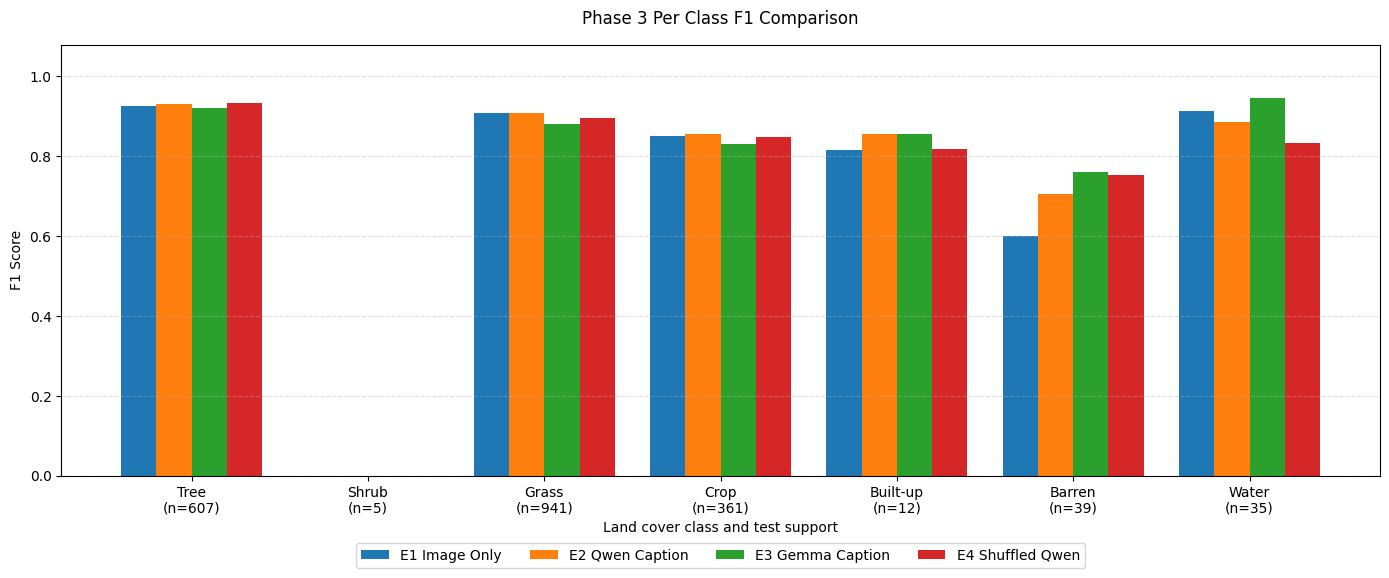

Per class F1 comparison figure saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_per_class_f1_comparison.png


In [124]:
# Creating per class F1 comparison figure

# Preparing data for plotting
plot_df = per_class_f1_table.copy()

# Creating x-axis labels with test support
plot_df["class_label"] = plot_df.apply(
    lambda row: f"{row['class_name']}\n(n={int(row['test_support'])})",
    axis=1
)

x = np.arange(len(plot_df["class_name"]))
bar_width = 0.20

fig, ax = plt.subplots(figsize=(14, 6.5))

# Plotting grouped bars
ax.bar(
    x - 1.5 * bar_width,
    plot_df["E1 Image Only F1"],
    width=bar_width,
    label="E1 Image Only"
)

ax.bar(
    x - 0.5 * bar_width,
    plot_df["E2 Qwen Caption F1"],
    width=bar_width,
    label="E2 Qwen Caption"
)

ax.bar(
    x + 0.5 * bar_width,
    plot_df["E3 Gemma Caption F1"],
    width=bar_width,
    label="E3 Gemma Caption"
)

ax.bar(
    x + 1.5 * bar_width,
    plot_df["E4 Shuffled Qwen F1"],
    width=bar_width,
    label="E4 Shuffled Qwen"
)

# Formatting axes and labels
ax.set_xticks(x)
ax.set_xticklabels(plot_df["class_label"], rotation=0)
ax.set_ylabel("F1 Score")
ax.set_xlabel("Land cover class and test support")
ax.set_title("Phase 3 Per Class F1 Comparison", pad=15)
ax.set_ylim(0, 1.08)

# Moving legend below the plot to avoid covering bars
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=4,
    frameon=True
)

# Adding horizontal grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0.08, 1, 1])

# Saving improved figure at 300 dpi
per_class_f1_figure_path = PHASE3_FIGURES_PATH / "phase3_per_class_f1_comparison.png"

plt.savefig(
    per_class_f1_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Per class F1 comparison figure saved to:", per_class_f1_figure_path)

The per class F1 figure shows that the effect of textual captions is class dependent. Majority classes such as Tree, Grass, and Crop show only small differences across models, while rare classes such as Built-up and Barren benefit more from caption-based models.

Shrub remains at 0.0 F1 for all models, which should be interpreted together with its very small test support. Since there are only 5 Shrub samples in the test set, this class is difficult to evaluate reliably.

The figure also shows that the shuffled caption model performs competitively for some classes. Therefore, the multimodal gains should be interpreted carefully rather than being attributed only to correct image specific captions.

**30-Rare Class F1 Comparison Figure**

The purpose is to focus on the underrepresented classes without the majority classes dominating the visual interpretation. This figure supports the rare class discussion and helps evaluate whether caption-based models provide more benefit for minority classes.

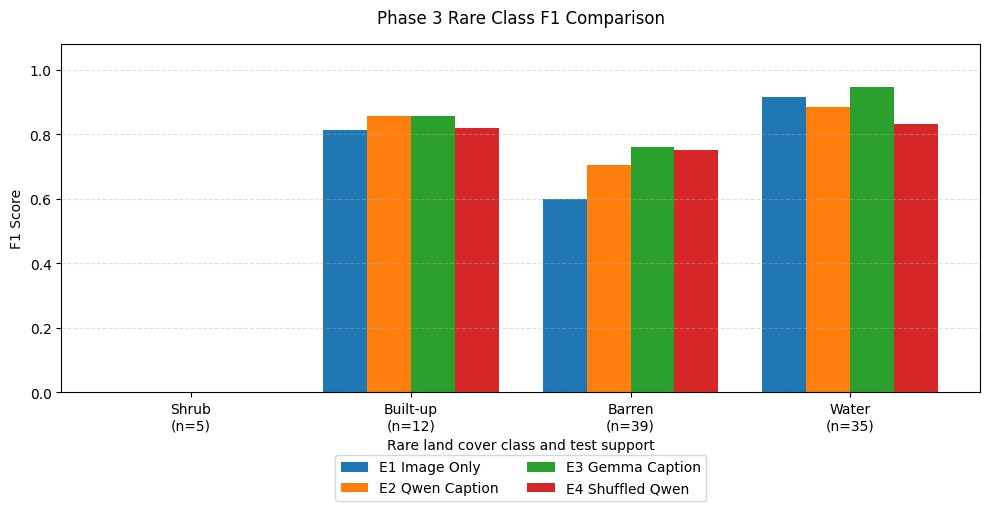

Rare class F1 comparison figure saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_rare_class_f1_comparison.png


In [125]:
# Preparing rare class data for plotting
rare_plot_df = per_class_f1_table[
    per_class_f1_table["class_name"].isin(RARE_CLASSES)
].copy()

# Creating x-axis labels with test support
rare_plot_df["class_label"] = rare_plot_df.apply(
    lambda row: f"{row['class_name']}\n(n={int(row['test_support'])})",
    axis=1
)

x = np.arange(len(rare_plot_df["class_name"]))
bar_width = 0.20

# Creating figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting grouped bars
ax.bar(
    x - 1.5 * bar_width,
    rare_plot_df["E1 Image Only F1"],
    width=bar_width,
    label="E1 Image Only"
)

ax.bar(
    x - 0.5 * bar_width,
    rare_plot_df["E2 Qwen Caption F1"],
    width=bar_width,
    label="E2 Qwen Caption"
)

ax.bar(
    x + 0.5 * bar_width,
    rare_plot_df["E3 Gemma Caption F1"],
    width=bar_width,
    label="E3 Gemma Caption"
)

ax.bar(
    x + 1.5 * bar_width,
    rare_plot_df["E4 Shuffled Qwen F1"],
    width=bar_width,
    label="E4 Shuffled Qwen"
)

# Formatting axes and labels
ax.set_xticks(x)
ax.set_xticklabels(rare_plot_df["class_label"], rotation=0)
ax.set_ylabel("F1 Score")
ax.set_xlabel("Rare land cover class and test support")
ax.set_title("Phase 3 Rare Class F1 Comparison", pad=15)
ax.set_ylim(0, 1.08)

# Moving legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True
)

# Adding horizontal grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0.10, 1, 1])

# Saving figure at 300 dpi
rare_class_f1_figure_path = PHASE3_FIGURES_PATH / "phase3_rare_class_f1_comparison.png"

plt.savefig(
    rare_class_f1_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Rare class F1 comparison figure saved to:", rare_class_f1_figure_path)

The rare class F1 figure shows that the caption-based models improve some underrepresented classes, especially Built-up and Barren. Gemma captions provide the highest rare-class average performance, while Qwen captions also improve Barren and Built-up compared with the image-only baseline.

Shrub remains at 0.0 F1 for all models. This should be interpreted carefully because the test set contains only 5 Shrub samples. Therefore, the result reflects the difficulty of learning and evaluating an extremely underrepresented class.

The shuffled-caption model also performs competitively for some rare classes, especially Barren. This indicates that the multimodal gains should be interpreted cautiously and not attributed only to correct image-specific captions.

**31-Confusion Matrix Analysis**

Confusion matrices help analyze which classes are confused with each other. This is especially useful for the full 7 class setup because some rare classes may be misclassified as visually similar majority classes.

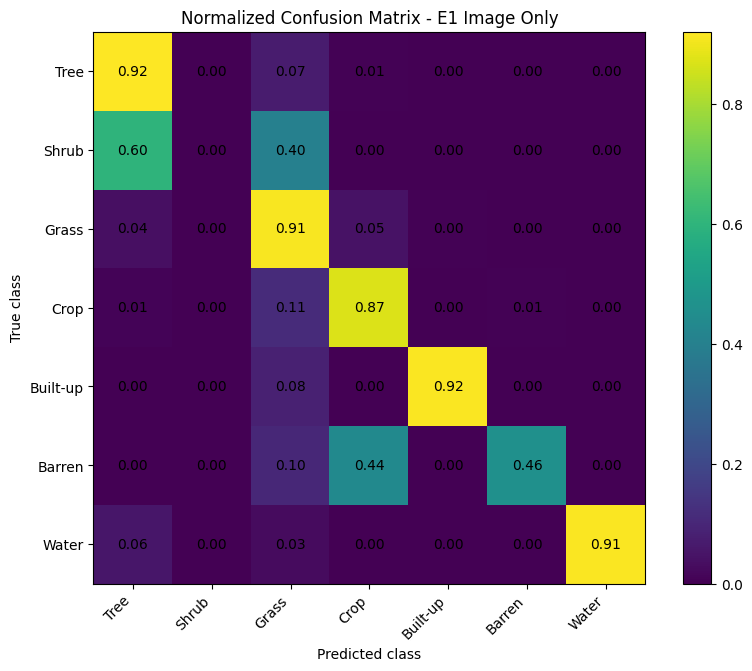

Confusion matrix saved for E1 Image Only: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_confusion_matrix_e1_image_only.png


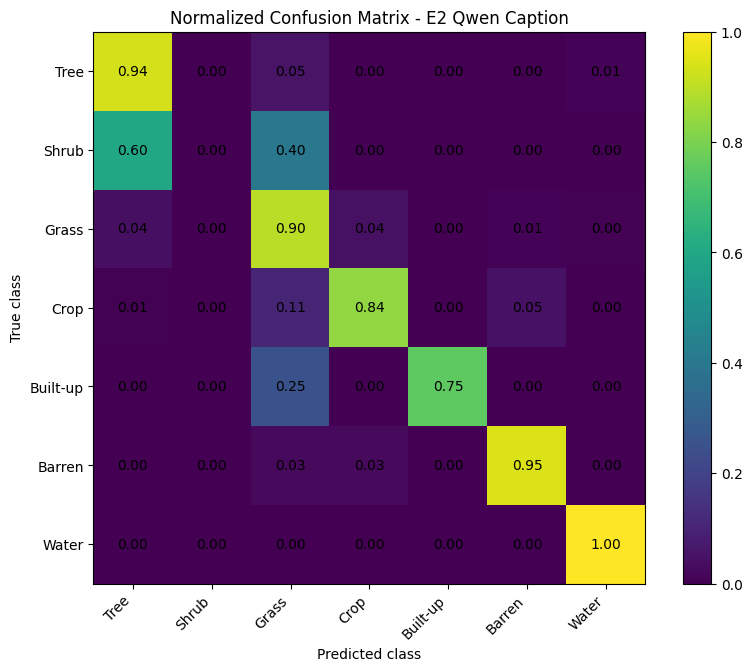

Confusion matrix saved for E2 Qwen Caption: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_confusion_matrix_e2_qwen_caption.png


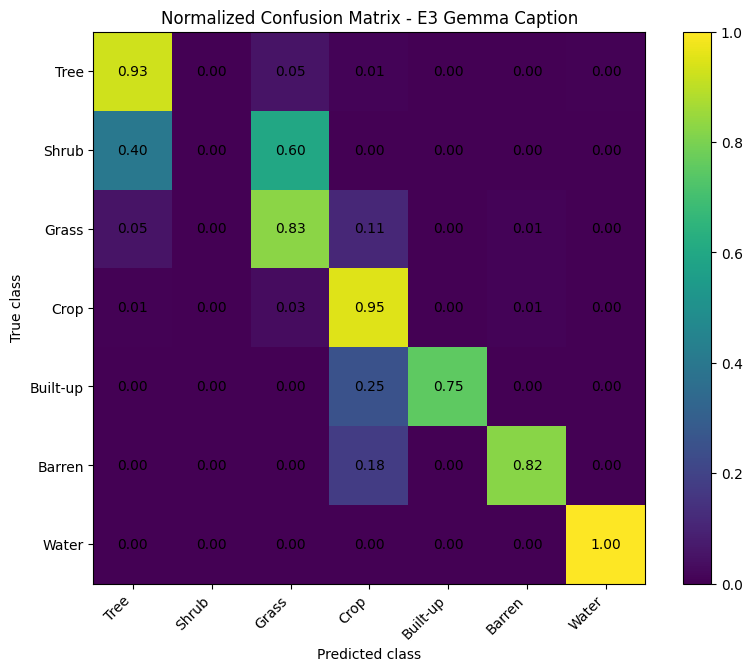

Confusion matrix saved for E3 Gemma Caption: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_confusion_matrix_e3_gemma_caption.png


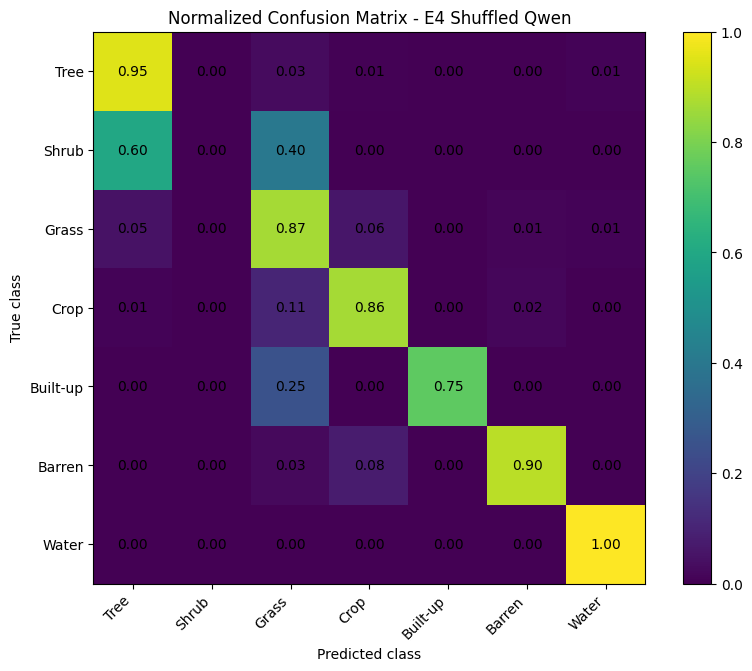

Confusion matrix saved for E4 Shuffled Qwen: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_confusion_matrix_e4_shuffled_qwen.png


In [112]:
# Mapping experiment labels to prediction files
prediction_files = {
    "E1 Image Only": "image_only_7class_cw_predictions.csv",
    "E2 Qwen Caption": "image_text_qwen_7class_cw_predictions.csv",
    "E3 Gemma Caption": "image_text_gemma_7class_cw_predictions.csv",
    "E4 Shuffled Qwen": "image_text_qwen_shuffled_7class_cw_predictions.csv"
}

def plot_confusion_matrix_from_predictions(experiment_label, prediction_filename):
    # Loading prediction file
    prediction_path = PHASE3_RESULTS_PATH / prediction_filename
    pred_df = pd.read_csv(prediction_path)

    # Creating confusion matrix
    cm = confusion_matrix(
        pred_df["true_label"],
        pred_df["predicted_label"],
        labels=list(range(len(CLASS_COLS)))
    )

    # Normalizing confusion matrix by true class
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)

    # Creating figure
    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(cm_normalized)

    # Adding colorbar
    plt.colorbar(im, ax=ax)

    # Formatting axes
    ax.set_xticks(np.arange(len(CLASS_COLS)))
    ax.set_yticks(np.arange(len(CLASS_COLS)))
    ax.set_xticklabels(CLASS_COLS, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_COLS)

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"Normalized Confusion Matrix - {experiment_label}")

    # Adding cell values
    for i in range(len(CLASS_COLS)):
        for j in range(len(CLASS_COLS)):
            ax.text(
                j,
                i,
                f"{cm_normalized[i, j]:.2f}",
                ha="center",
                va="center"
            )

    fig.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.96,
    bottom=0.04,
    hspace=0.35,
    wspace=0.08
)

    # Saving figure
    safe_name = experiment_label.lower().replace(" ", "_")
    cm_figure_path = PHASE3_FIGURES_PATH / f"phase3_confusion_matrix_{safe_name}.png"

    plt.savefig(
        cm_figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Confusion matrix saved for {experiment_label}:", cm_figure_path)


# Creating confusion matrices for all experiments
for experiment_label, prediction_filename in prediction_files.items():
    plot_confusion_matrix_from_predictions(
        experiment_label=experiment_label,
        prediction_filename=prediction_filename
    )

The confusion matrices show that most errors occur between visually related land cover classes.

Shrub is not correctly predicted by any model and is mostly confused with Tree or Grass. This is consistent with the extremely small Shrub test support.

For Barren, the caption based models improve the diagonal value compared with the image only baseline, which supports the rare class improvement observed in the per class F1 table.

The shuffled- aption model also performs well for some classes, especially Barren and Water. Therefore, the improvement from text should be interpreted carefully and discussed as class dependent rather than uniformly caused by correct image specific captions.

**32-Qualitative Example Selection**

This section selects qualitative examples from the test set.

The selected examples are used to demonstrate model inputs and outputs. The goal is to show cases where captions help, where all models perform correctly, and where rare classes remain difficult.

These examples support the storytelling of the final report by connecting the numerical results with actual remote sensing images, masks, captions, true labels, and model predictions.

In [107]:
# Loading prediction files
e1_pred = pd.read_csv(PHASE3_RESULTS_PATH / "image_only_7class_cw_predictions.csv")
e2_pred = pd.read_csv(PHASE3_RESULTS_PATH / "image_text_qwen_7class_cw_predictions.csv")
e3_pred = pd.read_csv(PHASE3_RESULTS_PATH / "image_text_gemma_7class_cw_predictions.csv")
e4_pred = pd.read_csv(PHASE3_RESULTS_PATH / "image_text_qwen_shuffled_7class_cw_predictions.csv")

# Keeping useful prediction columns
e1_pred = e1_pred[["filename", "true_class", "predicted_class"]].rename(
    columns={"predicted_class": "e1_image_only_pred"}
)

e2_pred = e2_pred[["filename", "predicted_class"]].rename(
    columns={"predicted_class": "e2_qwen_pred"}
)

e3_pred = e3_pred[["filename", "predicted_class"]].rename(
    columns={"predicted_class": "e3_gemma_pred"}
)

e4_pred = e4_pred[["filename", "predicted_class"]].rename(
    columns={"predicted_class": "e4_shuffled_pred"}
)

# Merging predictions
qualitative_df = (
    e1_pred
    .merge(e2_pred, on="filename", how="left")
    .merge(e3_pred, on="filename", how="left")
    .merge(e4_pred, on="filename", how="left")
)

# Adding image, mask, and caption information
metadata_cols = [
    "filename",
    "image_path",
    "mask_path",
    "qwen_caption",
    "gemma_caption",
    "dominant_class"
]

qualitative_df = qualitative_df.merge(
    phase3_df[metadata_cols],
    on="filename",
    how="left"
)

# Case 1: Image only wrong, Qwen correct
case_qwen_help = qualitative_df[
    (qualitative_df["e1_image_only_pred"] != qualitative_df["true_class"]) &
    (qualitative_df["e2_qwen_pred"] == qualitative_df["true_class"])
].copy()

# Case 2: Image only wrong, Gemma correct
case_gemma_help = qualitative_df[
    (qualitative_df["e1_image_only_pred"] != qualitative_df["true_class"]) &
    (qualitative_df["e3_gemma_pred"] == qualitative_df["true_class"])
].copy()

# Case 3: Rare class example
case_rare = qualitative_df[
    qualitative_df["true_class"].isin(RARE_CLASSES)
].copy()

# Case 4: All models correct
case_all_correct = qualitative_df[
    (qualitative_df["e1_image_only_pred"] == qualitative_df["true_class"]) &
    (qualitative_df["e2_qwen_pred"] == qualitative_df["true_class"]) &
    (qualitative_df["e3_gemma_pred"] == qualitative_df["true_class"]) &
    (qualitative_df["e4_shuffled_pred"] == qualitative_df["true_class"])
].copy()

# Selecting one example from each useful case
selected_examples = []

if len(case_qwen_help) > 0:
    selected_examples.append(case_qwen_help.iloc[0])

if len(case_gemma_help) > 0:
    selected_examples.append(case_gemma_help.iloc[0])

if len(case_rare) > 0:
    selected_examples.append(case_rare.iloc[0])

if len(case_all_correct) > 0:
    selected_examples.append(case_all_correct.iloc[0])

selected_examples_df = pd.DataFrame(selected_examples).drop_duplicates(
    subset=["filename"]
).reset_index(drop=True)

# Saving selected examples
selected_examples_path = PHASE3_RESULTS_PATH / "phase3_selected_qualitative_examples.csv"

selected_examples_df.to_csv(
    selected_examples_path,
    index=False
)

print("Selected qualitative examples saved to:", selected_examples_path)
print("Number of selected examples:", len(selected_examples_df))

display(
    selected_examples_df[
        [
            "filename",
            "true_class",
            "e1_image_only_pred",
            "e2_qwen_pred",
            "e3_gemma_pred",
            "e4_shuffled_pred",
            "qwen_caption"
        ]
    ]
)

Selected qualitative examples saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/results/phase3_selected_qualitative_examples.csv
Number of selected examples: 4


,filename,true_class,e1_image_only_pred,e2_qwen_pred,e3_gemma_pred,e4_shuffled_pred,qwen_caption
0,263390.png,Crop,Grass,Crop,Crop,Crop,This satellite image shows a semi-arid agricul...
1,212750.png,Crop,Grass,Grass,Crop,Crop,This satellite image shows a patchwork of agri...
2,235702.png,Built-up,Built-up,Built-up,Built-up,Built-up,This satellite image shows a densely built-up ...
3,56741.png,Tree,Tree,Tree,Tree,Tree,This satellite image shows a river system wind...


**33-Qualitative Example Visualization**

This section visualizes selected qualitative examples from the test set.

Each example includes the true color image, the corresponding segmentation mask, a shortened Qwen caption, the true class, and the predictions of the four Phase 3 models. The purpose is to connect the quantitative results with actual model inputs and outputs in a compact and readable way.

/tmp/ipykernel_3904/793875353.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


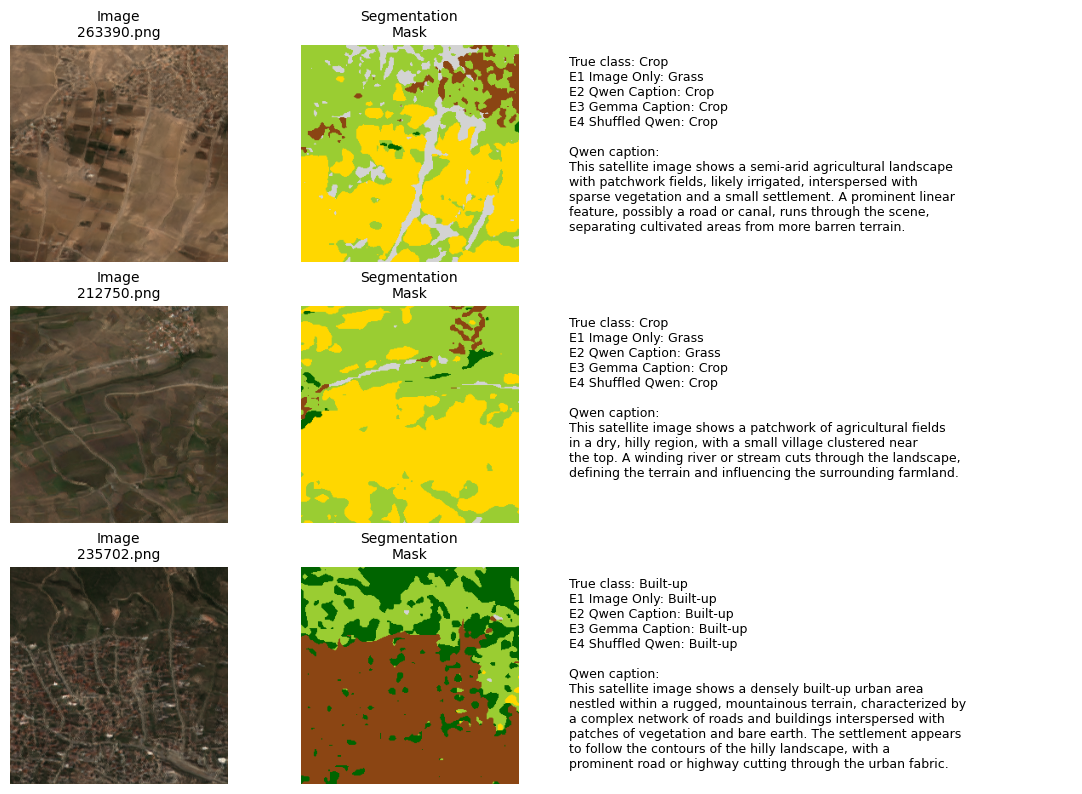

Qualitative examples figure saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/figures/phase3_qualitative_examples.png


In [110]:
import textwrap

def wrap_text(text, width=62):
    # Wrapping long captions for readable visualization
    return "\n".join(textwrap.wrap(str(text), width=width))


# Reloading selected examples if needed
selected_examples_path = PHASE3_RESULTS_PATH / "phase3_selected_qualitative_examples.csv"

if "selected_examples_df" not in globals():
    selected_examples_df = pd.read_csv(selected_examples_path)

# Selecting up to 3 examples for readability
qualitative_plot_df = selected_examples_df.head(3).copy()

num_examples = len(qualitative_plot_df)

# Creating a 3-column layout: image, mask, information text
fig, axes = plt.subplots(
    nrows=num_examples,
    ncols=3,
    figsize=(14, 3.2 * num_examples),
    gridspec_kw={
        "width_ratios": [1.15, 1.15, 2.2],
        "wspace": 0.08
    }
)

# Handling single-row case
if num_examples == 1:
    axes = np.array([axes])

for idx, row in qualitative_plot_df.iterrows():
    # Loading image and mask
    image = Image.open(row["image_path"]).convert("RGB")
    mask = Image.open(row["mask_path"]).convert("RGB")

    # Showing true-color image
    axes[idx, 0].imshow(image)
    axes[idx, 0].axis("off")
    axes[idx, 0].set_title(f"Image\n{row['filename']}", fontsize=10)

    # Showing segmentation mask
    axes[idx, 1].imshow(mask)
    axes[idx, 1].axis("off")
    axes[idx, 1].set_title("Segmentation\nMask", fontsize=10)

    # Preparing readable prediction and caption text
    info_text = (
        f"True class: {row['true_class']}\n"
        f"E1 Image Only: {row['e1_image_only_pred']}\n"
        f"E2 Qwen Caption: {row['e2_qwen_pred']}\n"
        f"E3 Gemma Caption: {row['e3_gemma_pred']}\n"
        f"E4 Shuffled Qwen: {row['e4_shuffled_pred']}\n\n"
        f"Qwen caption:\n{wrap_text(row['qwen_caption'], width=62)}"
    )

    # Showing text information in the third column
    axes[idx, 2].axis("off")
    axes[idx, 2].text(
        0,
        0.95,
        info_text,
        fontsize=9,
        va="top",
        ha="left"
    )

plt.tight_layout()

# Saving qualitative examples figure
qualitative_figure_path = PHASE3_FIGURES_PATH / "phase3_qualitative_examples.png"

plt.savefig(
    qualitative_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Qualitative examples figure saved to:", qualitative_figure_path)

The qualitative examples show representative model behaviors. In the first example, the image only model predicts Grass while the caption based models correctly predict Crop.

In the second example, the Gemma caption model corrects the image only and Qwen predictions.

The third example shows a rare Built-up sample where all models predict correctly.

These examples support the quantitative results by showing that captions can help in some cases, but the effect depends on the scene and caption source.

**34-Phase 3 Summary**

Phase 3 extends the project from the controlled top 3 benchmark to the full 7 class remote sensing classification task. The results show that adding captions does not produce a large overall accuracy improvement, but it improves macro F1 and rare class macro F1 compared with the image only baseline.

The best rare class macro F1 is obtained with the Gemma vision captions. Qwen captions also improve rare class performance compared with image only input. However, the shuffled caption model also performs competitively for some classes, especially Barren. Therefore, the effect of textual information should be interpreted cautiously.

The results suggest that textual captions may help some underrepresented classes, but the benefit is class dependent rather than uniformly positive. Shrub remains difficult for all models because it has extremely small support in the test set. This highlights the limitation of dominant label classification under severe class imbalance.

Inference cost also increases when text is added. The image only model is faster, while image+text models require approximately 1.8 times higher milliseconds per sample. Therefore, the final interpretation should consider both performance improvement and computational cost.

The main limitations are also noted for the final interpretation.



1.   The experiments are conducted with a single random seed due to computational cost, so small differences may still be affected by training variance.
1.   The full 7 class setup is highly imbalanced, and Shrub has extremely limited support, which makes its F1 score unstable.
2.   The mask derived class percentages are reduced to a single dominant class label, which simplifies the task but discards mixed land cover composition information
2.   The shuffled-caption results show that the observed multimodal gains cannot be attributed only to correct image-specific captions in all cases.


**35-Phase 3 Output File Check**

This final check verifies that the main Phase 3 outputs are saved successfully.

In [113]:
# Checking saved Phase 3 output files

required_phase3_files = {
    "E1 checkpoint": PHASE3_CHECKPOINT_PATH / "image_only_7class_cw.pt",
    "E2 checkpoint": PHASE3_CHECKPOINT_PATH / "image_text_qwen_7class_cw.pt",
    "E3 checkpoint": PHASE3_CHECKPOINT_PATH / "image_text_gemma_7class_cw.pt",
    "E4 checkpoint": PHASE3_CHECKPOINT_PATH / "image_text_qwen_shuffled_7class_cw.pt",

    "Final summary results": PHASE3_RESULTS_PATH / "phase3_final_summary_results.csv",
    "Compact performance table": PHASE3_RESULTS_PATH / "phase3_performance_table_compact.csv",
    "Compact cost table": PHASE3_RESULTS_PATH / "phase3_cost_table_compact.csv",
    "Per-class F1 comparison": PHASE3_RESULTS_PATH / "phase3_per_class_f1_comparison.csv",
    "Rare-class analysis": PHASE3_RESULTS_PATH / "phase3_rare_class_analysis.csv",
    "Selected qualitative examples": PHASE3_RESULTS_PATH / "phase3_selected_qualitative_examples.csv",

    "Per-class F1 figure": PHASE3_FIGURES_PATH / "phase3_per_class_f1_comparison.png",
    "Rare-class F1 figure": PHASE3_FIGURES_PATH / "phase3_rare_class_f1_comparison.png",
    "Qualitative examples figure": PHASE3_FIGURES_PATH / "phase3_qualitative_examples.png"
}

output_check_rows = []

for file_description, file_path in required_phase3_files.items():
    output_check_rows.append({
        "file_description": file_description,
        "file_path": str(file_path),
        "exists": file_path.exists()
    })

output_check_df = pd.DataFrame(output_check_rows)

print("Phase 3 output file check:")
display(output_check_df)

missing_output_files = output_check_df[output_check_df["exists"] == False]

if len(missing_output_files) == 0:
    print("All required Phase 3 output files exist.")
else:
    print("Missing output files:")
    display(missing_output_files)

Phase 3 output file check:


,file_description,file_path,exists
0,E1 checkpoint,/content/drive/MyDrive/DI725_Transformer/TermP...,True
1,E2 checkpoint,/content/drive/MyDrive/DI725_Transformer/TermP...,True
2,E3 checkpoint,/content/drive/MyDrive/DI725_Transformer/TermP...,True
3,E4 checkpoint,/content/drive/MyDrive/DI725_Transformer/TermP...,True
4,Final summary results,/content/drive/MyDrive/DI725_Transformer/TermP...,True
5,Compact performance table,/content/drive/MyDrive/DI725_Transformer/TermP...,True
6,Compact cost table,/content/drive/MyDrive/DI725_Transformer/TermP...,True
7,Per-class F1 comparison,/content/drive/MyDrive/DI725_Transformer/TermP...,True
8,Rare-class analysis,/content/drive/MyDrive/DI725_Transformer/TermP...,True
9,Selected qualitative examples,/content/drive/MyDrive/DI725_Transformer/TermP...,True


All required Phase 3 output files exist.


**36-Tables and Figures for Report**

This section prepares the final tables and figures that will be used in the Phase 3 report.

The figures are exported at 300 dpi and use hatch patterns in addition to color so that they remain readable in black-and-white print.

In [114]:
# Creating report material output folder

REPORT_MATERIALS_PATH = PHASE3_OUTPUT_PATH / "report_materials"
REPORT_MATERIALS_PATH.mkdir(parents=True, exist_ok=True)

print("Report materials path:", REPORT_MATERIALS_PATH)

Report materials path: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/report_materials


In [115]:
# Preparing Table I for the final report

# Creating report-ready Table I
table1_report_df = phase3_summary_df[
    [
        "experiment_id",
        "display_name",
        "caption_source",
        "accuracy",
        "macro_f1",
        "rare_class_macro_f1",
        "milliseconds_per_sample"
    ]
].copy()

# Renaming columns for report readability
table1_report_df = table1_report_df.rename(columns={
    "experiment_id": "Exp.",
    "display_name": "Experiment",
    "caption_source": "Caption Source",
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
    "rare_class_macro_f1": "Rare-Class Macro F1",
    "milliseconds_per_sample": "ms/sample"
})

# Rounding numerical columns
numeric_cols = ["Accuracy", "Macro F1", "Rare-Class Macro F1", "ms/sample"]
table1_report_df[numeric_cols] = table1_report_df[numeric_cols].round(4)

# Saving report-ready table
table1_report_path = REPORT_MATERIALS_PATH / "table1_final_performance_and_cost.csv"
table1_report_df.to_csv(table1_report_path, index=False)

print("Table I saved to:", table1_report_path)
display(table1_report_df)

Table I saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/report_materials/table1_final_performance_and_cost.csv


,Exp.,Experiment,Caption Source,Accuracy,Macro F1,Rare-Class Macro F1,ms/sample
0,E1,E1 Image Only,none,0.8960,0.7160,0.5823,3.0345
1,E2,E2 Qwen Caption,vision_qwen3-vl-8b,0.8990,0.7349,0.6120,5.4368
2,E3,E3 Gemma Caption,vision_gemma3-4b,0.8800,0.7425,0.6412,5.4589
3,E4,E4 Shuffled Qwen,shuffled_vision_qwen3-vl-8b,0.8915,0.7259,0.6011,5.4465


In [116]:
# Preparing Table II for the final report

# Creating report-ready Table II from rare-class analysis
table2_report_df = rare_class_table_with_avg[
    [
        "class_name",
        "test_support",
        "E1 Image Only F1",
        "E2 Qwen Caption F1",
        "E3 Gemma Caption F1",
        "E4 Shuffled Qwen F1"
    ]
].copy()

# Renaming columns for report readability
table2_report_df = table2_report_df.rename(columns={
    "class_name": "Class",
    "test_support": "Support",
    "E1 Image Only F1": "Image Only",
    "E2 Qwen Caption F1": "Qwen Caption",
    "E3 Gemma Caption F1": "Gemma Caption",
    "E4 Shuffled Qwen F1": "Shuffled Qwen"
})

# Rounding numerical columns
numeric_cols = ["Image Only", "Qwen Caption", "Gemma Caption", "Shuffled Qwen"]
table2_report_df[numeric_cols] = table2_report_df[numeric_cols].round(4)

# Saving report-ready table
table2_report_path = REPORT_MATERIALS_PATH / "table2_rare_class_f1_analysis.csv"
table2_report_df.to_csv(table2_report_path, index=False)

print("Table II saved to:", table2_report_path)
display(table2_report_df)

Table II saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/report_materials/table2_rare_class_f1_analysis.csv


,Class,Support,Image Only,Qwen Caption,Gemma Caption,Shuffled Qwen
0,Shrub,5,0.0000,0.0000,0.0000,0.0000
1,Built-up,12,0.8148,0.8571,0.8571,0.8182
2,Barren,39,0.6000,0.7048,0.7619,0.7527
3,Water,35,0.9143,0.8861,0.9459,0.8333
4,Rare class average,91,0.5823,0.6120,0.6412,0.6010


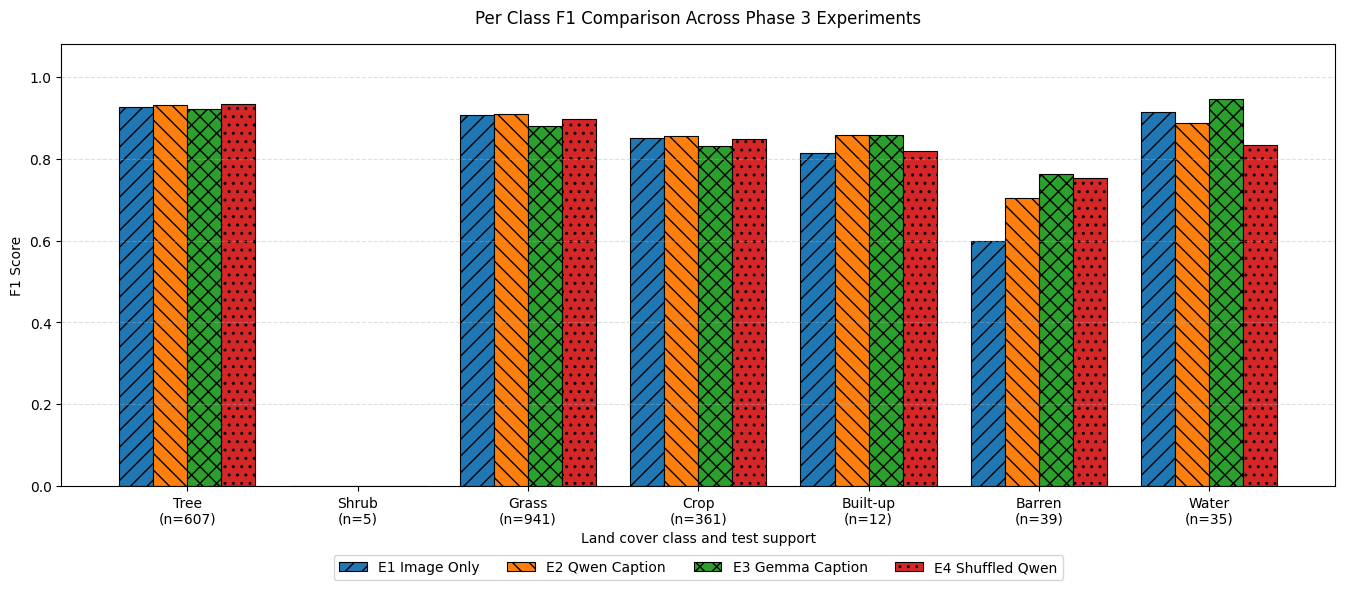

Fig. 1 saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/report_materials/fig1_per_class_f1_comparison_300dpi.png


In [126]:
# Creating report-ready Fig. 1: per class F1 comparison

# Preparing data for plotting
plot_df = per_class_f1_table.copy()

# Creating x-axis labels with test support
plot_df["class_label"] = plot_df.apply(
    lambda row: f"{row['class_name']}\n(n={int(row['test_support'])})",
    axis=1
)

x = np.arange(len(plot_df["class_name"]))
bar_width = 0.20

# Defining hatch patterns for black-and-white readability
hatches = ["//", "\\\\", "xx", ".."]

fig, ax = plt.subplots(figsize=(14, 6.5))

bars1 = ax.bar(
    x - 1.5 * bar_width,
    plot_df["E1 Image Only F1"],
    width=bar_width,
    label="E1 Image Only",
    hatch=hatches[0],
    edgecolor="black",
    linewidth=0.8
)

bars2 = ax.bar(
    x - 0.5 * bar_width,
    plot_df["E2 Qwen Caption F1"],
    width=bar_width,
    label="E2 Qwen Caption",
    hatch=hatches[1],
    edgecolor="black",
    linewidth=0.8
)

bars3 = ax.bar(
    x + 0.5 * bar_width,
    plot_df["E3 Gemma Caption F1"],
    width=bar_width,
    label="E3 Gemma Caption",
    hatch=hatches[2],
    edgecolor="black",
    linewidth=0.8
)

bars4 = ax.bar(
    x + 1.5 * bar_width,
    plot_df["E4 Shuffled Qwen F1"],
    width=bar_width,
    label="E4 Shuffled Qwen",
    hatch=hatches[3],
    edgecolor="black",
    linewidth=0.8
)

# Formatting axes
ax.set_xticks(x)
ax.set_xticklabels(plot_df["class_label"], rotation=0)
ax.set_ylabel("F1 Score")
ax.set_xlabel("Land cover class and test support")
ax.set_title("Per Class F1 Comparison Across Phase 3 Experiments", pad=15)
ax.set_ylim(0, 1.08)

# Moving legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=4,
    frameon=True
)

# Adding grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.22
)

# Saving report-ready figure at 300 dpi
fig1_report_path = REPORT_MATERIALS_PATH / "fig1_per_class_f1_comparison_300dpi.png"

plt.savefig(
    fig1_report_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Fig. 1 saved to:", fig1_report_path)

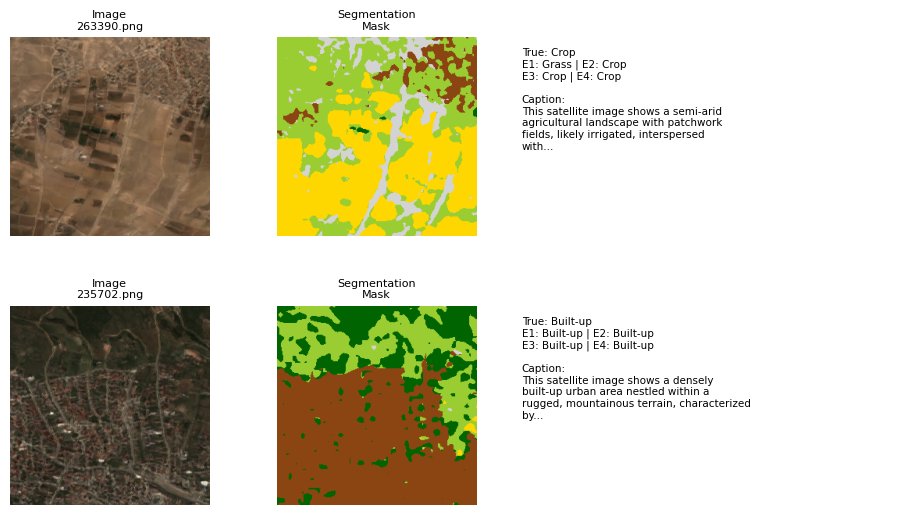

Fig. 2 saved to: /content/drive/MyDrive/DI725_Transformer/TermProject/phase3_outputs/report_materials/fig2_qualitative_examples_300dpi.png


In [119]:
# Creating report-ready Fig. 2: qualitative examples

import textwrap

def shorten_and_wrap_text(text, max_chars=120, width=42):
    # Shortening and wrapping long captions for report readability
    text = str(text)

    if len(text) > max_chars:
        text = text[:max_chars].rstrip() + "..."

    return "\n".join(textwrap.wrap(text, width=width))


# Loading selected qualitative examples if needed
selected_examples_path = PHASE3_RESULTS_PATH / "phase3_selected_qualitative_examples.csv"

if "selected_examples_df" not in globals():
    selected_examples_df = pd.read_csv(selected_examples_path)

# Selecting two representative examples for the report
preferred_filenames = ["263390.png", "235702.png"]

qualitative_report_df = selected_examples_df[
    selected_examples_df["filename"].isin(preferred_filenames)
].copy()

# Fallback if preferred examples are not available
if len(qualitative_report_df) < 2:
    qualitative_report_df = selected_examples_df.head(2).copy()

num_examples = len(qualitative_report_df)

fig, axes = plt.subplots(
    nrows=num_examples,
    ncols=3,
    figsize=(9.5, 2.6 * num_examples),
    gridspec_kw={
        "width_ratios": [1.0, 1.0, 1.55],
        "wspace": 0.08
    }
)

# Handling single-row case
if num_examples == 1:
    axes = np.array([axes])

for idx, row in qualitative_report_df.reset_index(drop=True).iterrows():
    # Loading image and mask
    image = Image.open(row["image_path"]).convert("RGB")
    mask = Image.open(row["mask_path"]).convert("RGB")

    # Showing image
    axes[idx, 0].imshow(image)
    axes[idx, 0].axis("off")
    axes[idx, 0].set_title(f"Image\n{row['filename']}", fontsize=8)

    # Showing mask
    axes[idx, 1].imshow(mask)
    axes[idx, 1].axis("off")
    axes[idx, 1].set_title("Segmentation\nMask", fontsize=8)

    # Preparing compact information text
    info_text = (
        f"True: {row['true_class']}\n"
        f"E1: {row['e1_image_only_pred']} | "
        f"E2: {row['e2_qwen_pred']}\n"
        f"E3: {row['e3_gemma_pred']} | "
        f"E4: {row['e4_shuffled_pred']}\n\n"
        f"Caption:\n{shorten_and_wrap_text(row['qwen_caption'], max_chars=120, width=42)}"
    )

    # Showing text information
    axes[idx, 2].axis("off")
    axes[idx, 2].text(
        0,
        0.95,
        info_text,
        fontsize=7.5,
        va="top",
        ha="left"
    )

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.94,
    bottom=0.04,
    hspace=0.35,
    wspace=0.08
)

# Saving report-ready figure at 300 dpi
fig2_report_path = REPORT_MATERIALS_PATH / "fig2_qualitative_examples_300dpi.png"

plt.savefig(
    fig2_report_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Fig. 2 saved to:", fig2_report_path)